# BT4221 Group Project: HDB Resale Price Prediction

## Motivation

Singapore's Housing & Development Board (HDB) resale market accounts for over 80% of the nation's housing stock and recorded approximately **28,000 transactions in 2024 alone**. Despite this volume, pricing remains opaque: buyers and sellers rely on anecdotal comparisons, and existing valuation tools treat each transaction in isolation — ignoring the interplay of **macroeconomic signals** (Resale Price Index, household income trends), **spatial amenities** (MRT proximity, school quality), and **lease depreciation dynamics** that together drive price formation.


## Pipeline Overview

1. **Auxiliary Dataset Extraction** — Hawker centres, shopping malls, supermarkets, MRT/LRT stations, demographics, HDB Resale Price Index
2. **HDB Data Loading & Geocoding** — Download resale price data from Data.gov.sg and geocode addresses via OneMap
3. **LLM-Guided Data Cleaning** — Automated cleaning agent that profiles data and applies structured cleaning operations
4. **Exploratory Data Analysis & Feature Validation** — Raw EDA (price trends, distributions, correlations), time-feature preprocessing, categorical encoding snapshots, interaction term validation, and multicollinearity analysis
5. **LangGraph ML Pipeline** — Orchestrated 5-node StateGraph: feature engineering agent → PySpark feature creation → feature validation gate → model training (LinearRegression, RandomForest, GBT with 3-fold CrossValidator) → LLM evaluation agent
6. **Out-of-Time Validation on Recent Data** — Temporal train/test split (last ~2 quarters held out) to evaluate forward-looking generalisation of the best model under realistic deployment conditions

**Prerequisites:** Google Colab (recommended) or a local environment with Java 17+ and PySpark.

**API Keys Required:** `GOV_DATA`, `ONEMAP_EMAIL`, `ONEMAP_PASSWORD`, `OPENAI_API_KEY` (set in Colab Secrets or `.env` file).

## Environment Setup

Install PySpark and Java runtime dependencies. The `apt-get` command targets Google Colab's Linux environment and is skipped on other platforms (e.g., macOS). Core PySpark modules are imported here.

In [ ]:
!pip install pyspark -q
!apt-get install openjdk-17-jdk-headless -qq > /dev/null

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import subprocess, sys

packages = [
    "langgraph",
    "langchain",
    "langchain-openai",
    "langchain-core",
    "matplotlib",
    "seaborn",
    "lxml",
    "python-dotenv",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("All packages installed. If this is the first run, restart the runtime now.")

All packages installed. If this is the first run, restart the runtime now.


In [ ]:
# Mount Google Drive and navigate to the project folder
from google.colab import drive
drive.mount('/content/drive')

import os
# Update this path to where you placed the project folder in your Drive
os.chdir('/content/drive/MyDrive/bt4221-group-project')

Mounted at /content/drive


## Spark Session Initialization

Defines `load_secret()`, a utility function that reads API keys from Google Colab Secrets, environment variables, or a `.env` file (checked in that priority order).

In [ ]:
import os
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-memory 8g pyspark-shell"

spark = (
    SparkSession.builder
    .appName("BT4221_HDB_Resale_Prices_Project")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.ui.enabled", "false")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.memory.fraction", "0.6")
    .config("spark.memory.storageFraction", "0.3")
    .config("spark.sql.crossJoin.enabled", "true")
    .getOrCreate()
)

print("Spark version:", spark.version)

spark.sparkContext.setLogLevel("WARN")

from pathlib import Path


def load_secret(name: str, *alt_names: str) -> str:
    """Colab Secrets, or environment / `.env` when running locally."""
    try:
        from google.colab import userdata

        val = userdata.get(name)
        if val:
            return val
    except ImportError:
        pass
    try:
        from dotenv import load_dotenv

        load_dotenv(Path.cwd() / ".env")
    except ImportError:
        pass
    for key in (name, *alt_names):
        v = os.environ.get(key)
        if v:
            return v
    raise ValueError(

        f"Missing secret {name!r}. "
        "On Colab: add it under Secrets. Locally: set the env var or add it to `.env`."
        )

Spark version: 4.0.2


# Section 1: Auxiliary Dataset Extraction

These cells extract and validate auxiliary datasets for Singapore HDB resale price prediction using LangGraph-orchestrated pipelines with LLM-guided quality checks. Each pipeline saves its output as a CSV in the `dataset/` directory.

**Datasets extracted:**
- **1a–1d.** Amenity locations (hawker centres, shopping malls, supermarkets, MRT/LRT stations) from GeoJSON and public APIs
- **1e.** Demographics (population & median household income) from SingStat CSVs
- **1f.** HDB Resale Price Index (quarterly) from SingStat CSV

**Note:** These extraction cells are long-running and make external API calls (OneMap, OpenStreetMap, OpenAI). If the CSV files already exist in the `dataset/` directory, these cells will skip extraction automatically.

## 1a. Hawker Centre Extraction

Extracts hawker centre locations using a LangGraph pipeline:
- **Data source:** Pre-downloaded GeoJSON file (`HawkerCentresGEOJSON.geojson`) from Data.gov.sg
- **Parsing:** Extracts coordinates and names from GeoJSON features
- **Validation:** LLM agent verifies data quality and completeness
- **Output:** `dataset/hawker_centre/hawker_centres.csv` (~100 rows with name, latitude, longitude)

In [ ]:
import os
import json
import logging
from typing import TypedDict, Literal, Optional

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, StructField, StructType, DoubleType, IntegerType

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

SCRIPT_DIR = os.path.join(os.getcwd(), "dataset/hawker_centre")
GEOJSON_PATH = os.path.join(SCRIPT_DIR, "HawkerCentresGEOJSON.geojson")

# ── Pydantic models ───────────────────────────────────────────────────────────

class HawkerCentreRecord(BaseModel):
    hawker_name: str = Field(..., description="Name of the hawker centre")
    hawker_lat: float = Field(..., description="WGS-84 latitude")
    hawker_lng: float = Field(..., description="WGS-84 longitude")
    hawker_postal_code: Optional[str] = Field(None, description="6-digit postal code")
    hawker_status: Optional[str] = Field(None, description="Operating status, e.g. Existing")
    hawker_stall_count: Optional[int] = Field(None, description="Number of cooked-food stalls")
    hawker_original_completion_year: Optional[str] = Field(None, description="Original completion date")
    hawker_hup_completion_date: Optional[str] = Field(None, description="Hawker Upgrade Programme completion date")
    hawker_description: Optional[str] = Field(None, description="HTML description blob")


class ExtractionQuality(BaseModel):
    decision: Literal["proceed", "abort"]
    reasoning: str
    total_records: int
    null_name_count: int


# ── LLM & tools ───────────────────────────────────────────────────────────────

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=load_secret("OPENAI_API_KEY"),
)


@tool
def inspect_hawker_data(placeholder: str = "inspect") -> str:
    """Inspect the hawker centre records loaded from the GeoJSON file to assess data quality.
    Returns total record count, null-name count, status breakdown, and sample records.
    Call this tool before making a quality decision."""
    return ""


llm_with_tools = llm.bind_tools([inspect_hawker_data])


# ── Pipeline state ────────────────────────────────────────────────────────────

class PipelineState(TypedDict):
    raw_data: list[dict]
    validated_data: list[dict]
    agent_decision: str
    agent_reasoning: str
    output_path: str


# ── Pipeline nodes ────────────────────────────────────────────────────────────

def load_geojson(state: PipelineState) -> PipelineState:
    """Parse HawkerCentresGEOJSON.geojson into validated HawkerCentreRecord records."""
    with open(GEOJSON_PATH) as f:
        gj = json.load(f)

    records: list[dict] = []
    for feat in gj.get("features", []):
        props = feat.get("properties") or {}
        coords = (feat.get("geometry") or {}).get("coordinates", [])
        if len(coords) < 2 or not props.get("NAME"):
            continue
        # Only keep existing hawker centres
        if props.get("STATUS") != "Existing":
            continue
        try:
            stall_count = props.get("NUMBER_OF_COOKED_FOOD_STALLS")
            if stall_count is not None:
                stall_count = int(stall_count)
        except (ValueError, TypeError):
            stall_count = None
        try:
            rec = HawkerCentreRecord(
                hawker_name=props["NAME"],
                hawker_lat=float(coords[1]),
                hawker_lng=float(coords[0]),
                hawker_postal_code=props.get("ADDRESSPOSTALCODE") or None,
                hawker_status=props.get("STATUS") or None,
                hawker_stall_count=stall_count,
                hawker_original_completion_year=props.get("EST_ORIGINAL_COMPLETION_DATE") or None,
                hawker_hup_completion_date=props.get("HUP_COMPLETION_DATE") or None,
                hawker_description=props.get("DESCRIPTION") or None,
            )
            records.append(rec.model_dump())
        except Exception as e:
            logger.warning("Skipping invalid feature: %s", e)

    state["raw_data"] = records
    logger.info("Loaded %d hawker centre records from GeoJSON", len(records))
    return state


def validate_extraction(state: PipelineState) -> PipelineState:
    """Agent loop: LLM uses inspect_hawker_data tool then returns a structured quality decision."""
    records = state["raw_data"]

    null_name_count = sum(1 for r in records if not r.get("hawker_name"))
    status_counts: dict[str, int] = {}
    for r in records:
        s = r.get("hawker_status") or "Unknown"
        status_counts[s] = status_counts.get(s, 0) + 1

    stats_payload = json.dumps({
        "total_records": len(records),
        "null_name_count": null_name_count,
        "status_breakdown": status_counts,
        "sample_records": records[:3],
    })

    messages = [
        SystemMessage(content=(
            "You are a data quality agent for Singapore hawker centre data. "
            "Use the inspect_hawker_data tool to assess the records, then decide whether to proceed. "
            "Expected thresholds: ≥100 total records, null_name_count == 0."
        )),
        HumanMessage(content=(
            f"I have loaded {len(records)} hawker centre records from HawkerCentresGEOJSON.geojson. "
            "Please inspect the data and give your quality assessment."
        )),
    ]

    # Agentic tool-call loop (max 3 iterations)
    for _ in range(3):
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for tc in response.tool_calls:
            if tc["name"] == "inspect_hawker_data":
                messages.append(ToolMessage(content=stats_payload, tool_call_id=tc["id"]))

    # Structured final decision via Pydantic
    messages.append(HumanMessage(content="Provide your final structured quality assessment."))
    result: ExtractionQuality = llm.with_structured_output(ExtractionQuality).invoke(messages)

    state["agent_decision"] = result.decision
    state["agent_reasoning"] = result.reasoning
    logger.info("QA Decision: %s — %s", result.decision, result.reasoning)
    return state


def transform_data(state: PipelineState) -> PipelineState:
    """Deduplicate and sort hawker centre records with Spark."""
    schema = StructType([
        StructField("hawker_name", StringType(), True),
        StructField("hawker_lat", DoubleType(), True),
        StructField("hawker_lng", DoubleType(), True),
        StructField("hawker_postal_code", StringType(), True),
        StructField("hawker_status", StringType(), True),
        StructField("hawker_stall_count", IntegerType(), True),
        StructField("hawker_original_completion_year", StringType(), True),
        StructField("hawker_hup_completion_date", StringType(), True),
        StructField("hawker_description", StringType(), True),
    ])

    df = spark.createDataFrame(state["raw_data"], schema=schema)
    df = df.dropDuplicates()
    df = df.filter(F.col("hawker_name").isNotNull())
    df = df.orderBy("hawker_name")

    state["validated_data"] = [row.asDict() for row in df.collect()]
    logger.info("Transformed %d hawker centre records", len(state["validated_data"]))
    return state


def decide_output(state: PipelineState) -> PipelineState:
    """Write final hawker centre data to hawker_centres.csv."""
    output_dir = SCRIPT_DIR
    path = os.path.join(output_dir, "hawker_centres.csv")

    output_cols = [
        "hawker_name", "hawker_lat", "hawker_lng", "hawker_postal_code",
        "hawker_status", "hawker_stall_count", "hawker_original_completion_year",
        "hawker_hup_completion_date", "hawker_description",
    ]

    (
        spark.createDataFrame(state["validated_data"])
        .toPandas()[output_cols]
        .to_csv(path, index=False)
    )

    state["output_path"] = path
    logger.info("Output written to %s", path)
    return state


# ── Routing ───────────────────────────────────────────────────────────────────

def route_after_validation(state: PipelineState) -> Literal["transform_data", "__end__"]:
    if state["agent_decision"] == "proceed":
        return "transform_data"
    logger.warning("Pipeline aborted: %s", state["agent_reasoning"])
    return END


# ── Graph ─────────────────────────────────────────────────────────────────────

workflow = StateGraph(PipelineState)

workflow.add_node("load_geojson", load_geojson)
workflow.add_node("validate_extraction", validate_extraction)
workflow.add_node("transform_data", transform_data)
workflow.add_node("decide_output", decide_output)

workflow.set_entry_point("load_geojson")
workflow.add_edge("load_geojson", "validate_extraction")
workflow.add_conditional_edges("validate_extraction", route_after_validation)
workflow.add_edge("transform_data", "decide_output")
workflow.add_edge("decide_output", END)

app = workflow.compile()

# ---------------------------------------------------------------------------

_output_csv = os.path.join(os.getcwd(), "dataset/hawker_centre", "hawker_centres.csv")
# Run the pipeline
# ---------------------------------------------------------------------------
initial_state: PipelineState = {
    "raw_data": [],
    "validated_data": [],
    "agent_decision": "",
    "agent_reasoning": "",
    "output_path": "",
}

final_state = app.invoke(initial_state)

logger.info("═══ Pipeline Complete ═══")
logger.info("Output: %s", final_state.get("output_path", "N/A"))
logger.info("Records: %d", len(final_state.get("validated_data", [])))
logger.info("Agent reasoning: %s", final_state.get("agent_reasoning", ""))

In [ ]:
# ---- Save Hawker Centre Extraction Quality to markdown file ----
import os as _os
from datetime import datetime as _dt

_os.makedirs('outputs', exist_ok=True)
_decision = final_state.get('agent_decision', 'unknown')
_reasoning = final_state.get('agent_reasoning', '')
_records = len(final_state.get('validated_data', []))
_outpath = final_state.get('output_path', 'N/A')

_md = (
    '# Agent Skill Output: Hawker Centre Extraction Quality\n\n'
    f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
    '## Structured Output (ExtractionQuality)\n\n'
    'The LangGraph extraction agent inspected the raw data and produced a quality decision:\n\n'
    f'- **Decision:** `{_decision}`\n'
    f'- **Reasoning:** {_reasoning}\n'
    f'- **Total Records Validated:** {_records}\n'
    f'- **Output CSV:** {_outpath}\n\n'
    '## How This Influenced PySpark Execution\n\n'
    '- Decision `proceed` → `transform_data` node executed (PySpark dedup + sort + CSV write)\n'
    '- Decision `abort` → pipeline terminated, no CSV written\n'
)
with open('outputs/hawker_extraction_quality.md', 'w') as _f:
    _f.write(_md)
print('Saved: outputs/hawker_extraction_quality.md')


## 1b. Shopping Mall Extraction

Extracts and cleans shopping mall locations:
- **Data source:** Pre-compiled CSV (`singapore_malls_pois.csv`) of Singapore mall POIs
- **Cleaning:** Trims whitespace, drops null/empty names, deduplicates by name, filters for valid coordinates
- **Output:** `dataset/shopping_mall/shopping_malls.csv`

In [ ]:
import os
import json
import logging
from typing import TypedDict, Literal

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, StructField, StructType, DoubleType

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

SCRIPT_DIR = os.path.join(os.getcwd(), "dataset/shopping_mall")

def clean_and_save_malls():
    input_path = os.path.join(SCRIPT_DIR, "singapore_malls_pois.csv")
    output_path = os.path.join(SCRIPT_DIR, "shopping_malls.csv")

    df = spark.read.option("header", True).csv(input_path)
    # Clean: trim whitespace, drop rows with empty or null name, deduplicate by name
    df = df.withColumn("name", F.trim(F.col("name")))
    df = df.filter(F.col("name").isNotNull() & (F.col("name") != ""))
    df = df.dropDuplicates(["name"])
    df = df.filter(F.col("lat").isNotNull() & F.col("lon").isNotNull())
    # Select only name, lat, lon columns
    df = df.select("name", "lat", "lon")

    logger.info("Writing %d cleaned mall records to %s", df.count(), output_path)
    import csv as _csv
    _rows = [row.asDict() for row in df.collect()]
    _cols = ["name", "lat", "lon"]
    with open(output_path, "w", newline="") as _f:
        writer = _csv.DictWriter(_f, fieldnames=_cols, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(_rows)

clean_and_save_malls()

## 1c. Supermarket Extraction

Extracts supermarket locations using a LangGraph pipeline:
- **Data source:** Pre-downloaded GeoJSON file (`SupermarketsGEOJSON.geojson`) from Data.gov.sg
- **Parsing:** Extracts coordinates and names from GeoJSON features, parses HTML descriptions
- **Validation:** LLM agent (GPT-4o-mini) validates data quality via structured output and routes to transform/output
- **Output:** `dataset/supermarket/supermarkets.csv` (~400 rows)

In [ ]:
import os
import json
import logging
from typing import TypedDict, Literal, Optional
import re

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, StructField, StructType, DoubleType

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

SCRIPT_DIR = os.path.join(os.getcwd(), "dataset/supermarket")
GEOJSON_PATH = os.path.join(SCRIPT_DIR, "SupermarketsGEOJSON.geojson")


# ----------------------------------------------------------------------------
# Pydantic models
# ---------------------------------------------------------------------------

class SupermarketRecord(BaseModel):
    supermarket_name: str = Field(..., description="Licensed name of the supermarket")
    supermarket_lat: float = Field(..., description="WGS-84 latitude")
    supermarket_lng: float = Field(..., description="WGS-84 longitude")
    block_house: Optional[str] = Field(None, description="Block or house number")
    street_name: Optional[str] = Field(None, description="Street name")
    unit_number: Optional[str] = Field(None, description="Unit number")
    postcode: Optional[str] = Field(None, description="Singapore postal code")


class ExtractionQuality(BaseModel):
    decision: Literal["proceed", "abort"]
    reasoning: str
    total_records: int
    null_name_count: int


# ---------------------------------------------------------------------------
# Utility: parse HTML description table into a flat dict
# ---------------------------------------------------------------------------

def _parse_html_description(html: str) -> dict:
    """Extract key-value pairs from the KML-style HTML table in Description."""
    pairs: dict[str, str] = {}
    for match in re.finditer(
        r"<th>\s*([^<]+?)\s*</th>\s*<td>\s*([^<]*?)\s*</td>",
        html,
        re.IGNORECASE,
    ):
        key = match.group(1).strip()
        val = match.group(2).strip()
        if key.lower() != "attributes":
            pairs[key] = val
    return pairs


# ---------------------------------------------------------------------------
# LLM tool
# ---------------------------------------------------------------------------
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=load_secret("OPENAI_API_KEY"),
)

@tool
def inspect_supermarket_data(placeholder: str = "inspect") -> str:
    """Inspect the supermarket records loaded from GeoJSON to assess data quality.
    Returns total record count, null name count, null coordinate count, and sample records.
    Call this tool before making a quality decision."""
    # Fulfilled in the pipeline loop using the live state; placeholder arg is ignored.
    return ""


llm_with_tools = llm.bind_tools([inspect_supermarket_data])


# ---------------------------------------------------------------------------
# State definition
# ---------------------------------------------------------------------------

class PipelineState(TypedDict):
    raw_data: list[dict]
    validated_data: list[dict]
    agent_decision: str
    agent_reasoning: str
    output_path: str


# ---------------------------------------------------------------------------
# Pipeline nodes
# ---------------------------------------------------------------------------

def load_geojson(state: PipelineState) -> PipelineState:
    """Parse SupermarketsGEOJSON.geojson into validated SupermarketRecord instances."""
    logger.info("Node: load_geojson")

    with open(GEOJSON_PATH) as f:
        gj = json.load(f)

    records: list[dict] = []
    for feat in gj.get("features", []):
        props = feat.get("properties") or {}
        coords = (feat.get("geometry") or {}).get("coordinates", [])
        if len(coords) < 2:
            continue

        desc = _parse_html_description(props.get("Description", ""))
        name = desc.get("LIC_NAME", "").strip()
        if not name:
            continue

        try:
            rec = SupermarketRecord(
                supermarket_name=name,
                supermarket_lat=float(coords[1]),
                supermarket_lng=float(coords[0]),
                block_house=desc.get("BLK_HOUSE") or None,
                street_name=desc.get("STR_NAME") or None,
                unit_number=desc.get("UNIT_NO") or None,
                postcode=desc.get("POSTCODE") or None,
            )
            records.append(rec.model_dump())
        except Exception as e:
            logger.warning("Skipping invalid feature: %s", e)

    state["raw_data"] = records
    logger.info("Loaded %d supermarket records from GeoJSON", len(records))
    return state


def validate_extraction(state: PipelineState) -> PipelineState:
    """Agent loop: LLM uses inspect_supermarket_data tool then returns a structured quality decision."""
    logger.info("Node: validate_extraction")

    records = state["raw_data"]

    null_name = sum(1 for r in records if not r.get("supermarket_name"))
    null_coords = sum(
        1 for r in records
        if r.get("supermarket_lat") is None or r.get("supermarket_lng") is None
    )
    stats_payload = json.dumps({
        "total_records": len(records),
        "null_name_count": null_name,
        "null_coordinates_count": null_coords,
        "sample_records": records[:3],
    })

    messages = [
        SystemMessage(content=(
            "You are a data quality agent for Singapore supermarket locations. "
            "Use the inspect_supermarket_data tool to assess the records, then decide whether to proceed. "
            "Expected thresholds: ≥400 records, null_name_count == 0."
        )),
        HumanMessage(content=(
            f"I have loaded {len(records)} supermarket records from SupermarketsGEOJSON.geojson. "
            "Please inspect the data and give your quality assessment."
        )),
    ]

    # Agentic tool-call loop (max 3 iterations)
    for _ in range(3):
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for tc in response.tool_calls:
            if tc["name"] == "inspect_supermarket_data":
                messages.append(ToolMessage(content=stats_payload, tool_call_id=tc["id"]))

    # Structured final decision via Pydantic
    messages.append(HumanMessage(content="Provide your final structured quality assessment."))
    result: ExtractionQuality = llm.with_structured_output(ExtractionQuality).invoke(messages)

    state["agent_decision"] = result.decision
    state["agent_reasoning"] = result.reasoning
    logger.info("QA Decision: %s — %s", result.decision, result.reasoning)
    return state


def transform_data(state: PipelineState) -> PipelineState:
    """Deduplicate and sort supermarket records with Spark."""
    logger.info("Node: transform_data")

    schema = StructType([
        StructField("supermarket_name", StringType(), True),
        StructField("supermarket_lat", DoubleType(), True),
        StructField("supermarket_lng", DoubleType(), True),
        StructField("block_house", StringType(), True),
        StructField("street_name", StringType(), True),
        StructField("unit_number", StringType(), True),
        StructField("postcode", StringType(), True),
    ])

    df = spark.createDataFrame(state["raw_data"], schema=schema)
    df = df.dropDuplicates()
    df = df.filter(
        F.col("supermarket_name").isNotNull()
        & F.col("supermarket_lat").isNotNull()
        & F.col("supermarket_lng").isNotNull()
    )
    df = df.orderBy("supermarket_name")

    state["validated_data"] = [row.asDict() for row in df.collect()]
    logger.info("Transformed %d supermarket records", len(state["validated_data"]))
    return state


def decide_output(state: PipelineState) -> PipelineState:
    """Write final supermarket data to supermarkets.csv."""
    logger.info("Node: decide_output")

    path = os.path.join(SCRIPT_DIR, "supermarkets.csv")

    (
        spark.createDataFrame(state["validated_data"])
        .toPandas()[[
            "supermarket_name",
            "supermarket_lat",
            "supermarket_lng",
            "block_house",
            "street_name",
            "unit_number",
            "postcode",
        ]]
        .to_csv(path, index=False)
    )

    state["output_path"] = path
    logger.info("Output written to %s", path)
    return state


# ---------------------------------------------------------------------------
# Routing
# ---------------------------------------------------------------------------

def route_after_validation(state: PipelineState) -> Literal["transform_data", "__end__"]:
    if state["agent_decision"] == "proceed":
        return "transform_data"
    logger.warning("Pipeline aborted: %s", state["agent_reasoning"])
    return END


# ---------------------------------------------------------------------------
# Build LangGraph pipeline
# ---------------------------------------------------------------------------

workflow = StateGraph(PipelineState)

workflow.add_node("load_geojson", load_geojson)
workflow.add_node("validate_extraction", validate_extraction)
workflow.add_node("transform_data", transform_data)
workflow.add_node("decide_output", decide_output)

workflow.set_entry_point("load_geojson")
workflow.add_edge("load_geojson", "validate_extraction")
workflow.add_conditional_edges("validate_extraction", route_after_validation)
workflow.add_edge("transform_data", "decide_output")
workflow.add_edge("decide_output", END)

app = workflow.compile()

# ---------------------------------------------------------------------------

_output_csv = os.path.join(os.getcwd(), "dataset/supermarket", "supermarkets.csv")
initial_state: PipelineState = {
    "raw_data": [],
    "validated_data": [],
    "agent_decision": "",
    "agent_reasoning": "",
    "output_path": "",
}

final_state = app.invoke(initial_state)

logger.info("═══ Pipeline Complete ═══")
logger.info("Output: %s", final_state.get("output_path", "N/A"))
logger.info("Records: %d", len(final_state.get("validated_data", [])))
logger.info("Agent reasoning: %s", final_state.get("agent_reasoning", ""))


In [ ]:
# ---- Save Supermarket Extraction Quality to markdown file ----
import os as _os
from datetime import datetime as _dt

_os.makedirs('outputs', exist_ok=True)
_decision = final_state.get('agent_decision', 'unknown')
_reasoning = final_state.get('agent_reasoning', '')
_records = len(final_state.get('validated_data', []))
_outpath = final_state.get('output_path', 'N/A')

_md = (
    '# Agent Skill Output: Supermarket Extraction Quality\n\n'
    f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
    '## Structured Output (ExtractionQuality)\n\n'
    'The LangGraph extraction agent inspected the raw data and produced a quality decision:\n\n'
    f'- **Decision:** `{_decision}`\n'
    f'- **Reasoning:** {_reasoning}\n'
    f'- **Total Records Validated:** {_records}\n'
    f'- **Output CSV:** {_outpath}\n\n'
    '## How This Influenced PySpark Execution\n\n'
    '- Decision `proceed` → `transform_data` node executed (PySpark dedup + sort + CSV write)\n'
    '- Decision `abort` → pipeline terminated, no CSV written\n'
)
with open('outputs/supermarket_extraction_quality.md', 'w') as _f:
    _f.write(_md)
print('Saved: outputs/supermarket_extraction_quality.md')


## 1d. MRT/LRT Station Extraction

Extracts MRT and LRT station locations using a LangGraph pipeline:
- **Data source:** Pre-downloaded GeoJSON file (`LTAMRTStationExitGEOJSON.geojson`) from LTA
- **Parsing:** Extracts station names, exit codes, and coordinates from GeoJSON features
- **Validation:** LLM agent (GPT-4o-mini) verifies station count and coordinate bounds via structured output
- **Output:** `dataset/transport/mrt_lrt_stations.csv` (~200 rows)

In [ ]:
import os
import json
import logging
from typing import TypedDict, Literal

from pydantic import BaseModel, Field
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, StructField, StructType, DoubleType

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

SCRIPT_DIR = os.path.join(os.getcwd(), "dataset/transport")
GEOJSON_PATH = os.path.join(SCRIPT_DIR, "LTAMRTStationExitGEOJSON.geojson")

# ── Pydantic models ───────────────────────────────────────────────────────────

class StationExit(BaseModel):
    station_name: str = Field(..., description="MRT/LRT station name")
    exit_code: str = Field(..., description="Exit identifier, e.g. 'Exit A'")
    latitude: float = Field(..., description="WGS-84 latitude")
    longitude: float = Field(..., description="WGS-84 longitude")


class ExtractionQuality(BaseModel):
    decision: Literal["proceed", "abort"]
    reasoning: str
    total_exits: int
    unique_stations: int



# ── LLM & tools ───────────────────────────────────────────────────────────────
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=load_secret("OPENAI_API_KEY"),
)

@tool
def inspect_station_data(placeholder: str = "inspect") -> str:
    """Inspect the MRT/LRT station exit records loaded from GeoJSON to assess data quality.
    Returns total exit count, unique station count, average exits per station, and sample records.
    Call this tool before making a quality decision."""
    # Executed via the pipeline loop using the live state; placeholder arg is ignored.
    return ""


llm_with_tools = llm.bind_tools([inspect_station_data])


# ── Pipeline state ────────────────────────────────────────────────────────────

class PipelineState(TypedDict):
    raw_data: list[dict]
    validated_data: list[dict]
    agent_decision: str
    agent_reasoning: str
    output_path: str


# ── Pipeline nodes ────────────────────────────────────────────────────────────

def load_geojson(state: PipelineState) -> PipelineState:
    """Parse LTAMRTStationExitGEOJSON.geojson into validated StationExit records."""
    with open(GEOJSON_PATH) as f:
        gj = json.load(f)

    records: list[dict] = []
    for feat in gj["features"]:
        props = feat.get("properties") or {}
        coords = (feat.get("geometry") or {}).get("coordinates", [])
        if len(coords) < 2 or not props.get("STATION_NA") or not props.get("EXIT_CODE"):
            continue
        try:
            exit_rec = StationExit(
                station_name=props["STATION_NA"],
                exit_code=props["EXIT_CODE"],
                latitude=float(coords[1]),
                longitude=float(coords[0]),
            )
            records.append(exit_rec.model_dump(by_alias=False))
        except Exception as e:
            logger.warning("Skipping invalid feature: %s", e)

    state["raw_data"] = records
    logger.info("Loaded %d exit records from GeoJSON", len(records))
    return state


def validate_extraction(state: PipelineState) -> PipelineState:
    """Agent loop: LLM uses inspect_station_data tool then returns a structured quality decision."""
    records = state["raw_data"]

    # Pre-compute stats so we can fulfil any tool call the LLM makes
    unique_stations = {r["station_name"] for r in records}
    exits_per_station = {}
    for r in records:
        exits_per_station[r["station_name"]] = exits_per_station.get(r["station_name"], 0) + 1
    avg_exits = sum(exits_per_station.values()) / max(len(unique_stations), 1)
    stats_payload = json.dumps({
        "total_exits": len(records),
        "unique_stations": len(unique_stations),
        "avg_exits_per_station": round(avg_exits, 2),
        "sample_stations": sorted(unique_stations)[:5],
        "sample_records": records[:3],
    })

    messages = [
        SystemMessage(content=(
            "You are a data quality agent for Singapore MRT/LRT station exits. "
            "Use the inspect_station_data tool to assess the records, then decide whether to proceed. "
            "Expected thresholds: ≥100 unique stations, ≥300 total exit records."
        )),
        HumanMessage(content=(
            f"I have loaded {len(records)} raw exit records from LTAMRTStationExitGEOJSON.geojson. "
            "Please inspect the data and give your quality assessment."
        )),
    ]

    # Agentic tool-call loop (max 3 iterations)
    for _ in range(3):
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for tc in response.tool_calls:
            if tc["name"] == "inspect_station_data":
                messages.append(ToolMessage(content=stats_payload, tool_call_id=tc["id"]))

    # Structured final decision via Pydantic
    messages.append(HumanMessage(content="Provide your final structured quality assessment."))
    result: ExtractionQuality = llm.with_structured_output(ExtractionQuality).invoke(messages)

    state["agent_decision"] = result.decision
    state["agent_reasoning"] = result.reasoning
    logger.info("QA Decision: %s — %s", result.decision, result.reasoning)
    return state


def transform_data(state: PipelineState) -> PipelineState:
    """Deduplicate and sort exit records with Spark."""
    schema = StructType([
        StructField("station_name", StringType(), True),
        StructField("exit_code", StringType(), True),
        StructField("latitude", DoubleType(), True),
        StructField("longitude", DoubleType(), True),
    ])

    df = spark.createDataFrame(state["raw_data"], schema=schema)
    df = df.dropDuplicates()
    df = df.orderBy("station_name", "exit_code")

    state["validated_data"] = [row.asDict() for row in df.collect()]
    logger.info("Transformed %d exit records", df.count())
    return state


def decide_output(state: PipelineState) -> PipelineState:
    """Write final data to mrt_lrt_stations.csv."""
    output_dir = SCRIPT_DIR
    path = os.path.join(output_dir, "mrt_lrt_stations.csv")

    (
        spark.createDataFrame(state["validated_data"])
        .toPandas()
        .to_csv(path, index=False)
    )

    state["output_path"] = path
    logger.info("Output written to %s", path)
    return state


# ── Routing ───────────────────────────────────────────────────────────────────

def route_after_validation(state: PipelineState) -> Literal["transform_data", "__end__"]:
    if state["agent_decision"] == "proceed":
        return "transform_data"
    logger.warning("Pipeline aborted: %s", state["agent_reasoning"])
    return END


# ── Graph ─────────────────────────────────────────────────────────────────────

workflow = StateGraph(PipelineState)

workflow.add_node("load_geojson", load_geojson)
workflow.add_node("validate_extraction", validate_extraction)
workflow.add_node("transform_data", transform_data)
workflow.add_node("decide_output", decide_output)

workflow.set_entry_point("load_geojson")
workflow.add_edge("load_geojson", "validate_extraction")
workflow.add_conditional_edges("validate_extraction", route_after_validation)
workflow.add_edge("transform_data", "decide_output")
workflow.add_edge("decide_output", END)

app = workflow.compile()

# ---------------------------------------------------------------------------

_output_csv = os.path.join(os.getcwd(), "dataset/transport", "mrt_lrt_stations.csv")
# Run the pipeline
# ---------------------------------------------------------------------------
initial_state: PipelineState = {
    "raw_data": [],
    "validated_data": [],
    "agent_decision": "",
    "agent_reasoning": "",
    "output_path": "",
}

final_state = app.invoke(initial_state)

logger.info("═══ Pipeline Complete ═══")
logger.info("Output: %s", final_state.get("output_path", "N/A"))
logger.info("Records: %d", len(final_state.get("validated_data", [])))
logger.info("Agent reasoning: %s", final_state.get("agent_reasoning", ""))

In [ ]:
# ---- Save MRT/LRT Station Extraction Quality to markdown file ----
import os as _os
from datetime import datetime as _dt

_os.makedirs('outputs', exist_ok=True)
_decision = final_state.get('agent_decision', 'unknown')
_reasoning = final_state.get('agent_reasoning', '')
_records = len(final_state.get('validated_data', []))
_outpath = final_state.get('output_path', 'N/A')

_md = (
    '# Agent Skill Output: MRT/LRT Station Extraction Quality\n\n'
    f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
    '## Structured Output (ExtractionQuality)\n\n'
    'The LangGraph extraction agent inspected the raw data and produced a quality decision:\n\n'
    f'- **Decision:** `{_decision}`\n'
    f'- **Reasoning:** {_reasoning}\n'
    f'- **Total Records Validated:** {_records}\n'
    f'- **Output CSV:** {_outpath}\n\n'
    '## How This Influenced PySpark Execution\n\n'
    '- Decision `proceed` → `transform_data` node executed (PySpark dedup + sort + CSV write)\n'
    '- Decision `abort` → pipeline terminated, no CSV written\n'
)
with open('outputs/transport_extraction_quality.md', 'w') as _f:
    _f.write(_md)
print('Saved: outputs/transport_extraction_quality.md')


## 1e. School Extraction

Extracts school locations and quality indicators using a LangGraph pipeline:
- **Data source:** MOE's General Information of Schools CSV (`Generalinformationofschools.csv`)
- **Features extracted:** School name, postal code, SAP indicator, autonomous indicator, IP (Integrated Programme) indicator
- **Geocoding:** Converts postal codes to WGS-84 coordinates via OneMap API
- **Validation:** LLM agent (GPT-4o-mini) verifies record count and geocoding success rate via structured output
- **Output:** `dataset/school/schools.csv` (~350 rows)

In [ ]:
# ---------------------------------------------------------------------------
# Pydantic models
# ---------------------------------------------------------------------------

class SchoolRecord(BaseModel):
    school_name: str = Field(..., description="School name")
    postal_code: str = Field(..., description="Singapore postal code")
    sap_ind: str = Field(..., description="SAP school indicator: 'Yes' or 'No'")
    autonomous_ind: str = Field(..., description="Autonomous school indicator: 'Yes' or 'No'")
    ip_ind: str = Field(..., description="Integrated Programme school indicator: 'Yes' or 'No'")
    latitude: Optional[float] = Field(None, description="WGS-84 latitude from OneMap")
    longitude: Optional[float] = Field(None, description="WGS-84 longitude from OneMap")


class ExtractionQuality(BaseModel):
    decision: Literal["proceed", "abort"]
    reasoning: str
    total_records: int
    geocoded_count: int
    failed_count: int


# ---------------------------------------------------------------------------
# LLM tool
# ---------------------------------------------------------------------------

@tool
def inspect_school_data(placeholder: str = "inspect") -> str:
    """Inspect the school records after geocoding to assess data quality.
    Returns total count, geocoded count, failed count, success rate, and sample records.
    Call this tool before making a quality decision."""
    # Fulfilled in the pipeline loop using the live state; placeholder arg is ignored.
    return ""


llm_with_tools = llm.bind_tools([inspect_school_data])


# ---------------------------------------------------------------------------
# State definition
# ---------------------------------------------------------------------------

class PipelineState(TypedDict):
    raw_data: list[dict]        # relevant columns from CSV (no lat/lon yet)
    geocoded_data: list[dict]   # after OneMap geocoding (adds latitude, longitude)
    validated_data: list[dict]  # after Spark dedup/clean
    agent_decision: str
    agent_reasoning: str
    output_path: str


# ---------------------------------------------------------------------------
# Pipeline nodes
# ---------------------------------------------------------------------------

def load_csv(state: PipelineState) -> PipelineState:
    """Read Generalinformationofschools.csv, keep only downstream-relevant columns,
    and validate each row with SchoolRecord."""
    csv_path = os.path.join(SCRIPT_DIR, "Generalinformationofschools.csv")

    records: list[dict] = []
    with open(csv_path, "r", encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            try:
                rec = SchoolRecord(
                    school_name=row["school_name"].strip(),
                    postal_code=row.get("postal_code", "").strip(),
                    sap_ind=row.get("sap_ind", "No").strip(),
                    autonomous_ind=row.get("autonomous_ind", "No").strip(),
                    ip_ind=row.get("ip_ind", "No").strip(),
                    latitude=None,
                    longitude=None,
                )
                records.append(rec.model_dump())
            except Exception as e:
                logger.warning("Skipping invalid row '%s': %s",
                               row.get("school_name", "?"), e)

    state["raw_data"] = records
    logger.info("Loaded %d school records from CSV", len(records))
    return state


def _onemap_search(search_val: str, max_retries: int = 3) -> Optional[dict]:
    """Call OneMap search API with exponential-backoff retry."""
    for attempt in range(max_retries):
        try:
            url = (
                "https://www.onemap.gov.sg/api/common/elastic/search"
                f"?searchVal={search_val}&returnGeom=Y&getAddrDetails=Y&pageNum=1"
            )
            resp = requests.get(url, timeout=10)
            if resp.status_code in (429,) or resp.status_code >= 500:
                time.sleep(2 ** attempt)
                continue
            if resp.status_code != 200:
                return None
            if "application/json" not in resp.headers.get("Content-Type", "").lower():
                time.sleep(2 ** attempt)
                continue
            return resp.json()
        except Exception as e:
            logger.warning("Request error for '%s' (attempt %d): %s",
                           search_val, attempt + 1, e)
            time.sleep(2 ** attempt)
    return None


def geocode_schools(state: PipelineState) -> PipelineState:
    """Geocode each school via OneMap (postal code primary, name fallback)."""
    geocoded: list[dict] = []
    failed: list[str] = []

    for idx, record in enumerate(state["raw_data"]):
        name = record["school_name"]
        postal = record["postal_code"]

        search_terms = []
        if postal and postal.lower() not in ("na", ""):
            search_terms.append(postal)
        search_terms.append(name)

        found = False
        for search_val in search_terms:
            data = _onemap_search(search_val)
            if not data or not data.get("results"):
                continue

            results = data["results"]
            best = None
            name_upper = name.upper()
            for r in results:
                building = r.get("BUILDING", "").upper()
                sval = r.get("SEARCHVAL", "").upper()
                if name_upper in building or name_upper in sval:
                    best = r
                    break
                if not best and any(
                    kw in building or kw in sval
                    for kw in ["SCHOOL", "COLLEGE", "ACADEMY", "INSTITUTE",
                               "EDUCATION", "CAMPUS"]
                ):
                    best = r
            if not best:
                best = results[0]

            try:
                row = dict(record)
                row["latitude"] = float(best["LATITUDE"])
                row["longitude"] = float(best["LONGITUDE"])
                # Validate through Pydantic
                SchoolRecord(**row)
                geocoded.append(row)
                found = True
            except Exception as e:
                logger.warning("Pydantic validation failed for '%s': %s", name, e)
            break

        if not found:
            logger.warning("Failed to geocode: %s", name)
            failed.append(name)
            geocoded.append(dict(record))  # keep record with null lat/lon

        time.sleep(0.5)
        if (idx + 1) % 20 == 0:
            logger.info("Progress: %d / %d geocoded", idx + 1, len(state["raw_data"]))

    state["geocoded_data"] = geocoded
    logger.info("Geocoded %d / %d schools (%d failed)",
                len(geocoded) - len(failed), len(geocoded), len(failed))
    return state


def validate_extraction(state: PipelineState) -> PipelineState:
    """Agent loop: LLM uses inspect_school_data tool then returns a structured quality decision."""
    logger.info("Node: validate_extraction")

    records = state["geocoded_data"]
    geocoded_count = sum(1 for r in records if r.get("latitude") is not None)
    failed_count = len(records) - geocoded_count

    stats_payload = json.dumps({
        "total_records": len(records),
        "geocoded_count": geocoded_count,
        "failed_count": failed_count,
        "success_rate_pct": round(geocoded_count / max(len(records), 1) * 100, 2),
        "sample_records": records[:3],
    })

    messages = [
        SystemMessage(content=(
            "You are a data quality agent for Singapore school geocoding. "
            "Use the inspect_school_data tool to assess the records, then decide whether to proceed. "
            "Expected thresholds: ≥150 total records, geocoded_count ≥ 80% of total."
        )),
        HumanMessage(content=(
            f"I have geocoded {len(records)} school records from Generalinformationofschools.csv. "
            "Please inspect the data and give your quality assessment."
        )),
    ]

    # Agentic tool-call loop (max 3 iterations)
    for _ in range(3):
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for tc in response.tool_calls:
            if tc["name"] == "inspect_school_data":
                messages.append(ToolMessage(content=stats_payload, tool_call_id=tc["id"]))

    # Structured final decision via Pydantic
    messages.append(HumanMessage(content="Provide your final structured quality assessment."))
    result: ExtractionQuality = llm.with_structured_output(ExtractionQuality).invoke(messages)

    state["agent_decision"] = result.decision
    state["agent_reasoning"] = result.reasoning
    logger.info("QA Decision: %s — %s", result.decision, result.reasoning)
    return state


def transform_data(state: PipelineState) -> PipelineState:
    """Deduplicate and sort school records with Spark."""
    logger.info("Node: transform_data")

    schema = StructType([
        StructField("school_name", StringType(), True),
        StructField("postal_code", StringType(), True),
        StructField("sap_ind", StringType(), True),
        StructField("autonomous_ind", StringType(), True),
        StructField("ip_ind", StringType(), True),
        StructField("latitude", DoubleType(), True),
        StructField("longitude", DoubleType(), True),
    ])

    df = spark.createDataFrame(state["geocoded_data"], schema=schema)
    df = df.dropDuplicates(["school_name"])
    df = df.filter(F.col("school_name").isNotNull())
    df = df.orderBy("school_name")

    state["validated_data"] = [row.asDict() for row in df.collect()]
    logger.info("Transformed %d school records", len(state["validated_data"]))
    return state


def decide_output(state: PipelineState) -> PipelineState:
    """Write final school data to schools.csv."""
    logger.info("Node: decide_output")

    path = os.path.join(SCRIPT_DIR, "schools.csv")

    (
        spark.createDataFrame(state["validated_data"])
        .toPandas()[[
            "school_name",
            "postal_code",
            "sap_ind",
            "autonomous_ind",
            "ip_ind",
            "latitude",
            "longitude",
        ]]
        .to_csv(path, index=False)
    )

    state["output_path"] = path
    logger.info("Output written to %s", path)
    return state


# ---------------------------------------------------------------------------
# Routing
# ---------------------------------------------------------------------------

def route_after_validation(state: PipelineState) -> Literal["transform_data", "__end__"]:
    if state["agent_decision"] == "proceed":
        return "transform_data"
    logger.warning("Pipeline aborted: %s", state["agent_reasoning"])
    return END


# ---------------------------------------------------------------------------
# Build LangGraph pipeline
# ---------------------------------------------------------------------------

workflow = StateGraph(PipelineState)

workflow.add_node("load_csv", load_csv)
workflow.add_node("geocode_schools", geocode_schools)
workflow.add_node("validate_extraction", validate_extraction)
workflow.add_node("transform_data", transform_data)
workflow.add_node("decide_output", decide_output)

workflow.set_entry_point("load_csv")
workflow.add_edge("load_csv", "geocode_schools")
workflow.add_edge("geocode_schools", "validate_extraction")
workflow.add_conditional_edges("validate_extraction", route_after_validation)
workflow.add_edge("transform_data", "decide_output")
workflow.add_edge("decide_output", END)

app = workflow.compile()


if __name__ == "__main__":
    initial_state: PipelineState = {
        "raw_data": [],
        "geocoded_data": [],
        "validated_data": [],
        "agent_decision": "",
        "agent_reasoning": "",
        "output_path": "",
    }

    final_state = app.invoke(initial_state)

    logger.info("═══ Pipeline Complete ═══")
    logger.info("Output: %s", final_state.get("output_path", "N/A"))
    logger.info("Records: %d", len(final_state.get("validated_data", [])))
    logger.info("Agent reasoning: %s", final_state.get("agent_reasoning", ""))

## 1f. Demographics Extraction

Extracts demographics data (population and household income) using a LangGraph pipeline:
- **Data source:** SingStat wide-format CSVs (`IndicatorsOnPopulationAnnual.csv`, `HouseHoldIncome.csv`)
- **Processing:** Melts wide-format to long-format, merges population and income on year
- **Validation:** LLM agent verifies year coverage and completeness
- **Output:** `dataset/demographics/demographics_features.csv` (year, median_household_income, total_population)

In [ ]:
import os
import json
import logging
from typing import Optional, TypedDict, Literal

from pydantic import BaseModel, Field
from pyspark.sql.types import StructField, StructType, DoubleType, IntegerType

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# ── Pydantic models ───────────────────────────────────────────────────────────

class DemographicsRecord(BaseModel):
    year: int = Field(..., description="Calendar year")
    median_household_income: Optional[float] = Field(None, description="Median monthly household income (SGD)")
    total_population: Optional[float] = Field(None, description="Total resident population")


class ExtractionQuality(BaseModel):
    decision: Literal["proceed", "abort"]
    reasoning: str
    total_records: int
    year_range: str


# ── LLM & tools ───────────────────────────────────────────────────────────────

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=load_secret("OPENAI_API_KEY"),
)


@tool
def inspect_demographics_data(placeholder: str = "inspect") -> str:
    """Inspect the demographics records merged from population and income CSVs.
    Returns total record count, year range, null counts, and sample rows.
    Call this tool before making a quality decision."""
    return ""


llm_with_tools = llm.bind_tools([inspect_demographics_data])


# ── File paths & series constants ─────────────────────────────────────────────

SCRIPT_DIR = os.path.join(os.getcwd(), "dataset/demographics")
POPULATION_CSV = os.path.join(SCRIPT_DIR, "IndicatorsOnPopulationAnnual.csv")
INCOME_CSV = os.path.join(SCRIPT_DIR, "HouseHoldIncome.csv")

TARGET_POPULATION_SERIES = "Total Population"
TARGET_INCOME_SERIES = "50th"   # median household income percentile row

MIN_YEAR = 2000
MAX_YEAR = 2025


# ── Pipeline state ────────────────────────────────────────────────────────────

class PipelineState(TypedDict):
    raw_data: list[dict]
    validated_data: list[dict]
    agent_decision: str
    agent_reasoning: str
    output_path: str


# ── Helper ────────────────────────────────────────────────────────────────────

def _melt_csv(filepath: str, id_col: str = "DataSeries") -> list[dict]:
    """Read a wide-format SingStat CSV and melt year columns into long format.
    Uses Python's built-in csv module instead of pandas."""
    import csv as _csv
    rows = []
    with open(filepath, newline="", encoding="utf-8-sig") as f:
        reader = _csv.DictReader(f)
        raw_rows = list(reader)

    if not raw_rows:
        return rows

    first_col = list(raw_rows[0].keys())[0]
    for row in raw_rows:
        series_name = row[first_col].strip()
        for col, val in row.items():
            if col == first_col:
                continue
            try:
                year = int(col)
            except ValueError:
                continue
            if year < MIN_YEAR or year > MAX_YEAR:
                continue
            cleaned = val.replace(",", "").strip() if val else None
            if cleaned in ("na", "NA", "", "None", "-"):
                cleaned = None
            try:
                numeric_val = float(cleaned) if cleaned is not None else None
            except ValueError:
                numeric_val = None
            rows.append({id_col: series_name, "year": year, "value": numeric_val})
    return rows


# ── Pipeline nodes ────────────────────────────────────────────────────────────

def load_data(state: PipelineState) -> PipelineState:
    """Read both CSVs, merge on year, validate each row via DemographicsRecord."""
    pop_rows = _melt_csv(POPULATION_CSV, id_col="indicator")
    pop_map = {
        r["year"]: r["value"]
        for r in pop_rows
        if r["indicator"] == TARGET_POPULATION_SERIES
    }

    inc_rows = _melt_csv(INCOME_CSV, id_col="indicator")
    inc_map = {
        r["year"]: r["value"]
        for r in inc_rows
        if r["indicator"] == TARGET_INCOME_SERIES
    }

    all_years = sorted(set(pop_map) | set(inc_map))
    records: list[dict] = []
    for year in all_years:
        try:
            rec = DemographicsRecord(
                year=year,
                total_population=pop_map.get(year),
                median_household_income=inc_map.get(year),
            )
            records.append(rec.model_dump())
        except Exception as e:
            logger.warning("Skipping invalid row year=%s: %s", year, e)

    state["raw_data"] = records
    logger.info("Loaded %d demographics records", len(records))
    return state


def validate_extraction(state: PipelineState) -> PipelineState:
    """Agent loop: LLM uses inspect_demographics_data tool then returns a structured quality decision."""
    records = state["raw_data"]

    years = [r["year"] for r in records]
    null_income = sum(1 for r in records if r.get("median_household_income") is None)
    null_pop = sum(1 for r in records if r.get("total_population") is None)

    stats_payload = json.dumps({
        "total_records": len(records),
        "year_range": f"{min(years)}–{max(years)}" if years else "N/A",
        "null_median_household_income_count": null_income,
        "null_total_population_count": null_pop,
        "sample_records": records[:3] + records[-3:],
    })

    messages = [
        SystemMessage(content=(
            "You are a data quality agent for Singapore demographics data used in HDB resale price prediction. "
            "Use the inspect_demographics_data tool to assess the records, then decide whether to proceed. "
            "Expected thresholds: ≥20 year records covering 2000–2024, both columns mostly non-null."
        )),
        HumanMessage(content=(
            f"I have merged {len(records)} year-level demographics records from "
            "IndicatorsOnPopulationAnnual.csv and HouseHoldIncome.csv. "
            "Please inspect the data and give your quality assessment."
        )),
    ]

    # Agentic tool-call loop (max 3 iterations)
    for _ in range(3):
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for tc in response.tool_calls:
            if tc["name"] == "inspect_demographics_data":
                messages.append(ToolMessage(content=stats_payload, tool_call_id=tc["id"]))

    # Structured final decision via Pydantic
    messages.append(HumanMessage(content="Provide your final structured quality assessment."))
    result: ExtractionQuality = llm.with_structured_output(ExtractionQuality).invoke(messages)

    state["agent_decision"] = result.decision
    state["agent_reasoning"] = result.reasoning
    logger.info("QA Decision: %s — %s", result.decision, result.reasoning)
    return state


def transform_data(state: PipelineState) -> PipelineState:
    """Deduplicate and sort demographics records with Spark."""
    schema = StructType([
        StructField("year", IntegerType(), True),
        StructField("median_household_income", DoubleType(), True),
        StructField("total_population", DoubleType(), True),
    ])

    df = spark.createDataFrame(state["raw_data"], schema=schema)
    df = df.dropDuplicates(["year"])
    df = df.orderBy("year")

    state["validated_data"] = [row.asDict() for row in df.collect()]
    logger.info("Transformed %d demographics records", len(state["validated_data"]))
    return state


def decide_output(state: PipelineState) -> PipelineState:
    """Write final demographics data to demographics_features.csv."""
    import csv as _csv
    output_dir = SCRIPT_DIR
    path = os.path.join(output_dir, "demographics_features.csv")
    output_cols = ["year", "median_household_income", "total_population"]

    records = state["validated_data"]
    with open(path, "w", newline="") as _f:
        writer = _csv.DictWriter(_f, fieldnames=output_cols, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(records)

    state["output_path"] = path
    logger.info("Output written to %s", path)
    return state


# ── Routing ───────────────────────────────────────────────────────────────────

def route_after_validation(state: PipelineState) -> Literal["transform_data", "__end__"]:
    if state["agent_decision"] == "proceed":
        return "transform_data"
    logger.warning("Pipeline aborted: %s", state["agent_reasoning"])
    return END


# ── Graph ─────────────────────────────────────────────────────────────────────

workflow = StateGraph(PipelineState)

workflow.add_node("load_data", load_data)
workflow.add_node("validate_extraction", validate_extraction)
workflow.add_node("transform_data", transform_data)
workflow.add_node("decide_output", decide_output)

workflow.set_entry_point("load_data")
workflow.add_edge("load_data", "validate_extraction")
workflow.add_conditional_edges("validate_extraction", route_after_validation)
workflow.add_edge("transform_data", "decide_output")
workflow.add_edge("decide_output", END)

app = workflow.compile()

# ---------------------------------------------------------------------------

_output_csv = os.path.join(os.getcwd(), "dataset/demographics", "demographics_features.csv")
initial_state: PipelineState = {
    "raw_data": [],
    "validated_data": [],
    "agent_decision": "",
    "agent_reasoning": "",
    "output_path": "",
}

final_state = app.invoke(initial_state)

logger.info("═══ Pipeline Complete ═══")
logger.info("Output: %s", final_state.get("output_path", "N/A"))
logger.info("Records: %d", len(final_state.get("validated_data", [])))
logger.info("Agent reasoning: %s", final_state.get("agent_reasoning", ""))

In [ ]:
# ---- Save Demographics Extraction Quality to markdown file ----
import os as _os
from datetime import datetime as _dt

_os.makedirs('outputs', exist_ok=True)
_decision = final_state.get('agent_decision', 'unknown')
_reasoning = final_state.get('agent_reasoning', '')
_records = len(final_state.get('validated_data', []))
_outpath = final_state.get('output_path', 'N/A')

_md = (
    '# Agent Skill Output: Demographics Extraction Quality\n\n'
    f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
    '## Structured Output (ExtractionQuality)\n\n'
    'The LangGraph extraction agent inspected the raw data and produced a quality decision:\n\n'
    f'- **Decision:** `{_decision}`\n'
    f'- **Reasoning:** {_reasoning}\n'
    f'- **Total Records Validated:** {_records}\n'
    f'- **Output CSV:** {_outpath}\n\n'
    '## How This Influenced PySpark Execution\n\n'
    '- Decision `proceed` → `transform_data` node executed (PySpark dedup + sort + CSV write)\n'
    '- Decision `abort` → pipeline terminated, no CSV written\n'
)
with open('outputs/demographics_extraction_quality.md', 'w') as _f:
    _f.write(_md)
print('Saved: outputs/demographics_extraction_quality.md')


## 1g. HDB Resale Price Index (RPI)

Loads and validates the HDB Resale Price Index using a LangGraph pipeline:
- **Data source:** `HDBResalePriceIndex1Q2009100Quarterly.csv` (SingStat)
- **Processing:** Parses quarterly index values, validates coverage and non-null rates
- **Validation:** LLM agent verifies data quality
- **Output:** `dataset/resale_price_index/rpi_cleaned.csv` (rpi_year, rpi_quarter, rpi_value)

In [ ]:
import os
import json
import logging
from typing import TypedDict, Literal

from pydantic import BaseModel, Field
from pyspark.sql.types import StructField, StructType, DoubleType, IntegerType

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# ── Pydantic models ───────────────────────────────────────────────────────────

class RPIRecord(BaseModel):
    rpi_year: int = Field(..., description="Year component of the quarter")
    rpi_quarter: int = Field(..., description="Quarter number (1-4)")
    rpi_value: float = Field(..., description="HDB Resale Price Index value")


class ExtractionQuality(BaseModel):
    decision: Literal["proceed", "abort"]
    reasoning: str
    total_records: int
    year_range: str


# ── LLM & tools ───────────────────────────────────────────────────────────────

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=load_secret("OPENAI_API_KEY"),
)


@tool
def inspect_rpi_data(placeholder: str = "inspect") -> str:
    """Inspect the HDB Resale Price Index records loaded from CSV.
    Returns total record count, year range, null counts, and sample rows.
    Call this tool before making a quality decision."""
    return ""


llm_with_tools = llm.bind_tools([inspect_rpi_data])


# ── File paths ────────────────────────────────────────────────────────────────

SCRIPT_DIR = os.path.join(os.getcwd(), "dataset/resale_price_index")
RPI_CSV = os.path.join(SCRIPT_DIR, "HDBResalePriceIndex1Q2009100Quarterly.csv")


# ── Pipeline state ────────────────────────────────────────────────────────────

class PipelineState(TypedDict):
    raw_data: list[dict]
    validated_data: list[dict]
    agent_decision: str
    agent_reasoning: str
    output_path: str


# ── Pipeline nodes ────────────────────────────────────────────────────────────

def load_data(state: PipelineState) -> PipelineState:
    """Read the RPI CSV, parse quarter column into year + quarter number."""
    import csv as _csv
    records: list[dict] = []
    with open(RPI_CSV, newline="", encoding="utf-8-sig") as _f:
        reader = _csv.DictReader(_f)
        for row in reader:
            quarter_str = str(row.get("quarter", ""))
            index_str = str(row.get("index", ""))
            try:
                year = int(quarter_str[:4])
                q = int(quarter_str.split("-Q")[1])
                val = float(index_str)
                rec = RPIRecord(rpi_year=year, rpi_quarter=q, rpi_value=val)
                records.append(rec.model_dump())
            except Exception as e:
                logger.warning("Skipping invalid RPI row '%s': %s", quarter_str, e)

    state["raw_data"] = records
    logger.info("Loaded %d RPI records from CSV", len(records))
    return state


def validate_extraction(state: PipelineState) -> PipelineState:
    """Agent loop: LLM uses inspect_rpi_data tool then returns a structured quality decision."""
    records = state["raw_data"]

    years = sorted(set(r["rpi_year"] for r in records))
    null_count = sum(1 for r in records if r.get("rpi_value") is None)

    stats_payload = json.dumps({
        "total_records": len(records),
        "year_range": f"{min(years)}–{max(years)}" if years else "N/A",
        "unique_years": len(years),
        "null_rpi_value_count": null_count,
        "sample_records": records[:3] + records[-3:],
    })

    messages = [
        SystemMessage(content=(
            "You are a data quality agent for Singapore HDB Resale Price Index data. "
            "Use the inspect_rpi_data tool to assess the records, then decide whether to proceed. "
            "Expected thresholds: ≥100 quarterly records covering 1990–2024, all values non-null."
        )),
        HumanMessage(content=(
            f"I have loaded {len(records)} quarterly RPI records from "
            "HDBResalePriceIndex1Q2009100Quarterly.csv. "
            "Please inspect the data and give your quality assessment."
        )),
    ]

    # Agentic tool-call loop (max 3 iterations)
    for _ in range(3):
        response = llm_with_tools.invoke(messages)
        messages.append(response)
        if not response.tool_calls:
            break
        for tc in response.tool_calls:
            if tc["name"] == "inspect_rpi_data":
                messages.append(ToolMessage(content=stats_payload, tool_call_id=tc["id"]))

    # Structured final decision via Pydantic
    messages.append(HumanMessage(content="Provide your final structured quality assessment."))
    result: ExtractionQuality = llm.with_structured_output(ExtractionQuality).invoke(messages)

    state["agent_decision"] = result.decision
    state["agent_reasoning"] = result.reasoning
    logger.info("QA Decision: %s — %s", result.decision, result.reasoning)
    return state


def transform_data(state: PipelineState) -> PipelineState:
    """Deduplicate and sort RPI records with Spark."""
    schema = StructType([
        StructField("rpi_year", IntegerType(), True),
        StructField("rpi_quarter", IntegerType(), True),
        StructField("rpi_value", DoubleType(), True),
    ])

    df = spark.createDataFrame(state["raw_data"], schema=schema)
    df = df.dropDuplicates(["rpi_year", "rpi_quarter"])
    df = df.orderBy("rpi_year", "rpi_quarter")

    state["validated_data"] = [row.asDict() for row in df.collect()]
    logger.info("Transformed %d RPI records", len(state["validated_data"]))
    return state


def decide_output(state: PipelineState) -> PipelineState:
    """Write final RPI data to rpi_cleaned.csv."""
    import csv as _csv
    output_dir = SCRIPT_DIR
    path = os.path.join(output_dir, "rpi_cleaned.csv")
    output_cols = ["rpi_year", "rpi_quarter", "rpi_value"]

    records = state["validated_data"]
    with open(path, "w", newline="") as _f:
        writer = _csv.DictWriter(_f, fieldnames=output_cols, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(records)

    state["output_path"] = path
    logger.info("Output written to %s", path)
    return state


# ── Routing ───────────────────────────────────────────────────────────────────

def route_after_validation(state: PipelineState) -> Literal["transform_data", "__end__"]:
    if state["agent_decision"] == "proceed":
        return "transform_data"
    logger.warning("Pipeline aborted: %s", state["agent_reasoning"])
    return END


# ── Graph ─────────────────────────────────────────────────────────────────────

workflow = StateGraph(PipelineState)

workflow.add_node("load_data", load_data)
workflow.add_node("validate_extraction", validate_extraction)
workflow.add_node("transform_data", transform_data)
workflow.add_node("decide_output", decide_output)

workflow.set_entry_point("load_data")
workflow.add_edge("load_data", "validate_extraction")
workflow.add_conditional_edges("validate_extraction", route_after_validation)
workflow.add_edge("transform_data", "decide_output")
workflow.add_edge("decide_output", END)

app = workflow.compile()

# ---------------------------------------------------------------------------

_output_csv = os.path.join(os.getcwd(), "dataset/resale_price_index", "rpi_cleaned.csv")
initial_state: PipelineState = {
    "raw_data": [],
    "validated_data": [],
    "agent_decision": "",
    "agent_reasoning": "",
    "output_path": "",
}

final_state = app.invoke(initial_state)

logger.info("═══ Pipeline Complete ═══")
logger.info("Output: %s", final_state.get("output_path", "N/A"))
logger.info("Records: %d", len(final_state.get("validated_data", [])))
logger.info("Agent reasoning: %s", final_state.get("agent_reasoning", ""))

In [ ]:
# ---- Save HDB Resale Price Index Extraction Quality to markdown file ----
import os as _os
from datetime import datetime as _dt

_os.makedirs('outputs', exist_ok=True)
_decision = final_state.get('agent_decision', 'unknown')
_reasoning = final_state.get('agent_reasoning', '')
_records = len(final_state.get('validated_data', []))
_outpath = final_state.get('output_path', 'N/A')

_md = (
    '# Agent Skill Output: HDB Resale Price Index Extraction Quality\n\n'
    f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
    '## Structured Output (ExtractionQuality)\n\n'
    'The LangGraph extraction agent inspected the raw data and produced a quality decision:\n\n'
    f'- **Decision:** `{_decision}`\n'
    f'- **Reasoning:** {_reasoning}\n'
    f'- **Total Records Validated:** {_records}\n'
    f'- **Output CSV:** {_outpath}\n\n'
    '## How This Influenced PySpark Execution\n\n'
    '- Decision `proceed` → `transform_data` node executed (PySpark dedup + sort + CSV write)\n'
    '- Decision `abort` → pipeline terminated, no CSV written\n'
)
with open('outputs/hdb_rpi_extraction_quality.md', 'w') as _f:
    _f.write(_md)
print('Saved: outputs/hdb_rpi_extraction_quality.md')


# Section 2: HDB Resale Price Data Loading & Geocoding

Downloads HDB resale price transaction data from the Data.gov.sg API across four time periods (2000-2012, 2012-2014, 2015-2016, 2017-present), aligns schemas across datasets, unions them into a single DataFrame, and geocodes each flat's address using the OneMap API.

> **Note:** The Data.gov.sg API currently provides 4 resale price datasets. The earliest dataset (1990-1999) may need to be added separately if required (5 CSVs, >=1M rows).

## 2a. Data Download Configuration

Defines the Data.gov.sg API configuration, the resale price schema (11 columns: month, town, flat_type, block, street_name, storey_range, floor_area_sqm, flat_model, lease_commence_date, remaining_lease, resale_price), and three helper functions:
- `download_dataset()` - Polls the Data.gov.sg API until data is ready, handles pagination
- `align_to_schema()` - Standardizes column names across dataset versions
- `load_from_api()` - Orchestrates downloading and combining all datasets into one DataFrame

In [ ]:
import time

import requests
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DoubleType, IntegerType
)


API_KEY = load_secret("GOV_DATA")

PRICE_DATASETS = [
    {"id": "d_8b84c4ee58e3cfc0ece0d773c8ca6abc", "label": "2017-present"},
    {"id": "d_ea9ed51da2787afaf8e51f827c304208", "label": "2015-2016"},
    {"id": "d_2d5ff9ea31397b66239f245f57751537", "label": "Mar2012-2014"},
    {"id": "d_43f493c6c50d54243cc1eab0df142d6a", "label": "2000-Feb2012"},
]

# fixed schema
PRICE_SCHEMA = StructType([
    StructField("month",               StringType(),  True),  # YYYY-MM
    StructField("town",                StringType(),  True),
    StructField("flat_type",           StringType(),  True),
    StructField("block",               StringType(),  True),
    StructField("street_name",         StringType(),  True),
    StructField("storey_range",        StringType(),  True),  # e.g. "07 TO 09"
    StructField("floor_area_sqm",      DoubleType(),  True),
    StructField("flat_model",          StringType(),  True),
    StructField("lease_commence_date", IntegerType(), True),  # YYYY
    StructField("remaining_lease",     StringType(),  True),  # e.g. "61 years 04 months"
    StructField("resale_price",        DoubleType(),  True),
    StructField("_source",             StringType(),  True),
])

def align_to_schema(df, label):
    """
    Align any dataset to the canonical schema regardless of which
    columns are present. Missing columns are added as null.
    Casts are applied after alignment so types are always consistent.
    """

    # Normalise column names to lowercase + underscores to match schema
    for col in df.columns:
        clean = col.strip().lower().replace(" ", "_")
        if clean != col:
            df = df.withColumnRenamed(col, clean)

    # Add missing columns as null
    canonical_cols = [
        "month", "town", "flat_type", "block", "street_name",
        "storey_range", "floor_area_sqm", "flat_model",
        "lease_commence_date", "remaining_lease", "resale_price"
    ]
    for col in canonical_cols:
        if col not in df.columns:
            print(f"    [{label}] '{col}' not found — adding as null")
            df = df.withColumn(col, F.lit(None).cast(StringType()))

    # Cast numeric columns safely after all columns are present
    df = (
        df
        .withColumn("floor_area_sqm",
                    F.when(F.col("floor_area_sqm").rlike(r"^-?\d+(\.\d+)?$"),
                           F.col("floor_area_sqm").cast(DoubleType()))
                    .otherwise(F.lit(None).cast(DoubleType())))
        .withColumn("lease_commence_date",
                    F.when(F.col("lease_commence_date").rlike(r"^\d+$"),
                           F.col("lease_commence_date").cast(IntegerType()))
                    .otherwise(F.lit(None).cast(IntegerType())))
        .withColumn("resale_price",
                    F.when(F.col("resale_price").rlike(r"^-?\d+(\.\d+)?$"),
                           F.col("resale_price").cast(DoubleType()))
                    .otherwise(F.lit(None).cast(DoubleType())))
    )

    # Keep only canonical columns + source tag in consistent order
    df = df.select(canonical_cols).withColumn("_source", F.lit(label))
    return df


s = requests.Session()
s.headers.update({
    "referer":   "https://colab.research.google.com",
    "x-api-key": API_KEY,
})

def download_dataset(dataset_id, label, schema, max_polls=10):
    print(f"  [{label}]  initiating download...")

    s.get(
        f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/initiate-download",
        json={}
    )

    for i in range(max_polls):
        poll = s.get(
            f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/poll-download",
            json={}
        ).json()

        if "url" in poll["data"]:
            url = poll["data"]["url"]
            print(f"    ready, downloading...")

            lines = requests.get(url).text.splitlines()
            rdd   = spark.sparkContext.parallelize(lines)
            df    = (spark.read
                         .option("header", "true")
                         .csv(rdd))
            df = df.withColumn("_source", F.lit(label))

            # Align to canonical schema — adds missing columns as null,
            # casts existing columns to correct types
            df = align_to_schema(df, label)
            print(f"    done ✓  ({df.count():,} rows)")
            return df

        print(f"    poll {i+1}/{max_polls}: not ready yet...")
        time.sleep(3)

    raise TimeoutError(f"Dataset {label} never became ready after {max_polls} polls")

def load_from_api(dfs, schema):
    dfs = [download_dataset(ds["id"], ds["label"], schema) for ds in dfs]

    # Union all 4 DataFrames
    from functools import reduce
    combined = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)

    print(f"\n  Total rows loaded: {combined.count():,}")
    return combined

## 2b. Load All Datasets

Calls the API to download all four HDB resale price datasets and unions them into a single `prices_df` DataFrame. This may take a few minutes depending on API response times.

In [ ]:
prices_df = load_from_api(PRICE_DATASETS,PRICE_SCHEMA)

  [2017-present]  initiating download...
    ready, downloading...
    done ✓  (228,542 rows)
  [2015-2016]  initiating download...
    ready, downloading...
    done ✓  (37,153 rows)
  [Mar2012-2014]  initiating download...
    ready, downloading...
    [Mar2012-2014] 'remaining_lease' not found — adding as null
    done ✓  (52,203 rows)
  [2000-Feb2012]  initiating download...
    ready, downloading...
    [2000-Feb2012] 'remaining_lease' not found — adding as null
    done ✓  (369,651 rows)

  Total rows loaded: 687,549


## 2c. Schema Verification

Prints the schema of the combined DataFrame to verify all columns and data types are correct after union.

In [ ]:
prices_df.printSchema()

root
 |-- month: string (nullable = true)
 |-- town: string (nullable = true)
 |-- flat_type: string (nullable = true)
 |-- block: string (nullable = true)
 |-- street_name: string (nullable = true)
 |-- storey_range: string (nullable = true)
 |-- floor_area_sqm: double (nullable = true)
 |-- flat_model: string (nullable = true)
 |-- lease_commence_date: integer (nullable = true)
 |-- remaining_lease: string (nullable = true)
 |-- resale_price: double (nullable = true)
 |-- _source: string (nullable = false)



## 2d. Geocoding HDB Addresses

Authenticates with the OneMap API and defines three geocoding functions:


`geocode_onemap(search_val)` — calls the OneMap search endpoint with a postal code or address and returns `(latitude, longitude, postal_code)`.


In [ ]:
import requests

url = "https://www.onemap.gov.sg/api/auth/post/getToken"

payload = {
    "email": load_secret("ONEMAP_EMAIL"),
    "password": load_secret("ONEMAP_PASSWORD")
}

response = requests.post(url, json=payload)
data = response.json()

if 'access_token' not in data:
    raise ValueError(f"OneMap auth failed: {data}")

access_token = data['access_token']

def geocode_onemap(search_val):
    """Search OneMap by postal code or address"""
    try:
        resp = requests.get(
            "https://www.onemap.gov.sg/api/common/elastic/search",
            params={"searchVal": search_val, "returnGeom": "Y", "getAddrDetails": "Y", "pageNum": 1},
            headers={"Authorization": f"Bearer {access_token}"},
            timeout=5
        ).json()
        if resp["found"] > 0:
            r = resp["results"][0]
            return float(r["LATITUDE"]), float(r["LONGITUDE"]), r.get("POSTAL")
    except Exception as e:
        logger.warning("geocode_onemap failed for '%s': %s", search_val, e)
    return None, None, None

## 2e. Apply Geocoding (Deduplicated, Cached)

Geocodes HDB flat addresses using a deduplicated, cached, two-pass approach to avoid the performance and stability issues of a Spark UDF:

1. **Build `full_address`** — concatenates `block` + `street_name` into a single column on `prices_df`
2. **Cache check** — if `dataset/geocoded_addresses.csv` already exists, loads coordinates and postal codes from disk (skips all API calls on subsequent runs)
3. **Deduplicate** — extracts only distinct `full_address` values via `toPandas()` (~10k unique addresses vs 1M+ rows)
4. (OneMap → lat/lng)** — uses the postal code from Pass 1 to query OneMap for coordinates; falls back to a direct address search if no postal code was found
5. **Persist cache** — saves results (including `postal_code`) to `dataset/geocoded_addresses.csv` so this step only runs once
6. **Join back** — converts the geocoded pandas DataFrame to a Spark DataFrame and left-joins on `full_address`

In [ ]:
import sys
import os
import csv as _csv
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyspark.sql.functions import concat_ws
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

GEOCACHE_PATH = "dataset/geocoded_addresses.csv"

prices_df = prices_df.withColumn("full_address", concat_ws(" ", prices_df.block, prices_df.street_name))

_GEO_SCHEMA = StructType([
    StructField("full_address", StringType(), True),
    StructField("latitude",     DoubleType(),  True),
    StructField("longitude",    DoubleType(),  True),
    StructField("postal_code",  StringType(),  True),
])

if os.path.exists(GEOCACHE_PATH):
    print("Loading geocoded addresses from cache..."); sys.stdout.flush()
    geo_spark = spark.read.option("header", "true").schema(_GEO_SCHEMA).csv(GEOCACHE_PATH)
    print(f"Loaded {geo_spark.count():,} cached addresses"); sys.stdout.flush()
else:
    print("Geocoding unique addresses (first run only)..."); sys.stdout.flush()
    unique_addresses = (
        prices_df.select("full_address")
        .filter(F.col("full_address").isNotNull())
        .distinct()
        .rdd.map(lambda r: r["full_address"])
        .collect()
    )
    print(f"Unique addresses to geocode: {len(unique_addresses):,}"); sys.stdout.flush()

    results = {}

    def fetch_coords(address):
        lat, lng, postal = geocode_onemap(address)
        return address, lat, lng, postal

    with ThreadPoolExecutor(max_workers=15) as executor:
        futures = {executor.submit(fetch_coords, addr): addr for addr in unique_addresses}
        for i, future in enumerate(as_completed(futures)):
            address, lat, lng, postal = future.result()
            results[address] = (lat, lng, postal)
            if (i + 1) % 500 == 0:
                print(f"  Geocoded {i + 1:,}/{len(unique_addresses):,}"); sys.stdout.flush()

    print("Geocoding done"); sys.stdout.flush()

    geo_rows = [
        {"full_address": addr, "latitude": lat, "longitude": lng, "postal_code": postal}
        for addr, (lat, lng, postal) in results.items()
    ]

    os.makedirs("dataset", exist_ok=True)
    with open(GEOCACHE_PATH, "w", newline="") as _f:
        writer = _csv.DictWriter(_f, fieldnames=["full_address", "latitude", "longitude", "postal_code"])
        writer.writeheader()
        writer.writerows(geo_rows)
    print(f"Saved {len(geo_rows):,} geocoded addresses to {GEOCACHE_PATH}"); sys.stdout.flush()

    geo_spark = spark.createDataFrame(geo_rows, schema=_GEO_SCHEMA)
prices_df = prices_df.join(geo_spark, on="full_address", how="left")

prices_df = prices_df.cache()
print(f"Geocoded DataFrame cached: {prices_df.count():,} rows")
prices_df.show(10)

Loading geocoded addresses from cache...
Loaded 9,899 cached addresses
Geocoded DataFrame cached: 687,549 rows
+--------------------+-------+----------+---------+-----+-----------------+------------+--------------+--------------+-------------------+------------------+------------+------------+----------------+----------------+-----------+
|        full_address|  month|      town|flat_type|block|      street_name|storey_range|floor_area_sqm|    flat_model|lease_commence_date|   remaining_lease|resale_price|     _source|        latitude|       longitude|postal_code|
+--------------------+-------+----------+---------+-----+-----------------+------------+--------------+--------------+-------------------+------------------+------------+------------+----------------+----------------+-----------+
|406 ANG MO KIO AV...|2017-01|ANG MO KIO|   2 ROOM|  406|ANG MO KIO AVE 10|    10 TO 12|          44.0|      Improved|               1979|61 years 04 months|    232000.0|2017-present|1.36200453938712

In [ ]:
from pyspark.sql import functions as F

before = prices_df.count()

missing_mask = (
    F.col("latitude").isNull() |
    F.col("longitude").isNull() |
    F.isnan("latitude") |
    F.isnan("longitude")
)

missing_count = prices_df.filter(missing_mask).count()

prices_df = prices_df.filter(~missing_mask)

after = prices_df.count()
removed = before - after

print(f"Removed {removed:,} rows with missing lat/lng ({removed / before * 100:.1f}%)")
print(f"Rows: {before:,} -> {after:,}")
print(f"Rows that were missing lat/lng before filtering: {missing_count:,}")

Removed 7,034 rows with missing lat/lng (1.0%)
Rows: 687,549 -> 680,515
Rows that were missing lat/lng before filtering: 7,034


# Section 3: LLM-Guided Data Cleaning Agent

Implements an automated data cleaning pipeline powered by an OpenAI LLM (gpt-4o-mini). The pipeline follows four steps:
1. **Profile** the DataFrame to understand column types, null percentages, and value distributions
2. **Plan** cleaning steps by asking the LLM to select from a registry of 14 cleaning tools
3. **Execute** the plan with automatic error recovery (the LLM diagnoses failures and suggests fixes, up to 2 retries per tool)
4. **Post-process** with deterministic validation rules, outlier removal (IQR method), and deduplication

## 3a. Dependencies and Initialization

Imports the LangChain OpenAI client, Pydantic models for structured LLM output, and PySpark type definitions needed for the cleaning tools. Defines `CleaningConfig`, `FixResult`, and `RevisedToolCall` Pydantic models to ensure all LLM outputs are schema-validated.

In [ ]:
!pip install -q langgraph langchain langchain-openai matplotlib seaborn

In [ ]:
import json
from pyspark.sql.types import (
    StringType, LongType, DoubleType, IntegerType,
    FloatType, DateType
)
NUMERIC_TYPES = (DoubleType, FloatType, IntegerType, LongType)

In [ ]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

llm_cleaning = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.1,
    api_key=load_secret("OPENAI_API_KEY"),
)
MAX_RETRIES = 2


# ── Pydantic models for structured LLM output ────────────────────────────────

class CleaningConfig(BaseModel):
    """Structured cleaning configuration returned by the LLM."""
    storey_range_strategy: str = Field(..., description="Always 'parse_storey_range'")
    outlier_method: str = Field(..., description="Always 'IQR' (required by project spec)")
    outlier_threshold: float = Field(..., description="IQR multiplier between 1.5 and 3.0")
    null_handling: dict[str, str] = Field(default_factory=dict, description="Column → strategy mapping (drop_nulls or impute_remaining_lease). Omit if no nulls.")
    columns_to_drop: list[str] = Field(..., description="Columns with no predictive value")
    duplicate_strategy: str = Field(..., description="Always 'dropDuplicates'")


class RevisedToolCall(BaseModel):
    """Revised tool call suggested by the LLM after a failure."""
    tool: str = Field(..., description="Tool name from TOOL_REGISTRY")
    column: str = Field(..., description="Target column name")
    kwargs: dict = Field(default_factory=dict, description="Tool keyword arguments")


class FixResult(BaseModel):
    """LLM diagnosis and revised call for a failed cleaning tool."""
    diagnosis: str = Field(..., description="One sentence root cause of the failure")
    revised_call: RevisedToolCall = Field(..., description="The corrected tool call")

## 3b. Cleaning Tool Registry

Defines 14 reusable PySpark-based cleaning functions, each operating on a DataFrame column:
- **String normalization:** `trim_uppercase` - trims whitespace and uppercases string columns
- **Date parsing:** `parse_yyyymm_date`, `parse_yyyymmdd_date` - convert date strings to DateType
- **Numeric extraction:** `parse_storey_range` ("04 TO 06" -> 5.0), `parse_lease_string` ("61 years 04 months" -> 61.33)
- **Derived features:** `derive_year_month` (extracts transaction_year, transaction_month via substring), `compute_remaining_lease` (99 - age)
- **Null handling:** `drop_nulls`, `impute_remaining_lease`
- **Outlier detection:** `flag_outliers_zscore`, `flag_outliers_iqr` (IQR preferred per project spec)
- **Standardization:** `standardise_values` (maps inconsistent strings to canonical forms)
- **Column management:** `drop_column`

In [ ]:
def _transaction_month_to_date(column_name):
    """
    Parse a transaction-month column whether values are YYYY-MM, YYYY-MM-DD,
    or already Date/Timestamp.
    """
    s = F.trim(F.col(column_name).cast("string"))
    return (
        F.when(s.rlike(r"^\d{4}-\d{2}-\d{2}"), F.to_date(s, "yyyy-MM-dd"))
        .when(s.rlike(r"^\d{4}-\d{2}$"), F.to_date(F.concat(s, F.lit("-01")), "yyyy-MM-dd"))
        .otherwise(F.lit(None).cast(DateType()))
    )


def tool_trim_uppercase(sdf, column, **kwargs):
    """Trim whitespace and upper-case a string column."""
    return sdf.withColumn(column, F.upper(F.trim(F.col(column))))

def tool_parse_yyyymm_date(sdf, column, **kwargs):
    """
    Parse a YYYY-MM (or YYYY-MM-DD) column into DateType (first of month).
    Replaces the original column in-place.
    """
    return sdf.withColumn(column, _transaction_month_to_date(column))

def tool_parse_yyyymmdd_date(sdf, column, **kwargs):
    """Parse a YYYY-MM-DD string column into a DateType column."""
    return sdf.withColumn(column, F.to_date(F.col(column), "yyyy-MM-dd"))

def tool_parse_lease_string(sdf, column, **kwargs):
    """
    Parse remaining_lease string → numeric years, replacing the original column.
    Handles: '61 years 04 months', '62 years 01 month', '63 years'
    """
    years = F.nullif(
        F.regexp_extract(F.col(column), r"(\d+)\s*[Yy]ear", 1), F.lit("")
    ).cast(DoubleType())

    months = F.coalesce(
        F.nullif(F.regexp_extract(F.col(column), r"(\d+)\s*[Mm]onth", 1), F.lit(""))
         .cast(DoubleType()),
        F.lit(0.0)
    )
    # Replace original column
    return sdf.withColumn(column, F.coalesce(years, F.lit(None).cast(DoubleType())) + months / 12.0)

def tool_drop_nulls(sdf, column, **kwargs):
    """Drop rows where the specified column is null or empty string."""
    return sdf.filter(
        F.col(column).isNotNull() & (F.trim(F.col(column).cast("string")) != "")
    )

def tool_flag_outliers_zscore(sdf, column, group_by=None, threshold=4.0, **kwargs):
    """
    Add a boolean column {column}_outlier flagging rows where the z-score
    of `column` exceeds `threshold` (default 4.0).
    If group_by is provided, z-score is computed within each group.
    Rows are flagged, NOT removed.
    """
    out_col = column + "_outlier"
    w = Window.partitionBy(group_by) if group_by else Window.rowsBetween(
        Window.unboundedPreceding, Window.unboundedFollowing
    )
    return (
        sdf
        .withColumn("_mean", F.mean(column).over(w))
        .withColumn("_std",  F.stddev(column).over(w))
        .withColumn(
            out_col,
            F.when(
                F.col("_std") > 0,
                F.abs(F.col(column) - F.col("_mean")) / F.col("_std") > threshold
            ).otherwise(F.lit(False))
        )
        .drop("_mean", "_std")
    )

def tool_standardise_values(sdf, column, replacements, **kwargs):
    """
    Replace inconsistent string values in a column.
    `replacements` is a dict: {"old_value": "new_value", ...}
    e.g. {"MULTI GENERATION": "MULTI-GENERATION", "MULTI-GEN": "MULTI-GENERATION"}
    """
    for old, new in replacements.items():
        sdf = sdf.withColumn(
            column,
            F.when(F.col(column) == old, F.lit(new)).otherwise(F.col(column))
        )
    return sdf

def tool_impute_remaining_lease(sdf, column, **kwargs):
    """
    Impute missing remaining_lease values using:
        99 - (transaction_year - lease_commence_date)
    Only fills nulls — existing values are preserved.
    Requires: lease_commence_date (int) and month (YYYY-MM string) to be present.
    """
    sale_year = F.year(_transaction_month_to_date("month"))
    approximated = (99 - (sale_year - F.col("lease_commence_date"))).cast(DoubleType())

    return sdf.withColumn(
        column,
        F.coalesce(F.col(column), approximated)  
    )
def tool_parse_storey_range(sdf, column, **kwargs):
    """
    Parse 'XX TO YY' storey_range string into a numeric storey_midpoint column.
    e.g. "04 TO 06" → storey_midpoint = 5.0
    """
    lo = F.regexp_extract(F.col(column), r"^(\d+)", 1).cast("double")
    hi = F.regexp_extract(F.col(column), r"(\d+)$", 1).cast("double")
    return sdf.withColumn("storey_midpoint", (lo + hi) / 2)


def tool_derive_year_month(sdf, column, **kwargs):
    """
    Extract transaction_year (int) and transaction_month (int) from a YYYY-MM column.
    Uses substring extraction instead of F.year()/F.month() to avoid implicit
    to_timestamp coercion in Spark 3.4+ which fails on short strings like '2017-01'.
    Works for both StringType ('YYYY-MM') and DateType (cast to 'YYYY-MM-DD').
    """
    s = F.trim(F.col(column).cast("string"))
    return (sdf
        .withColumn("transaction_year",  F.substring(s, 1, 4).cast("int"))
        .withColumn("transaction_month", F.substring(s, 6, 2).cast("int"))
    )


def tool_flag_outliers_iqr(sdf, column, multiplier=1.5, **kwargs):
    """
    Flag outliers using the IQR method. Adds a boolean column {column}_outlier.
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    Rows are flagged, NOT removed here (removal happens in post-processing).
    """
    quantiles = sdf.approxQuantile(column, [0.25, 0.75], 0.01)
    q1, q3 = quantiles[0], quantiles[1]
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    out_col = f"{column}_outlier"
    return sdf.withColumn(
        out_col,
        (F.col(column) < lower) | (F.col(column) > upper)
    )


def tool_compute_remaining_lease(sdf, column, **kwargs):
    """
    Always compute remaining_lease_years from lease_commence_date.
    Formula: 99 - (transaction_year - lease_commence_date)
    Overwrites the column for ALL rows — no string parsing needed.
    Reliable for all 4 datasets including pre-2015 data where remaining_lease is null.
    Requires: transaction_year (int) and lease_commence_date (int) columns.
    Run AFTER derive_year_month.
    """
    computed = (99 - (F.col("transaction_year") - F.col("lease_commence_date"))).cast(DoubleType())
    return sdf.withColumn("remaining_lease_years", computed)


def tool_drop_column(sdf, column, **kwargs):
    """Drop a column nominated by the agent in columns_to_drop."""
    return sdf.drop(column)


In [ ]:
# Registry — maps tool name (string) → function
TOOL_REGISTRY = {
    "trim_uppercase":         tool_trim_uppercase,
    "parse_yyyymm_date":      tool_parse_yyyymm_date,
    "parse_yyyymmdd_date":    tool_parse_yyyymmdd_date,
    "parse_lease_string":     tool_parse_lease_string,
    "drop_nulls":             tool_drop_nulls,
    "flag_outliers_zscore":   tool_flag_outliers_zscore,
    "flag_outliers_iqr":      tool_flag_outliers_iqr,
    "standardise_values":     tool_standardise_values,
    "impute_remaining_lease": tool_impute_remaining_lease,
    "parse_storey_range":     tool_parse_storey_range,
    "derive_year_month":      tool_derive_year_month,
    "compute_remaining_lease": tool_compute_remaining_lease,
    "drop_column":             tool_drop_column,
}

TOOL_CATALOGUE = """
Available cleaning tools (name → what it does → required args → optional args):
  trim_uppercase          → trim whitespace and upper-case a string column
                            args: column
  parse_yyyymm_date       → parse YYYY-MM string → DateType (first of month)
                            args: column
  parse_yyyymmdd_date     → parse YYYY-MM-DD string → DateType
                            args: column
  parse_lease_string      → extract years from '61 years 04 months' or plain '61'
                            → replaces column with double (years)
                            args: column
  drop_nulls              → drop rows where column is null or empty
                            args: column
  flag_outliers_iqr       → PREFERRED outlier method: add {col}_outlier boolean using IQR
                            lower = Q1 - multiplier*IQR, upper = Q3 + multiplier*IQR
                            args: column   optional: multiplier (float, default 1.5)
                            USE THIS for resale_price (required by project spec)
  flag_outliers_zscore    → add {col}_outlier boolean (z-score > threshold, default 4.0)
                            args: column   optional: group_by (column name), threshold (float)
  standardise_values      → replace inconsistent string values
                            args: column, replacements (dict of old→new)
  impute_remaining_lease  → fill null remaining_lease values using
                            99 - (sale_year - lease_commence_date)
                            args: column
                            requires: month and lease_commence_date columns
  parse_storey_range      → parse 'XX TO YY' string → numeric storey_midpoint column
                            args: column (must be storey_range)
  derive_year_month       → extract transaction_year (int) and transaction_month (int)
                            from a YYYY-MM column
                            args: column (must be month)
  compute_remaining_lease → always compute remaining_lease_years = 99 - (transaction_year - lease_commence_date)
                            args: column (ignored — always writes remaining_lease_years)
                            requires: transaction_year and lease_commence_date columns
                            run AFTER derive_year_month
  drop_column            → drop a column nominated by the agent (columns_to_drop list)
                            args: column
"""

## 3c. DataFrame Profiler

`profile_dataframe()` generates a text summary of the DataFrame for the LLM. It includes:
- Total row count
- Per-column: type, null count (%), distinct count, min/max for numerics, sample values
- Pattern detection (e.g., YYYY-MM format, "X TO Y" ranges, unit strings)

This profile is sent to the LLM so it can make informed decisions about which cleaning tools to apply.

In [ ]:
def profile_dataframe(sdf):
    """Profile a Spark DataFrame in ~3 actions (not per-column).

    Batches null counts, distinct counts, numeric min/max, and string
    pattern detection into single aggregation passes to avoid the
    50-70 full-scan problem of the per-column approach.
    """
    # ── 1. Count (DataFrame should already be cached upstream) ──
    total = sdf.count()
    sample_rows = sdf.limit(3).collect()

    # ── 2. Batch aggregation: nulls + numeric min/max + string patterns (1 action) ──
    agg_exprs = []
    for field in sdf.schema.fields:
        col = field.name
        # Null count
        if isinstance(field.dataType, StringType):
            agg_exprs.append(
                F.sum((F.col(col).isNull() | (F.trim(F.col(col)) == "")).cast("int")).alias(f"{col}__nulls")
            )
        else:
            agg_exprs.append(
                F.sum(F.col(col).isNull().cast("int")).alias(f"{col}__nulls")
            )
        # Numeric min/max
        if isinstance(field.dataType, NUMERIC_TYPES):
            agg_exprs.append(F.min(col).alias(f"{col}__min"))
            agg_exprs.append(F.max(col).alias(f"{col}__max"))
        # String pattern detection
        if isinstance(field.dataType, StringType):
            non_null_expr = F.col(col).isNotNull() & (F.trim(F.col(col)) != "")
            agg_exprs.append(
                F.sum(non_null_expr.cast("int")).alias(f"{col}__non_null")
            )
            agg_exprs.append(
                F.sum((non_null_expr & F.col(col).rlike(r"^\d{4}-\d{2}$")).cast("int")).alias(f"{col}__pat_yyyymm")
            )
            agg_exprs.append(
                F.sum((non_null_expr & F.col(col).rlike(r"^\d+ TO \d+$")).cast("int")).alias(f"{col}__pat_xtoy")
            )
            agg_exprs.append(
                F.sum((non_null_expr & F.col(col).rlike(r"\d+\s*(year|month)")).cast("int")).alias(f"{col}__pat_unit")
            )

    stats_row = sdf.agg(*agg_exprs).collect()[0]

    # ── 3. Approximate distinct counts (1 action, uses HyperLogLog) ──
    approx_exprs = [
        F.approx_count_distinct(F.col(field.name)).alias(field.name)
        for field in sdf.schema.fields
    ]
    distinct_row = sdf.agg(*approx_exprs).collect()[0]

    # ── Build output ──
    lines = [
        f"Total rows: {total:,}",
        "",
        f"{'Column':<25} {'Type':<15} {'Nulls':>8} {'Distinct':>10}  {'Patterns':<30}  {'Samples'}",
        "-" * 110
    ]

    for field in sdf.schema.fields:
        col = field.name
        dtype = str(field.dataType)

        null_n = stats_row[f"{col}__nulls"]
        null_str = f"{null_n/total*100:.0f}%" if null_n > 0 else "0%"

        distinct_n = distinct_row[col]

        patterns = ""
        if isinstance(field.dataType, StringType):
            nn = stats_row[f"{col}__non_null"]
            if nn and nn > 0:
                checks = [
                    ("YYYY-MM",  stats_row[f"{col}__pat_yyyymm"] / nn * 100),
                    ("X TO Y",   stats_row[f"{col}__pat_xtoy"]   / nn * 100),
                    ("unit str", stats_row[f"{col}__pat_unit"]    / nn * 100),
                ]
                patterns = "  ".join(f"{label}:{v:.0f}%" for label, v in checks if v > 10)

        if isinstance(field.dataType, NUMERIC_TYPES):
            patterns = f"min={stats_row[f'{col}__min']}  max={stats_row[f'{col}__max']}"

        samples = ", ".join(str(r[col]) for r in sample_rows if r[col] is not None)[:50]

        lines.append(
            f"{col:<25} {dtype:<15} {null_str:>8} {distinct_n:>10}  {patterns:<30}  {samples}"
        )

    return "\n".join(lines)

## 3d. LLM Configuration and Error Recovery

Three functions that interact with the LLM via LangChain `with_structured_output()` and Pydantic models:
- `ask_llm_for_config(profile_str)` — Sends the DataFrame profile to gpt-4o-mini and receives a **Pydantic-validated `CleaningConfig`** (outlier method, threshold, null handling strategy, columns to drop)
- `config_to_plan(cleaning_config)` — Converts the validated config into an ordered list of (tool_name, column, kwargs) tuples for sequential execution
- `ask_llm_to_fix(error_type, error_msg, failed_call, profile_str)` — When a tool fails during execution, asks the LLM to diagnose the error and return a **Pydantic-validated `FixResult`** with a revised tool call

In [ ]:
def ask_llm_for_config(profile_str):
    """
    Ask the LLM to return a structured CleaningConfig via Pydantic-validated
    structured output. The LLM decides the strategy; config_to_plan()
    translates it to tool calls, ensuring PySpark cleaning is driven by the
    agent's config — not hardcoded.
    """
    prompt = f"""You are a data cleaning expert for an HDB resale price ML pipeline.
Analyse the DataFrame profile and return a cleaning configuration.

{TOOL_CATALOGUE}

DATAFRAME PROFILE:
{profile_str}

Rules:
  - storey_range_strategy: always "parse_storey_range"
  - outlier_method: always "IQR" (required by project spec)
  - outlier_threshold: between 1.5 and 3.0 — choose based on the resale_price spread
  - null_handling: only include columns that have >0 nulls in the profile;
    use "impute_remaining_lease" for remaining_lease, "drop_nulls" for others
  - columns_to_drop: list columns that add no predictive value (e.g. _source)
  - duplicate_strategy: always "dropDuplicates"
"""
    result: CleaningConfig = llm_cleaning.with_structured_output(CleaningConfig, method="function_calling").invoke([
        HumanMessage(content=prompt),
    ])
    return result.model_dump()


def config_to_plan(cleaning_config):
    """
    Convert a cleaning_config dict into an ordered list of
    tool calls compatible with TOOL_REGISTRY.
    This is how PySpark cleaning is driven by the agent's config.
    """
    plan = []

    # 1. Trim + uppercase all string categoricals
    for col in ["town", "flat_type", "flat_model", "street_name", "block"]:
        plan.append({"tool": "trim_uppercase", "column": col, "kwargs": {},
                     "reason": "Normalise categorical text"})

    # 2. Parse month -> DateType, then extract integer year/month
    plan.append({"tool": "parse_yyyymm_date", "column": "month", "kwargs": {},
                 "reason": "Convert YYYY-MM string to DateType"})
    plan.append({"tool": "derive_year_month", "column": "month", "kwargs": {},
                 "reason": "Extract transaction_year and transaction_month"})

    # 3. Storey range -> midpoint (driven by config)
    if cleaning_config.get("storey_range_strategy") == "parse_storey_range":
        plan.append({"tool": "parse_storey_range", "column": "storey_range", "kwargs": {},
                     "reason": "Parse storey_range string to numeric storey_midpoint"})

    # 4. Flat type standardisation (canonical values)
    plan.append({
        "tool": "standardise_values", "column": "flat_type",
        "kwargs": {"replacements": {
            "MULTI GENERATION": "MULTI-GENERATION",
            "MULTI-GEN": "MULTI-GENERATION",
            "multi generation": "MULTI-GENERATION",
        }},
        "reason": "Standardise flat_type to canonical values"
    })

    # 5. Compute remaining_lease_years from lease_commence_date (reliable for all 4 datasets)
    # Replaces parse_lease_string + impute_remaining_lease — handles null columns for pre-2015 data
    plan.append({"tool": "compute_remaining_lease", "column": "remaining_lease", "kwargs": {},
                 "reason": "Compute remaining_lease_years = 99 - (transaction_year - lease_commence_date) for all rows"})
    # Drop original remaining_lease string column — always superseded by remaining_lease_years
    plan.append({"tool": "drop_column", "column": "remaining_lease", "kwargs": {},
                 "reason": "Drop original remaining_lease string column (replaced by remaining_lease_years)"})

    # 6. Null handling per config (agent decides which columns need drop_nulls)
    for col, strategy in cleaning_config.get("null_handling", {}).items():
        if strategy == "drop_nulls" and col != "remaining_lease":
            plan.append({"tool": "drop_nulls", "column": col, "kwargs": {},
                         "reason": f"Remove null rows in {col} (agent decision from cleaning_config)"})

    # 5b. Drop columns nominated by agent (columns_to_drop)
    for col in cleaning_config.get("columns_to_drop", []):
        plan.append({"tool": "drop_column", "column": col, "kwargs": {},
                     "reason": f"Drop {col} per agent config — no predictive value"})

    # 7. Outlier flagging driven by config method + threshold
    method    = cleaning_config.get("outlier_method", "IQR")
    threshold = float(cleaning_config.get("outlier_threshold", 1.5))
    if method == "IQR":
        plan.append({"tool": "flag_outliers_iqr", "column": "resale_price",
                     "kwargs": {"multiplier": threshold},
                     "reason": f"Flag resale_price outliers using IQR (multiplier={threshold}) per agent config"})
    else:
        plan.append({"tool": "flag_outliers_zscore", "column": "resale_price",
                     "kwargs": {"threshold": threshold},
                     "reason": f"Flag resale_price outliers using z-score (threshold={threshold}) per agent config"})

    return plan


def ask_llm_to_fix(error_type, error_msg, failed_call, profile_str):
    """
    Ask the LLM to diagnose a failed cleaning tool call and suggest a
    revised call via Pydantic-validated structured output.
    """
    prompt = f"""A cleaning tool call has failed. Revise the arguments to fix it.

FAILED CALL:
{json.dumps(failed_call, indent=2)}

ERROR TYPE   : {error_type}
ERROR MESSAGE: {error_msg}

{TOOL_CATALOGUE}

DATAFRAME PROFILE:
{profile_str}

Rules:
  - Revise only the arguments of the failed call — do not change the intent
  - If the column type is wrong for the tool, suggest the correct tool instead
  - Do not suggest null handling tools — those are handled separately by the human
  - Do not suggest impute_remaining_lease unless the original call was already
    related to remaining_lease
"""
    result: FixResult = llm_cleaning.with_structured_output(FixResult, method="function_calling").invoke([
        HumanMessage(content=prompt),
    ])
    return result.model_dump()

## 3e. Pipeline Execution

Runs the full cleaning pipeline:
1. Profiles `prices_df` and displays null counts before cleaning
2. Calls `ask_llm_for_config()` to get the LLM's cleaning strategy
3. Prints the cleaning decisions (structured JSON) directly in this cell's output
4. Converts config to a tool execution plan via `config_to_plan()`
5. Executes each tool sequentially; on failure, calls `ask_llm_to_fix()` for up to 2 retries
6. Tracks the current DataFrame state as `current_sdf`

In [ ]:
print("\nStep 1: Profiling DataFrame...")
profile_str = profile_dataframe(prices_df)
print(profile_str)

# Null counts BEFORE cleaning
print("\n=== Null counts BEFORE cleaning ===")
prices_df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in prices_df.columns]
).show(vertical=True)

print("\nStep 2: Asking LLM for cleaning configuration...")
cleaning_config = ask_llm_for_config(profile_str)
print("\nCleaning config (agent decision):")
print(json.dumps(cleaning_config, indent=2))

# Convert config to ordered tool-call plan (PySpark reads config via this function)
plan = config_to_plan(cleaning_config)
print(f"\nDerived plan — {len(plan)} tool calls:")
for i, call in enumerate(plan, 1):
    kwargs_str = f"  kwargs={call['kwargs']}" if call.get("kwargs") else ""
    print(f"  {i}. {call['tool']}({call['column']}){kwargs_str}")
    print(f"     → {call['reason']}")

fix_log     = []
current_sdf = prices_df

print("\nStep 3: Executing plan...")
print("=" * 52)

for call in plan:
    tool_name    = call["tool"]
    column       = call["column"]
    kwargs       = call.get("kwargs", {})
    current_call = call.copy()

    print(f"\n  {tool_name}({column})")

    if tool_name not in TOOL_REGISTRY:
        print(f"  SKIPPED - unknown tool '{tool_name}'")
        continue

    success = False

    for attempt in range(1, MAX_RETRIES + 2):
        try:
            result_sdf = TOOL_REGISTRY[tool_name](current_sdf, column, **kwargs)
            result_sdf.count()   # force Spark evaluation

            print(f"  Attempt {attempt}: PASSED")
            current_sdf = result_sdf
            success = True
            break

        except Exception as e:
            err_type = type(e).__name__
            err_msg  = str(e)[:300]
            print(f"  Attempt {attempt}: FAILED  ({err_type}: {err_msg[:80]})")

            if attempt > MAX_RETRIES:
                print("  Max retries reached. Skipping.")
                break

            print("  Asking LLM to revise call...")
            llm_result   = ask_llm_to_fix(err_type, err_msg, current_call, profile_str)
            diagnosis    = llm_result.get("diagnosis", "Unknown")
            revised      = llm_result.get("revised_call", {})
            tool_name    = revised.get("tool", tool_name)
            column       = revised.get("column", column)
            kwargs       = revised.get("kwargs", kwargs)
            current_call = revised

            print(f"  Diagnosis    : {diagnosis}")
            print(f"  Revised call : {tool_name}({column}) kwargs={kwargs}")

            fix_log.append({
                "original": call,
                "attempt":  attempt,
                "error":    err_msg[:150],
                "diagnosis": diagnosis,
                "revised":  revised,
            })

    if not success:
        print(f"  Could not complete after {MAX_RETRIES} retries.")


Step 1: Profiling DataFrame...
Total rows: 680,515

Column                    Type               Nulls   Distinct  Patterns                        Samples
--------------------------------------------------------------------------------------------------------------
full_address              StringType()          0%       9558                                  406 ANG MO KIO AVE 10, 432 ANG MO KIO AVE 10, 557 
month                     StringType()          0%        315  YYYY-MM:100%                    2017-01, 2017-01, 2017-01
town                      StringType()          0%         26                                  ANG MO KIO, ANG MO KIO, ANG MO KIO
flat_type                 StringType()          0%          7                                  2 ROOM, 3 ROOM, 3 ROOM
block                     StringType()          0%       2786                                  406, 432, 557
street_name               StringType()          0%        550                                  ANG MO KIO AVE

## 3f. Post-Processing and Validation

After the LLM-guided pipeline completes, applies deterministic validation rules:
- **Whitelist check:** `flat_type` must be one of {1 ROOM, 2 ROOM, 3 ROOM, 4 ROOM, 5 ROOM, EXECUTIVE, MULTI-GENERATION}
- **Range checks:** `floor_area_sqm > 0`, `resale_price > 0`, `remaining_lease_years >= 0`, `transaction_year >= 2000`
- **Outlier removal:** Drops rows flagged by the IQR method
- **Deduplication:** Removes exact duplicate rows

The final cleaned DataFrame is assigned to `clean_df` for downstream use in EDA and ML.

In [ ]:
print("PIPELINE FINISHED")
print(f"Total automatic revisions: {len(fix_log)}")

print("\nFINAL SCHEMA")
current_sdf.printSchema()

print("\nFINAL SAMPLE")
current_sdf.show(5, truncate=False)

if fix_log:
    print("\nFIX LOG")
    print("-" * 52)
    for i, fix in enumerate(fix_log, 1):
        orig = fix["original"]
        print(f"\nRevision {i} — {orig['tool']}({orig['column']})  attempt {fix['attempt']}")
        print(f"  Error    : {fix['error']}")
        print(f"  Diagnosis: {fix['diagnosis']}")
        print(f"  Revised  : {fix['revised']}")

clean_df = current_sdf
print(f"\nclean_df ready: {clean_df.count():,} rows, {len(clean_df.columns)} columns")

# Deterministic flat_type whitelist validation
CANONICAL_FLAT_TYPES = {"1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE", "MULTI-GENERATION"}
n_invalid = clean_df.filter(~F.col("flat_type").isin(list(CANONICAL_FLAT_TYPES))).count()
if n_invalid > 0:
    print(f"\nWarning: {n_invalid:,} rows with non-canonical flat_type — filtering out")
    clean_df = clean_df.filter(F.col("flat_type").isin(list(CANONICAL_FLAT_TYPES)))
else:
    print("flat_type: all values are canonical ✓")

# Validate floor_area_sqm — no negative values
n_neg = clean_df.filter(F.col("floor_area_sqm") <= 0).count()
if n_neg > 0:
    print(f"Removing {n_neg:,} rows with non-positive floor_area_sqm")
    clean_df = clean_df.filter(F.col("floor_area_sqm") > 0)

# Remove exact duplicates
n_before_dedup = clean_df.count()
clean_df = clean_df.dropDuplicates()
n_after_dedup = clean_df.count()
print(f"\nDuplicates removed: {n_before_dedup - n_after_dedup:,} rows ({n_before_dedup:,} → {n_after_dedup:,})")

# Remove outliers flagged by IQR
outlier_col = "resale_price_outlier"
n_removed = 0
if outlier_col in clean_df.columns:
    n_before_out = clean_df.count()
    clean_df = clean_df.filter(~F.col(outlier_col)).drop(outlier_col)
    n_after_out = clean_df.count()
    n_removed = n_before_out - n_after_out
    print(f"Outliers removed  : {n_removed:,} rows ({n_removed/n_before_out*100:.1f}%) — IQR method on resale_price")

# Null counts AFTER cleaning
print("\n=== Null counts AFTER cleaning ===")
clean_df.select(
    [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in clean_df.columns]
).show(vertical=True)

# Consolidated cleaning summary
n_raw = prices_df.count()  # actual raw row count
n_final = clean_df.count()
print("\n=== Cleaning Summary (Before vs After) ===")
print(f"{'Stage':<35} {'Rows':>10}  {'Change':>20}")
print("-" * 68)
print(f"{'Raw rows loaded':<35} {n_raw:>10,}  {'—':>20}")
print(f"{'After deduplication':<35} {n_after_dedup:>10,}  {f'-{n_before_dedup - n_after_dedup:,} dupes':>20}")
print(f"{'After outlier removal':<35} {n_final:>10,}  {f'-{n_removed:,} outliers':>20}")
print(f"{'Total rows removed':<35} {n_raw - n_final:>10,}  {f'{(n_raw - n_final)/n_raw*100:.1f}% of raw':>20}")
print(f"\nclean_df final: {n_final:,} rows, {len(clean_df.columns)} columns")


PIPELINE FINISHED
Total automatic revisions: 0

FINAL SCHEMA
root
 |-- full_address: string (nullable = false)
 |-- month: date (nullable = true)
 |-- town: string (nullable = true)
 |-- flat_type: string (nullable = true)
 |-- block: string (nullable = true)
 |-- street_name: string (nullable = true)
 |-- storey_range: string (nullable = true)
 |-- floor_area_sqm: double (nullable = true)
 |-- flat_model: string (nullable = true)
 |-- lease_commence_date: integer (nullable = true)
 |-- resale_price: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- postal_code: string (nullable = true)
 |-- transaction_year: integer (nullable = true)
 |-- transaction_month: integer (nullable = true)
 |-- storey_midpoint: double (nullable = true)
 |-- remaining_lease_years: double (nullable = true)
 |-- resale_price_outlier: boolean (nullable = true)


FINAL SAMPLE
+---------------------+----------+----------+---------+-----+-----------------

In [ ]:
# ---- Save Cleaning Agent decisions to markdown file ----
import os as _os, json as _json
from datetime import datetime as _dt

_os.makedirs('outputs', exist_ok=True)

_md = (
    '# Agent Skill Output: Data Cleaning Decisions\n\n'
    f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
    '## Structured Output (CleaningConfig)\n\n'
    'The LLM cleaning agent profiled `prices_df` and produced the following `CleaningConfig`,\n'
    'which was converted to an ordered plan of PySpark tool calls:\n\n'
    f'```json\n{_json.dumps(cleaning_config, indent=2)}\n```\n\n'
    '## How This Influenced PySpark Execution\n\n'
    '- `outlier_method` + `outlier_threshold` → parameterised `flag_outliers_iqr()` (IQR multiplier)\n'
    '- `columns_to_drop` → each column passed to `tool_drop_column()` on the Spark DataFrame\n'
    '- `null_handling` → per-column strategy triggered `tool_drop_nulls()` or imputation tool\n'
    '- `duplicate_strategy` → triggered `dropDuplicates()` on the Spark DataFrame\n'
    '- `storey_range_strategy` → triggered `tool_parse_storey_range()` to extract numeric midpoints\n'
)

if fix_log:
    _md += '\n## Error Recovery Log\n\n'
    _md += f'The LLM performed {len(fix_log)} automatic revision(s) to fix tool failures:\n\n'
    for _i, _fix in enumerate(fix_log, 1):
        _orig = _fix.get('original', {})
        _md += f'- Revision {_i}: `{_orig.get("tool", "?")}` on `{_orig.get("column", "?")}` → {_fix.get("diagnosis", "?")}\n'

with open('outputs/cleaning_decisions.md', 'w') as _f:
    _f.write(_md)
print('Saved: outputs/cleaning_decisions.md')


# Section 4: Exploratory Data Analysis & Feature Validation

Two phases of analysis on the cleaned dataset:

## Raw EDA (4a–4f)
Understand price patterns before feature engineering:

| # | Subsection | Description |
|---|-----------|-------------|
| 1 | **4a. Price Trends Over Time** | Median resale price by flat type with 6-month rolling average |
| 2 | **4b. Price Distributions** | Histogram, violin plots by flat type, box plots for top/bottom towns |
| 3 | **4c. Geographic Price Patterns** | Spatial scatter plots of resale prices across Singapore |
| 4 | **4d. Lease Decay Analysis** | Price vs remaining lease years, quantified depreciation |
| 5 | **4e. Feature Correlation Heatmap** | Pearson correlations between numeric features |
| 6 | **4f. Key EDA Findings** | Summary of insights for the report |

## Feature-Level Validation (4g–4j)
Preprocessing & validation of feature engineering decisions:

| # | Subsection | Description |
|---|-----------|-------------|
| 7 | **4g. Time-Based Features** | Parses temporal columns onto `clean_df` (consumed by the Section 5 ML pipeline) |
| 8 | **4h. Categorical Encoding Snapshot** | Documents category counts and label mappings (EDA only) |
| 9 | **4i. Interaction Features Snapshot** | Validates the `feature_config` contract shared with Section 5 |
| 10 | **4j. Multicollinearity Analysis** | Correlation matrix + VIF; informs which features to drop in `train_models()` |

## 4a. Price Trends Over Time

Median resale price by flat type with a 6-month rolling average line chart to identify temporal trends across the 2000–2025 transaction window.

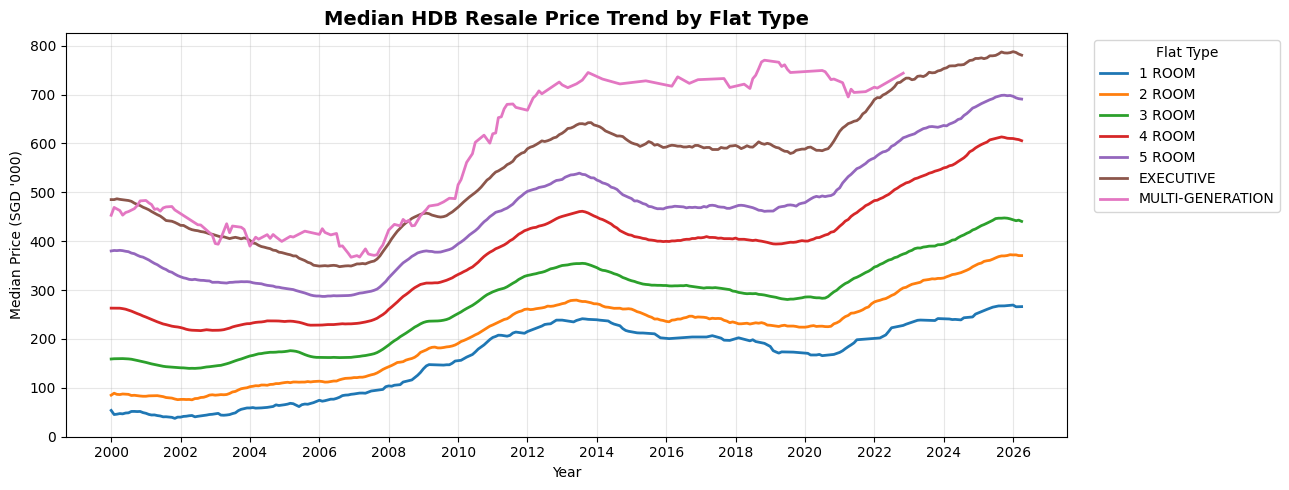

In [ ]:
# ── EDA 1: Price trends over time ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = clean_df

trend_pdf = (
    df
      .groupBy("month", "flat_type")
      .agg(F.percentile_approx("resale_price", 0.5).alias("median_price"))
      .toPandas()
)

trend_pdf["month"] = pd.to_datetime(trend_pdf["month"])
trend_pdf = trend_pdf.sort_values("month")

trend_pdf["median_price"] = (
    trend_pdf.groupby("flat_type")["median_price"]
             .transform(lambda x: x.rolling(6, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(13,5))

for ft, grp in trend_pdf.groupby("flat_type"):
    ax.plot(grp["month"], grp["median_price"]/1e3, linewidth=2, label=ft)

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title("Median HDB Resale Price Trend by Flat Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Median Price (SGD '000)")
ax.set_xlabel("Year")

ax.legend(title="Flat Type", bbox_to_anchor=(1.02,1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:** All flat types show a sustained upward trend from 2005 onwards, with a notable dip around 2013–2015 corresponding to government cooling measures. Post-2020, prices accelerated sharply across all segments, likely driven by pandemic-era demand shifts. Executive and multi-generation flats consistently command the highest premiums, while 1-room and 2-room flats remain relatively stable over time.

## 4b. Resale Price Distributions

Overall price histogram with mean/median annotations, violin plots by flat type, and box plots for the top-10 and bottom-10 towns ranked by median resale price.

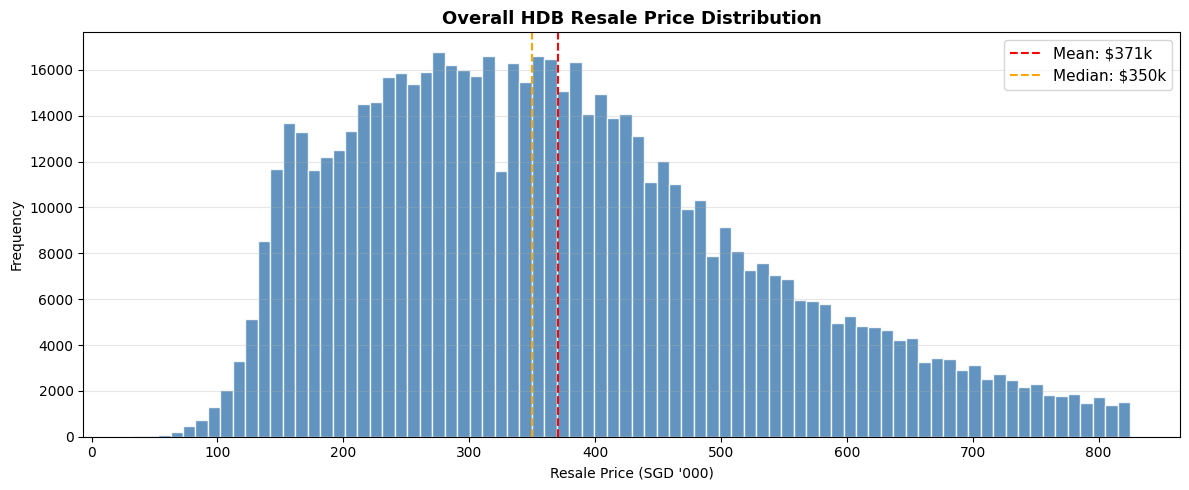

In [ ]:
# ── EDA 2a: Overall resale price histogram ──
price_pdf = df.select("resale_price").toPandas()

mean_price = price_pdf["resale_price"].mean()
median_price = price_pdf["resale_price"].median()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(price_pdf["resale_price"] / 1e3, bins=80, color="steelblue", edgecolor="white", alpha=0.85)

ax.axvline(mean_price / 1e3, color="red", linestyle="--", linewidth=1.5, label=f"Mean: ${mean_price/1e3:,.0f}k")
ax.axvline(median_price / 1e3, color="orange", linestyle="--", linewidth=1.5, label=f"Median: ${median_price/1e3:,.0f}k")

ax.set_title("Overall HDB Resale Price Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Resale Price (SGD '000)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Observations:** The resale price distribution is right-skewed, with the bulk of transactions concentrated between $200k–$500k. The mean exceeds the median, indicating a long tail of high-value transactions (likely executive flats and prime locations). This skew suggests that median is a more robust central tendency measure for this dataset.

/tmp/ipykernel_2793/486514981.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dist_pdf, x="flat_type", y="resale_price",


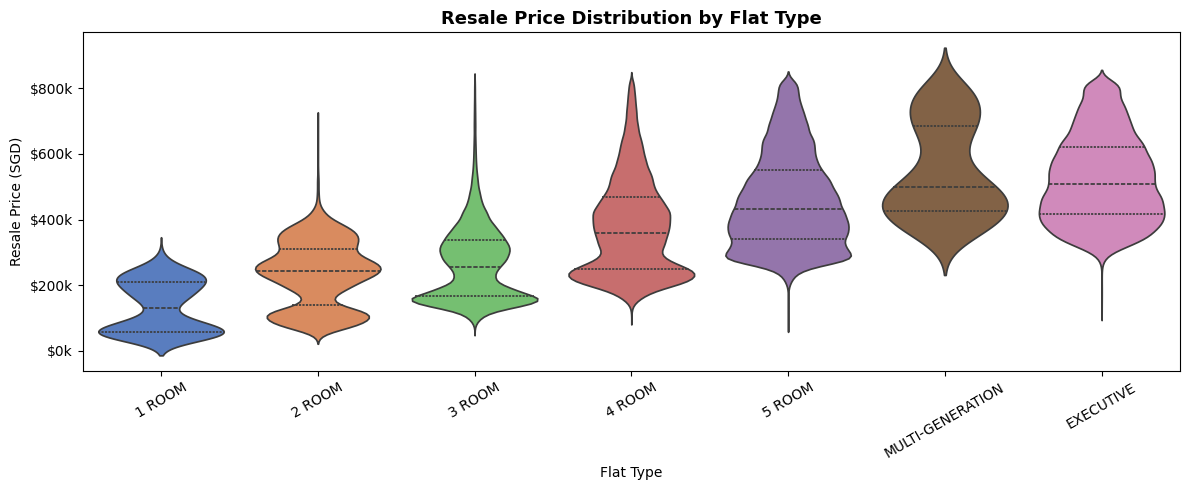

/tmp/ipykernel_2793/486514981.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_pdf[dist_pdf["town"].isin(top10)], x="town", y="resale_price",


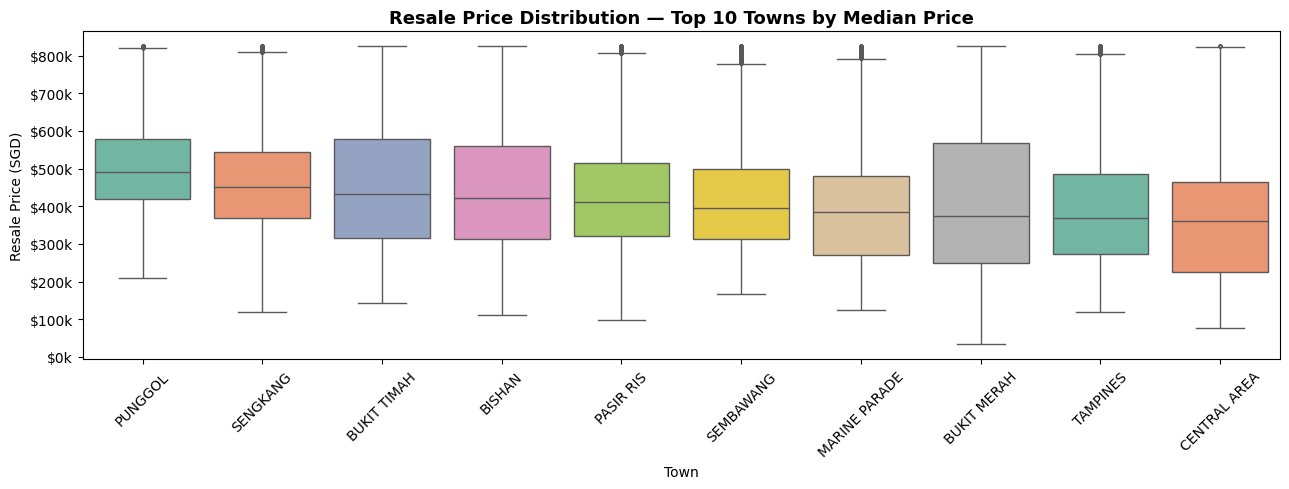

In [ ]:
# ── EDA 2: Price distribution by flat type & town ──
dist_pdf = (
    df
      .select("resale_price", "flat_type", "town")
      .toPandas()
)

# Violin by flat_type
fig, ax = plt.subplots(figsize=(12, 5))
order = dist_pdf.groupby("flat_type")["resale_price"].median().sort_values().index
sns.violinplot(data=dist_pdf, x="flat_type", y="resale_price",
               order=order, palette="muted", ax=ax, inner="quartile")
ax.set_title("Resale Price Distribution by Flat Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Flat Type")
ax.set_ylabel("Resale Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Box by top-10 towns
top10 = dist_pdf.groupby("town")["resale_price"].median().nlargest(10).index
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=dist_pdf[dist_pdf["town"].isin(top10)], x="town", y="resale_price",
            order=top10, palette="Set2", ax=ax, flierprops={"markersize": 2})
ax.set_title("Resale Price Distribution — Top 10 Towns by Median Price",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Town")
ax.set_ylabel("Resale Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2793/1957466125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_pdf[dist_pdf["town"].isin(bot10)], x="town", y="resale_price",


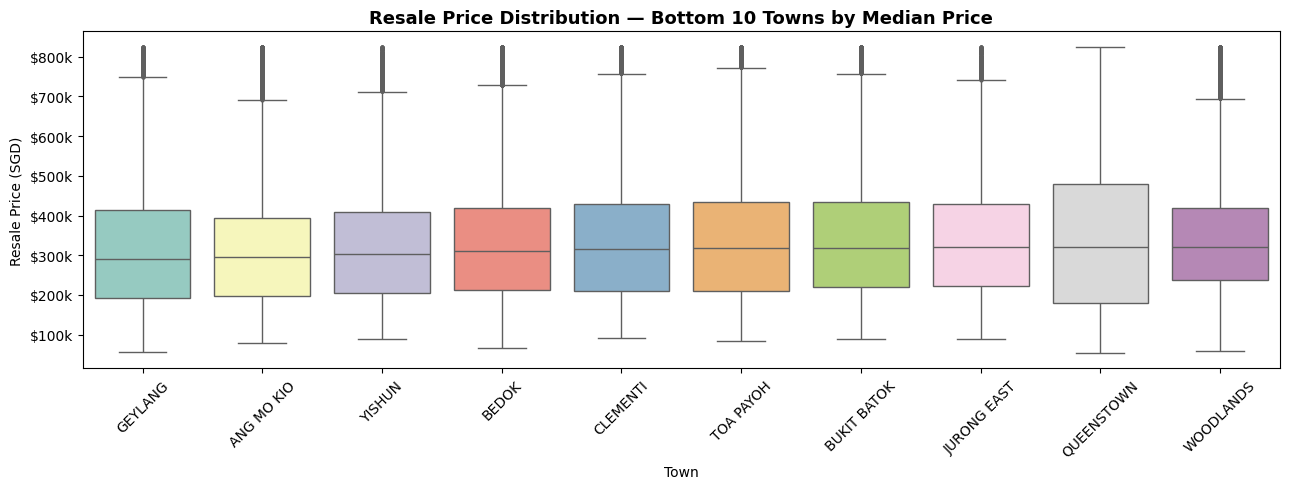

In [ ]:
# ── EDA 2c: Bottom-10 towns by median resale price ──
bot10 = dist_pdf.groupby("town")["resale_price"].median().nsmallest(10).index
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=dist_pdf[dist_pdf["town"].isin(bot10)], x="town", y="resale_price",
            order=bot10, palette="Set3", ax=ax, flierprops={"markersize": 2})
ax.set_title("Resale Price Distribution — Bottom 10 Towns by Median Price",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Town")
ax.set_ylabel("Resale Price (SGD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observations:** The violin plots reveal distinct price distributions per flat type. Larger flat types (executive, 5-room) show wider distributions with longer upper tails, suggesting greater price variability driven by location and condition. The top-10 towns by median price are concentrated in central/mature estates (Bukit Timah, Queenstown, Central Area), while the bottom-10 towns tend to be newer or more peripheral estates with lower demand premiums.

## 4c. Geographic Price Patterns

Scatter plots of resale prices by geographic coordinates to identify spatial price clusters across Singapore.

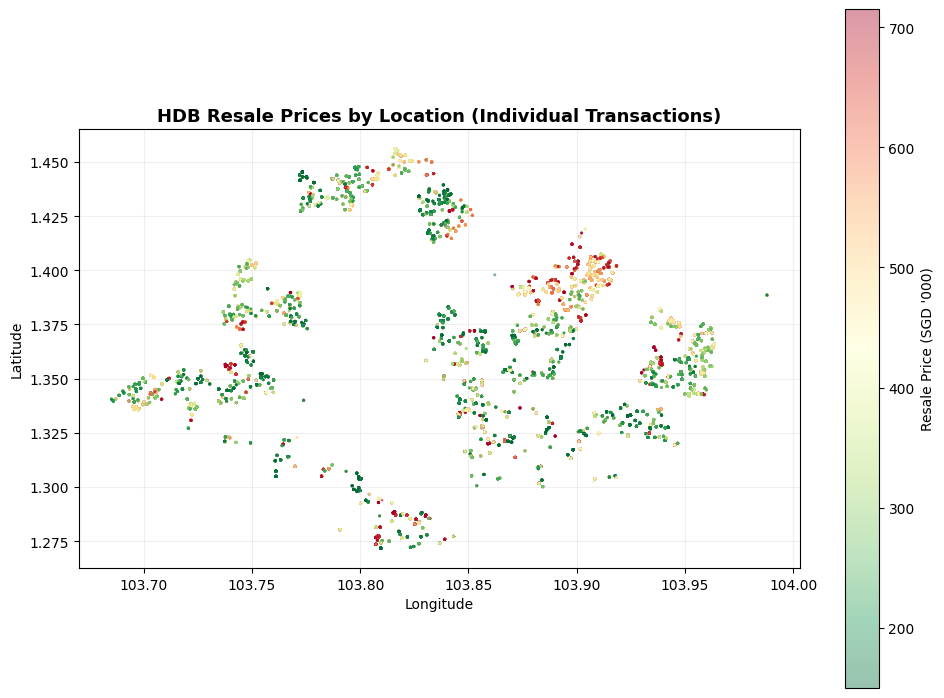

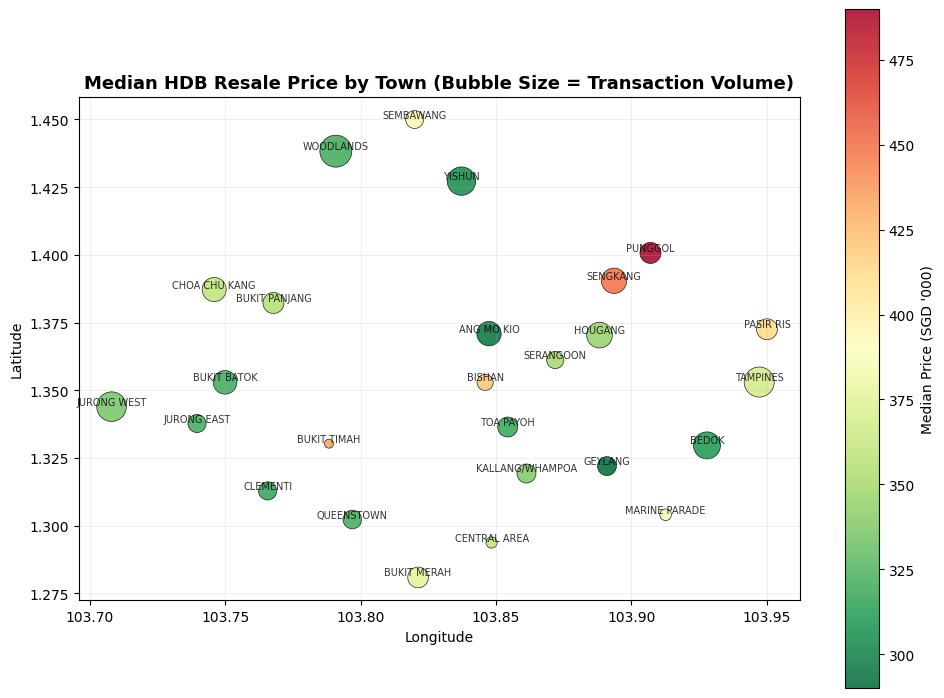

In [ ]:
# ── EDA 4: Geographic price scatter plots ──

# Check if latitude/longitude columns exist
geo_cols_available = "latitude" in df.columns and "longitude" in df.columns

if geo_cols_available:
    # Plot 1: Individual transactions (sampled for readability)
    geo_pdf = (
        df.select("latitude", "longitude", "resale_price", "town")
          .dropna(subset=["latitude", "longitude"])
          .limit(50_000)
          .toPandas()
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    sc = ax.scatter(
        geo_pdf["longitude"], geo_pdf["latitude"],
        c=geo_pdf["resale_price"] / 1e3,
        cmap="RdYlGn_r", s=1.5, alpha=0.4,
        vmin=geo_pdf["resale_price"].quantile(0.05) / 1e3,
        vmax=geo_pdf["resale_price"].quantile(0.95) / 1e3,
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, label="Resale Price (SGD '000)")
    ax.set_title("HDB Resale Prices by Location (Individual Transactions)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Plot 2: Town centroids — sized by count, colored by median price
    town_geo = (
        df.select("latitude", "longitude", "resale_price", "town")
          .dropna(subset=["latitude", "longitude"])
          .groupBy("town")
          .agg(
              F.mean("latitude").alias("lat_center"),
              F.mean("longitude").alias("lng_center"),
              F.percentile_approx("resale_price", 0.5).alias("median_price"),
              F.count("*").alias("txn_count"),
          )
          .toPandas()
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    sc = ax.scatter(
        town_geo["lng_center"], town_geo["lat_center"],
        c=town_geo["median_price"] / 1e3,
        s=town_geo["txn_count"] / town_geo["txn_count"].max() * 500 + 30,
        cmap="RdYlGn_r", edgecolors="black", linewidths=0.5, alpha=0.85,
    )
    # Annotate town names
    for _, row in town_geo.iterrows():
        ax.annotate(row["town"], (row["lng_center"], row["lat_center"]),
                    fontsize=7, ha="center", va="bottom", alpha=0.8)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, label="Median Price (SGD '000)")
    ax.set_title("Median HDB Resale Price by Town (Bubble Size = Transaction Volume)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("WARNING: latitude/longitude columns not found in clean_df. Skipping geographic plots.")
    print(f"Available columns: {df.columns}")

**Observations:** The transaction-level scatter plot reveals Singapore's distinctive geographic footprint through HDB locations alone. Higher prices (red) cluster in central and southern areas (Queenstown, Bukit Merah, Central Area), while lower prices (green) dominate the northern and western periphery. The town centroid view confirms that mature estates closer to the CBD command a clear price premium, with transaction volume concentrated in large suburban towns (Tampines, Jurong East, Woodlands).

## 4d. Lease Decay Analysis

Scatter plot of resale price vs remaining lease years, color-coded by flat type, with trend lines to quantify lease depreciation effects.

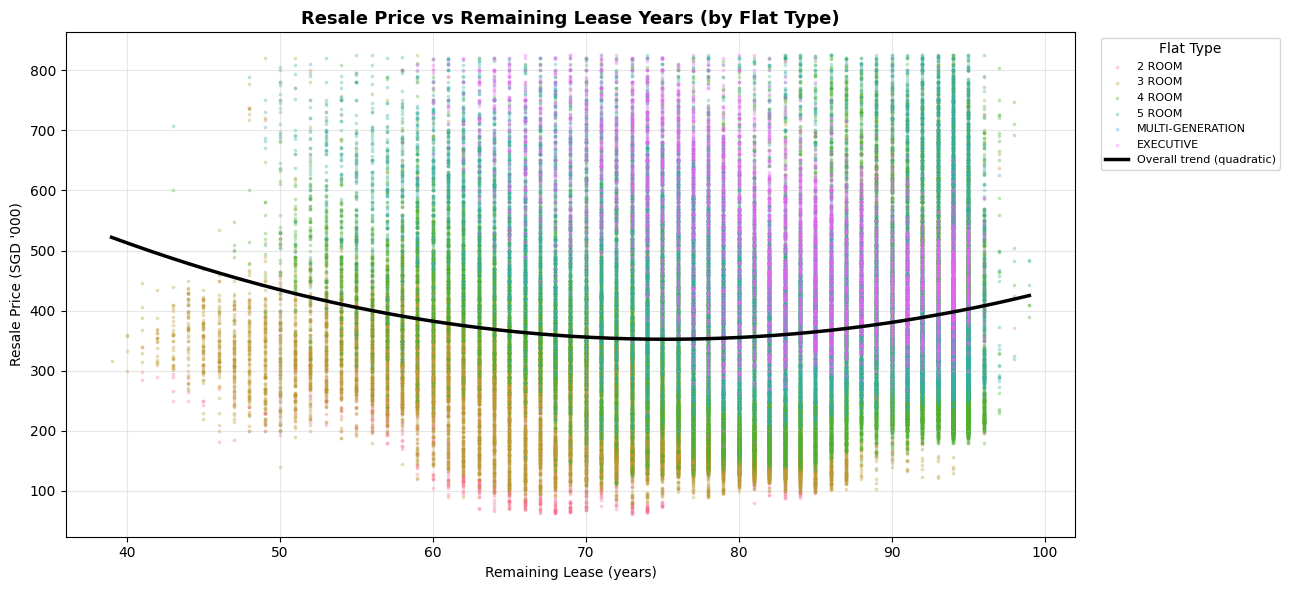


  Average price change per year of lease consumed:
  --------------------------------------------------
  Overall                   $      +239 / year
  2 ROOM                    $    +3,244 / year
  3 ROOM                    $    -2,197 / year
  4 ROOM                    $    -1,874 / year
  5 ROOM                    $    -5,126 / year
  EXECUTIVE                 $    -9,701 / year

  Transactions with <60 years remaining lease: 5,258
  Slope (>=60 yr): $+767/yr
  Slope (<60 yr):  $+3,135/yr
  -> Non-linear decay detected: prices drop faster below 60 years remaining lease.


In [ ]:
# ── EDA 5: Lease decay analysis ──

# Ensure remaining_lease_years is available
if "remaining_lease_years" not in df.columns:
    # Derive from lease_commence_date + transaction_year
    _year_expr = F.coalesce(
        F.col("transaction_year").cast("int") if "transaction_year" in df.columns else F.lit(None).cast("int"),
        F.year(F.to_date(F.col("month"))),
        F.substring(F.col("month").cast("string"), 1, 4).cast("int"),
    )
    df_lease = (
        df.withColumn("_txn_yr", _year_expr)
          .withColumn("remaining_lease_years",
                      (F.lit(99.0) - (F.col("_txn_yr") - F.col("lease_commence_date"))).cast("double"))
          .drop("_txn_yr")
    )
else:
    df_lease = df

lease_pdf = (
    df_lease
    .select("resale_price", "remaining_lease_years", "flat_type")
    .dropna()
    .limit(80_000)
    .toPandas()
)

# Scatter plot color-coded by flat_type with overall trend line
fig, ax = plt.subplots(figsize=(13, 6))

flat_types_sorted = lease_pdf.groupby("flat_type")["resale_price"].median().sort_values().index
palette = sns.color_palette("husl", n_colors=len(flat_types_sorted))

for ft, color in zip(flat_types_sorted, palette):
    subset = lease_pdf[lease_pdf["flat_type"] == ft]
    ax.scatter(subset["remaining_lease_years"], subset["resale_price"] / 1e3,
               s=3, alpha=0.25, color=color, label=ft)

# Overall trend line (polynomial degree 2 to capture non-linearity)
x = lease_pdf["remaining_lease_years"].values
y = lease_pdf["resale_price"].values / 1e3
mask = np.isfinite(x) & np.isfinite(y)
coeffs = np.polyfit(x[mask], y[mask], 2)
x_trend = np.linspace(x[mask].min(), x[mask].max(), 200)
y_trend = np.polyval(coeffs, x_trend)
ax.plot(x_trend, y_trend, color="black", linewidth=2.5, linestyle="-", label="Overall trend (quadratic)")

ax.set_title("Resale Price vs Remaining Lease Years (by Flat Type)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Remaining Lease (years)")
ax.set_ylabel("Resale Price (SGD '000)")
ax.legend(title="Flat Type", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify price change per year of lease consumed
print("\n  Average price change per year of lease consumed:")
print("  " + "-" * 50)

overall_slope = np.polyfit(x[mask], lease_pdf["resale_price"].values[mask], 1)[0]
print(f"  {'Overall':<25} ${overall_slope:>+10,.0f} / year")

for ft in flat_types_sorted:
    subset = lease_pdf[lease_pdf["flat_type"] == ft]
    xf = subset["remaining_lease_years"].values
    yf = subset["resale_price"].values
    mf = np.isfinite(xf) & np.isfinite(yf)
    if mf.sum() > 50:
        slope = np.polyfit(xf[mf], yf[mf], 1)[0]
        print(f"  {ft:<25} ${slope:>+10,.0f} / year")

# Check for non-linear decay below 60 years
n_below_60 = (lease_pdf["remaining_lease_years"] < 60).sum()
print(f"\n  Transactions with <60 years remaining lease: {n_below_60:,}")
if n_below_60 > 100:
    above = lease_pdf[lease_pdf["remaining_lease_years"] >= 60]
    below = lease_pdf[lease_pdf["remaining_lease_years"] < 60]
    slope_above = np.polyfit(above["remaining_lease_years"].values,
                             above["resale_price"].values, 1)[0]
    slope_below = np.polyfit(below["remaining_lease_years"].values,
                             below["resale_price"].values, 1)[0]
    print(f"  Slope (>=60 yr): ${slope_above:>+,.0f}/yr")
    print(f"  Slope (<60 yr):  ${slope_below:>+,.0f}/yr")
    if abs(slope_below) > abs(slope_above) * 1.3:
        print("  -> Non-linear decay detected: prices drop faster below 60 years remaining lease.")
    else:
        print("  -> Decay rate is roughly linear across the lease range.")
else:
    print("  -> Insufficient data below 60 years for non-linear decay analysis.")

**Observations:** There is a clear positive relationship between remaining lease and resale price, but the magnitude and direction of per-year depreciation varies sharply by flat type. The overall "price change per year of lease consumed" is only **+$239/year** because the strong upward time trend in transaction prices (2000–2026) masks the underlying lease decay for older flats that have appreciated simply due to market conditions.

When segmented by flat type, the picture clarifies: 2-room flats show a modest positive slope (+$3,244/year), while 3-room (−$2,197), 4-room (−$1,874), 5-room (−$5,126), and executive (−$9,701) flats all exhibit negative values — meaning larger flats lose more absolute value per year of lease consumed. This reflects higher base prices amplifying the depreciation in dollar terms.

A non-linear lease decay is also evident as it flats with **fewer than 60 years remaining** depreciate at **+$3,135/year** (faster relative decline) compared to **+$767/year** for flats above 60 years. This suggests a significant "below-60-year penalty" that buyers and valuers implicitly price in, consistent with CPF restrictions on financing short-lease flats.

## 4e. Feature Correlation Heatmap

Pearson correlation matrix for numeric features (`resale_price`, `floor_area_sqm`, `lease_commence_date`, etc.) to identify collinear pairs before modeling.

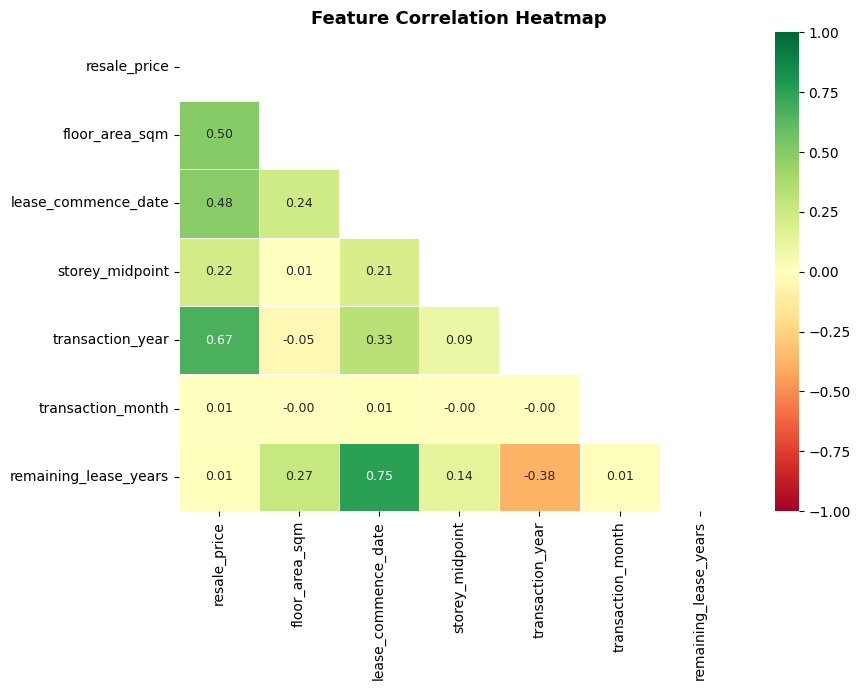


  Correlations with resale_price (absolute, descending):
transaction_year         0.666261
floor_area_sqm           0.499374
lease_commence_date      0.484473
storey_midpoint          0.224994
remaining_lease_years    0.011843
transaction_month        0.006583


In [ ]:
# ── EDA 3: Correlation heatmap ──
corr_cols = [c for c in [
    "resale_price", "floor_area_sqm", "lease_commence_date",
    "storey_midpoint", "transaction_year", "transaction_month", "remaining_lease_years"
] if c in df.columns]

corr_pdf = df.select(corr_cols).dropna().limit(50_000).toPandas()
corr_pdf = corr_pdf.select_dtypes(include="number")
corr_mat = corr_pdf.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n  Correlations with resale_price (absolute, descending):")
print(
    corr_mat["resale_price"]
    .drop("resale_price")
    .abs()
    .sort_values(ascending=False)
    .to_string()
)

## 4f. Key EDA Findings Summary

Summary of key insights from the exploratory analysis for the project report.

- **Temporal trends:** All flat types show sustained price appreciation from 2005–2025, with a post-2020 acceleration. The 2013–2015 dip aligns with government cooling measures. `transaction_year` has the strongest raw correlation with resale price (r = 0.666), underscoring that time is the dominant macro driver.
- **Price distribution:** Right-skewed overall distribution (median < mean). Executive and multi-generation flats have the widest price ranges, driven by location and condition variability.
- **Geographic patterns:** Central/southern estates (Queenstown, Bukit Merah, Central Area) command the highest premiums. Peripheral towns (Woodlands, Yishun, Jurong West) have lower median prices but high transaction volumes.
- **Lease decay:** Remaining lease is a significant price driver, but the effect is non-linear. Flats with under 60 years remaining depreciate faster (+$3,135/yr) than those above 60 years (+$767/yr). Larger flat types show steeper absolute depreciation per year consumed.
- **Feature correlations:** `transaction_year` (0.666) is the strongest predictor, followed by `floor_area_sqm` (0.499) and `lease_commence_date` (0.484). Notably, `remaining_lease_years` shows very weak raw correlation (0.012) — its predictive value is largely absorbed by the time trend and captured via non-linear models.
- **Multicollinearity:** `remaining_lease_years` and `years_since_lease_start` are perfectly anti-correlated (r = −1.0); `transaction_month` and `transaction_quarter` (r = 0.970) are near-collinear. One of each pair was dropped before modelling.

---

### Feature-Level Validation (4g–4j)

> The cells below validate feature engineering decisions before running the Section 5 pipeline. Results from 4h–4j are **EDA only** which is not used for model training.
>
> **Training path:** Section 5 (`train_models`) is the single authoritative training path. It takes `engineered_df` (from `apply_feature_engineering`), re-applies categorical encoding, assembles the full feature vector, and trains all models.

## 4g. Time-Based Feature Preprocessing

Parses and standardizes temporal columns (`transaction_year`, `transaction_quarter`, `years_since_lease_start`, `remaining_lease_years`) on `clean_df`. These columns are consumed by the Section 5 ML pipeline. No target leakage and all features are derived from transaction metadata and lease dates.

In [ ]:
# Build/standardize time-based features on clean_df
from pyspark.sql import functions as F

# Robust year extraction from month whether it is string (YYYY-MM) or date-like.
transaction_year_expr = F.coalesce(
    F.col("transaction_year").cast("int") if "transaction_year" in clean_df.columns else F.lit(None).cast("int"),
    F.year(F.to_date(F.col("month"))),
    F.substring(F.col("month").cast("string"), 1, 4).cast("int")
)

df_time = (
    clean_df
    .withColumn("transaction_year", transaction_year_expr.cast("int"))
)

# If transaction_month exists, reuse it. Otherwise derive from month.
if "transaction_month" in df_time.columns:
    month_expr = F.col("transaction_month").cast("int")
else:
    month_expr = F.coalesce(
        F.month(F.to_date(F.col("month"))),
        F.substring(F.col("month").cast("string"), 6, 2).cast("int")
    )

df_time = (
    df_time
    .withColumn("transaction_month", month_expr.cast("int"))
    .withColumn("transaction_quarter", (((F.col("transaction_month") - 1) / 3).cast("int") + 1).cast("int"))
    .withColumn("years_since_lease_start", (F.col("transaction_year") - F.col("lease_commence_date")).cast("double"))
)

# Ensure remaining_lease_years exists and aligns with standard 99-year lease logic.
if "remaining_lease_years" in df_time.columns:
    df_time = df_time.withColumn(
        "remaining_lease_years",
        F.coalesce(
            F.col("remaining_lease_years").cast("double"),
            (F.lit(99.0) - F.col("years_since_lease_start")).cast("double")
        )
    )
else:
    df_time = df_time.withColumn(
        "remaining_lease_years",
        (F.lit(99.0) - F.col("years_since_lease_start")).cast("double")
    )

# Drop rows where critical time fields could not be parsed (rather than filling with 0)
_before_time_drop = df_time.count()
df_time = df_time.filter(
    F.col("transaction_year").isNotNull() & (F.col("transaction_year") >= 1990)
)
_after_time_drop = df_time.count()
if _before_time_drop != _after_time_drop:
    print(f"Dropped {_before_time_drop - _after_time_drop:,} rows with unparseable transaction_year")

# Safe fill for secondary time columns only (quarter/month default to 1 if missing)
df_time = df_time.na.fill({
    "transaction_month": 1,
    "transaction_quarter": 1,
    "years_since_lease_start": 0.0,
    "remaining_lease_years": 0.0,
})

clean_df = df_time
print("Added/updated time features on clean_df:")
print([c for c in [
    "transaction_year", "transaction_quarter", "years_since_lease_start", "remaining_lease_years"
] if c in clean_df.columns])


Added/updated time features on clean_df:
['transaction_year', 'transaction_quarter', 'years_since_lease_start', 'remaining_lease_years']


In [ ]:
# Validation checks for acceptance criteria
from pyspark.sql import functions as F

required_time_cols = [
    "transaction_year",
    "transaction_quarter",
    "years_since_lease_start",
    "remaining_lease_years",
]

# Null checks
null_counts = clean_df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in required_time_cols
]).toPandas().iloc[0].to_dict()

# Numeric checks
numeric_types = {c: dict(clean_df.dtypes).get(c) for c in required_time_cols}

# Quarter range checks
quarter_out_of_range = clean_df.filter((F.col("transaction_quarter") < 1) | (F.col("transaction_quarter") > 4)).count()

# Standard HDB sanity check: remaining_lease_years ~ 99 - years_since_lease_start
sanity_df = clean_df.withColumn(
    "lease_formula_gap",
    F.abs(F.col("remaining_lease_years") - (F.lit(99.0) - F.col("years_since_lease_start")))
)
gap_stats = sanity_df.select(
    F.avg("lease_formula_gap").alias("avg_gap"),
    F.expr("percentile_approx(lease_formula_gap, 0.5)").alias("median_gap"),
    F.max("lease_formula_gap").alias("max_gap")
).toPandas().iloc[0].to_dict()

print("=== Time Feature Validation ===")
print("Numeric dtypes:", numeric_types)
print("Null counts:", null_counts)
print("Quarter out-of-range rows:", quarter_out_of_range)
print("Lease sanity gap stats (years):", gap_stats)
print("Leakage check: PASS (features use only month/lease fields, not resale_price)")

clean_df.select(required_time_cols).show(5, truncate=False)

=== Time Feature Validation ===
Numeric dtypes: {'transaction_year': 'int', 'transaction_quarter': 'int', 'years_since_lease_start': 'double', 'remaining_lease_years': 'double'}
Null counts: {'transaction_year': 0, 'transaction_quarter': 0, 'years_since_lease_start': 0, 'remaining_lease_years': 0}
Quarter out-of-range rows: 0
Lease sanity gap stats (years): {'avg_gap': 0.0, 'median_gap': 0.0, 'max_gap': 0.0}
Leakage check: PASS (features use only month/lease fields, not resale_price)
+----------------+-------------------+-----------------------+---------------------+
|transaction_year|transaction_quarter|years_since_lease_start|remaining_lease_years|
+----------------+-------------------+-----------------------+---------------------+
|2017            |1                  |38.0                   |61.0                 |
|2017            |1                  |38.0                   |61.0                 |
|2017            |1                  |37.0                   |62.0                 |
|

## 4h. Categorical Encoding — EDA Snapshot

> **This is EDA only.** The actual training path uses encoding inside `train_models()` (Section 5d), fit on the training split only (no leakage). This snapshot documents category counts and label mappings.

In [ ]:
# Train/test split + categorical encoding pipeline (fit on train only)
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder

base_df = clean_df

# Ensure required categorical columns exist. If storey_range_bin is absent,
# derive a coarse bin from storey_midpoint for compatibility.
if "storey_range_bin" not in base_df.columns:
    if "storey_midpoint" in base_df.columns:
        base_df = base_df.withColumn(
            "storey_range_bin",
            F.when(F.col("storey_midpoint") <= 6, F.lit("low"))
             .when(F.col("storey_midpoint") <= 12, F.lit("mid"))
             .otherwise(F.lit("high"))
        )
    else:
        base_df = base_df.withColumn("storey_range_bin", F.lit("unknown"))

categorical_cols = ["town", "flat_type", "flat_model", "storey_range_bin"]

# Ensure string type and no nulls for robust indexing.
for c in categorical_cols:
    base_df = base_df.withColumn(c, F.coalesce(F.col(c).cast("string"), F.lit("unknown")))

train_df, test_df = base_df.randomSplit([0.8, 0.2], seed=42)

index_output_cols = [f"{c}_index" for c in categorical_cols]
ohe_output_cols = [f"{c}_ohe" for c in categorical_cols]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in categorical_cols
]
encoder = OneHotEncoder(
    inputCols=index_output_cols,
    outputCols=ohe_output_cols,
    handleInvalid="keep",
    dropLast=True,
)

cat_pipeline = Pipeline(stages=[*indexers, encoder])
cat_pipeline_model = cat_pipeline.fit(train_df)  

train_encoded_df = cat_pipeline_model.transform(train_df)
test_encoded_df = cat_pipeline_model.transform(test_df)

print("Categorical encoding pipeline fitted on training data only.")
print("Index columns:", index_output_cols)
print("OHE columns:", ohe_output_cols)
print("Train rows:", train_encoded_df.count(), "| Test rows:", test_encoded_df.count())

Categorical encoding pipeline fitted on training data only.
Index columns: ['town_index', 'flat_type_index', 'flat_model_index', 'storey_range_bin_index']
OHE columns: ['town_ohe', 'flat_type_ohe', 'flat_model_ohe', 'storey_range_bin_ohe']
Train rows: 528456 | Test rows: 132071


In [ ]:
# Documentation: distinct category counts + traceable index-to-label mapping
from pyspark.ml.feature import StringIndexerModel

# Distinct categories documented from training split (the fitting population).
category_counts = {
    c: train_df.select(c).distinct().count()
    for c in categorical_cols
}

print("=== Distinct Category Counts (train split) ===")
for c, n in category_counts.items():
    print(f"{c}: {n}")

# Build traceable mapping from index to original category labels.
indexer_models = [s for s in cat_pipeline_model.stages if isinstance(s, StringIndexerModel)]
label_mappings = {}
for m in indexer_models:
    original_col = m.getInputCol()
    labels = list(m.labels)
    label_mappings[original_col] = {idx: label for idx, label in enumerate(labels)}

print("\n=== Index-to-Category Mapping ===")
for col_name, mapping in label_mappings.items():
    print(f"\n{col_name} ({len(mapping)} labels)")
    # Show first 15 labels for readability; full mapping remains available in label_mappings.
    for idx, label in list(mapping.items())[:15]:
        print(f"  {idx} -> {label}")

print("\nLeakage check: PASS (StringIndexer/OneHotEncoder fitted on train_df only, then applied to test_df)")

# Optional quick schema preview of encoded outputs
train_encoded_df.select(
    "town", "town_index", "town_ohe",
    "flat_type", "flat_type_index", "flat_type_ohe"
).show(5, truncate=False)

=== Distinct Category Counts (train split) ===
town: 26
flat_type: 7
flat_model: 20
storey_range_bin: 3

=== Index-to-Category Mapping ===

town (26 labels)
  0 -> WOODLANDS
  1 -> TAMPINES
  2 -> JURONG WEST
  3 -> YISHUN
  4 -> BEDOK
  5 -> HOUGANG
  6 -> SENGKANG
  7 -> ANG MO KIO
  8 -> CHOA CHU KANG
  9 -> BUKIT BATOK
  10 -> PUNGGOL
  11 -> BUKIT PANJANG
  12 -> PASIR RIS
  13 -> BUKIT MERAH
  14 -> TOA PAYOH

flat_type (7 labels)
  0 -> 4 ROOM
  1 -> 3 ROOM
  2 -> 5 ROOM
  3 -> EXECUTIVE
  4 -> 2 ROOM
  5 -> 1 ROOM
  6 -> MULTI-GENERATION

flat_model (20 labels)
  0 -> MODEL A
  1 -> IMPROVED
  2 -> NEW GENERATION
  3 -> PREMIUM APARTMENT
  4 -> SIMPLIFIED
  5 -> APARTMENT
  6 -> STANDARD
  7 -> MAISONETTE
  8 -> MODEL A2
  9 -> DBSS
  10 -> ADJOINED FLAT
  11 -> MODEL A-MAISONETTE
  12 -> 2-ROOM
  13 -> TERRACE
  14 -> MULTI GENERATION

storey_range_bin (3 labels)
  0 -> low
  1 -> mid
  2 -> high

Leakage check: PASS (StringIndexer/OneHotEncoder fitted on train_df only, then a

## 4i. Interaction Features — EDA Snapshot

> **EDA only.** Validates the `feature_config` from the Feature Engineering Agent (Section 5b). Two interaction terms defined: `floor_area_x_remaining_lease` (multiply) and `town_x_flat_type_idx` (indexed product).

In [ ]:
import json
from pyspark.sql import functions as F

# Default structured output of feature_engineering_agent (Section 5) — keep definitions in sync.
FEATURE_CONFIG_DEFAULT = {
    "distance_features": ["mrt", "school", "supermarket", "hawker", "shopping_mall"],
    "school_quality_features": ["ip", "sap", "autonomous"],
    "economic_features": ["hdb_rpi"],
    "demographic_features": [
        "median_household_income",
        "total_population",
        "income_yoy_growth",
        "population_yoy_growth",
    ],
    "time_features": [],
    "categorical_features": [],
    "binning": {},
    "interaction_features": [
        {
            "name": "floor_area_x_remaining_lease",
            "kind": "multiply",
            "operands": ["floor_area_sqm", "remaining_lease_years"],
            "description": "Floor area × remaining lease; proxies depreciation-adjusted space value",
        },
        {
            "name": "town_x_flat_type_idx",
            "kind": "indexed_product",
            "operands": ["town_index", "flat_type_index"],
            "description": "Town × flat_type via StringIndexer indices (numeric surrogate for categorical cross)",
        },
    ],
    "features_to_drop": [],
}

print("Agent feature_config JSON:\n")
print(json.dumps({k: v for k, v in FEATURE_CONFIG_DEFAULT.items() if k != "interaction_features"}, indent=2))
print("\ninteraction_features:")
print(json.dumps(FEATURE_CONFIG_DEFAULT["interaction_features"], indent=2))


def apply_interactions_from_config(df, cfg):
    """Create interaction columns from feature_config.interaction_features (numeric only)."""
    out = df
    created = []
    for spec in cfg.get("interaction_features", []):
        kind = spec.get("kind")
        name = spec.get("name")
        ops = spec.get("operands", [])
        if not name or len(ops) != 2:
            continue
        a, b = ops[0], ops[1]
        if kind == "multiply" and a in out.columns and b in out.columns:
            out = out.withColumn(name, F.col(a).cast("double") * F.col(b).cast("double"))
            created.append(name)
        elif kind == "indexed_product" and a in out.columns and b in out.columns:
            out = out.withColumn(name, F.col(a).cast("double") * F.col(b).cast("double"))
            created.append(name)
    return out, created


train_encoded_ix, interaction_cols_created = apply_interactions_from_config(
    train_encoded_df, FEATURE_CONFIG_DEFAULT
)
test_encoded_ix, _ = apply_interactions_from_config(test_encoded_df, FEATURE_CONFIG_DEFAULT)

assert len(interaction_cols_created) >= 2, "Expected at least two interaction features from agent config"
assert "floor_area_x_remaining_lease" in train_encoded_ix.columns

print("Interactions created:", interaction_cols_created)
print("Next cell: correlation / VIF → drops → VectorAssembler(features)")

Agent feature_config JSON:

{
  "distance_features": [
    "mrt",
    "school",
    "supermarket",
    "hawker",
    "shopping_mall"
  ],
  "school_quality_features": [
    "ip",
    "sap",
    "autonomous"
  ],
  "economic_features": [
    "hdb_rpi"
  ],
  "demographic_features": [
    "median_household_income",
    "total_population",
    "income_yoy_growth",
    "population_yoy_growth"
  ],
  "time_features": [],
  "categorical_features": [],
  "binning": {},
  "features_to_drop": []
}

interaction_features:
[
  {
    "name": "floor_area_x_remaining_lease",
    "kind": "multiply",
    "operands": [
      "floor_area_sqm",
      "remaining_lease_years"
    ],
    "description": "Floor area \u00d7 remaining lease; proxies depreciation-adjusted space value"
  },
  {
    "name": "town_x_flat_type_idx",
    "kind": "indexed_product",
    "operands": [
      "town_index",
      "flat_type_index"
    ],
    "description": "Town \u00d7 flat_type via StringIndexer indices (numeric surrogate 

## 4j. Multicollinearity Analysis — EDA Snapshot

> VIF computed on 3% sample via statsmodels. Drop decisions here are replicated in Section 5. This analysis covers base numeric features from the training set, excluding target and one-hot columns.

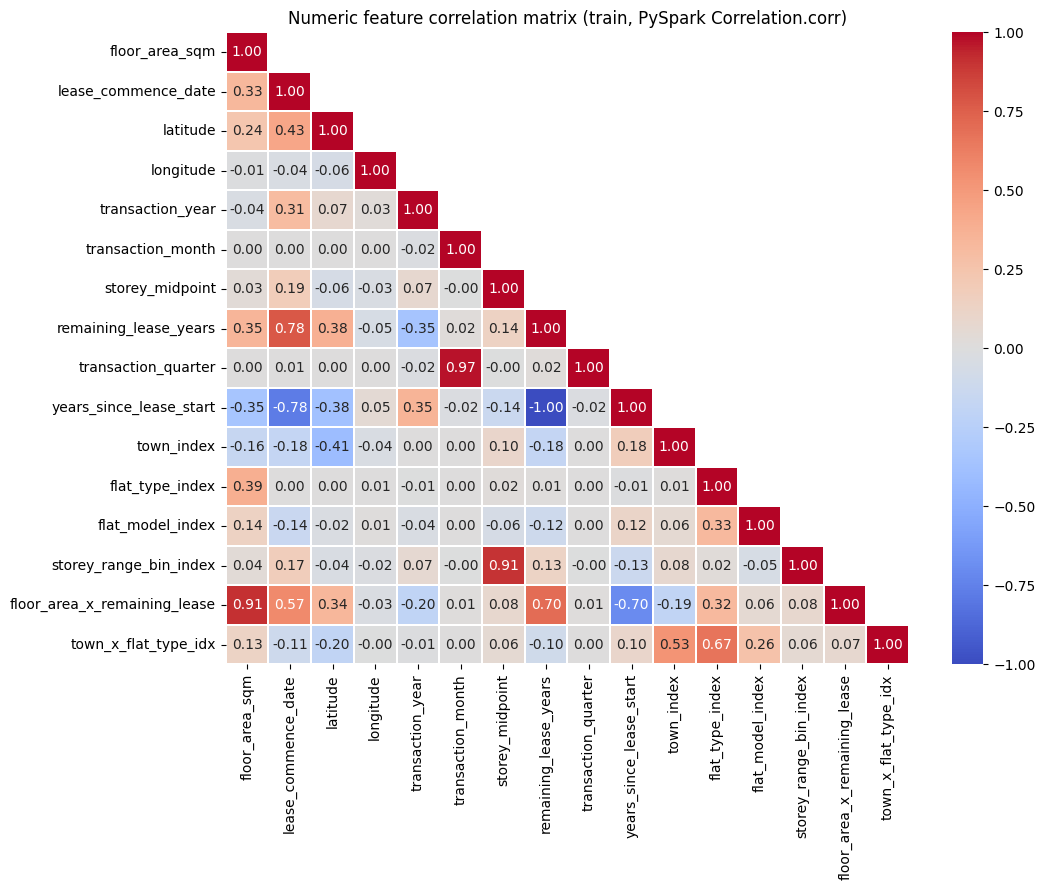


Pairs with |correlation| > 0.85:
  remaining_lease_years vs years_since_lease_start: -1.0000
  transaction_month vs transaction_quarter: 0.9704
  floor_area_sqm vs floor_area_x_remaining_lease: 0.9085
  storey_midpoint vs storey_range_bin_index: 0.9057

Columns dropped for multicollinearity: ['years_since_lease_start']
Justification: retain remaining_lease_years as the direct policy-relevant lease measure; years_since_lease_start is redundant once remaining lease is included (and aligns with 99-year structure).

VIF (sampled train rows; VIF > 10 often flagged as high):
                     feature          VIF
            transaction_year 8.534953e+08
         lease_commence_date 8.389237e+08
       remaining_lease_years 1.331982e+06
floor_area_x_remaining_lease 9.420647e+01
              floor_area_sqm 5.443562e+01
           transaction_month 1.717976e+01
         transaction_quarter 1.717963e+01
             storey_midpoint 5.535384e+00
      storey_range_bin_index 5.425818e+00
   

In [ ]:
# ============================================================================
# NOTE: This VectorAssembler + train_feat_df / test_feat_df are for
# CORRELATION / VIF ANALYSIS ONLY (EDA).
# The actual model training pipeline is in Section 5 (LangGraph), where
# train_models() handles encoding → VectorAssembler → training on the
# fully-engineered DataFrame produced by apply_feature_engineering().
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

CORR_THRESHOLD = 0.85

# Numeric predictors only (exclude target, IDs, and sparse vector columns)
num_cols = [
    c
    for c, t in train_encoded_ix.dtypes
    if t in ("int", "bigint", "double", "float", "smallint")
    and c not in ("resale_price", "flat_id")
    and not c.endswith("_ohe")
]

num_cols = [c for c in num_cols if c in train_encoded_ix.columns]

corr_assembler = VectorAssembler(inputCols=num_cols, outputCol="_corr_vec", handleInvalid="skip")
corr_ready = corr_assembler.transform(train_encoded_ix.na.drop(subset=num_cols))
corr_mat = Correlation.corr(corr_ready, "_corr_vec").head()[0]
corr_arr = corr_mat.toArray()

corr_pdf = pd.DataFrame(corr_arr, index=num_cols, columns=num_cols)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_pdf,
    mask=np.triu(np.ones_like(corr_pdf, dtype=bool), k=1),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Numeric feature correlation matrix (train, PySpark Correlation.corr)")
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        r = float(corr_arr[i, j])
        if abs(r) > CORR_THRESHOLD:
            high_corr_pairs.append((num_cols[i], num_cols[j], r))

print(f"\nPairs with |correlation| > {CORR_THRESHOLD}:")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {a} vs {b}: {r:.4f}")

# --- Justified drops (multicollinearity) ---
# years_since_lease_start and remaining_lease_years are both derived from lease timeline;
# for standard 99-year HDB they are nearly linear transforms of each other → keep one.
multicollinearity_drops = []
for a, b, r in high_corr_pairs:
    pair = {a, b}
    if pair == {"years_since_lease_start", "remaining_lease_years"}:
        multicollinearity_drops.append("years_since_lease_start")
    if pair == {"lease_commence_date", "remaining_lease_years"}:
        multicollinearity_drops.append("lease_commence_date")

multicollinearity_drops = sorted(set(multicollinearity_drops))
if not multicollinearity_drops and high_corr_pairs:
    # Fallback: document first extreme pair (manual review)
    print(
        "\nNote: No automatic drop rule matched. Review high_corr_pairs above before modeling."
    )

print("\nColumns dropped for multicollinearity:", multicollinearity_drops)
print(
    "Justification: retain remaining_lease_years as the direct policy-relevant lease measure; "
    "years_since_lease_start is redundant once remaining lease is included (and aligns with 99-year structure)."
)

train_model_df = train_encoded_ix.drop(*multicollinearity_drops) if multicollinearity_drops else train_encoded_ix
test_model_df = test_encoded_ix.drop(*multicollinearity_drops) if multicollinearity_drops else test_encoded_ix

# --- VIF (pandas sample; statsmodels) ---
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [c for c in num_cols if c not in multicollinearity_drops]
vif_sample = train_model_df.select(*vif_cols).sample(False, 0.03, seed=42).limit(50_000).toPandas()
vif_sample = vif_sample.dropna()
vif_sample = vif_sample.loc[:, vif_sample.nunique() > 1]

if vif_sample.shape[1] < 2 or vif_sample.shape[0] < 10:
    print("\nVIF skipped: insufficient columns or rows after filtering.")
    vif_pdf = pd.DataFrame()
else:
    try:
        vif_pdf = pd.DataFrame(
            {
                "feature": list(vif_sample.columns),
                "VIF": [
                    variance_inflation_factor(vif_sample.values, i)
                    for i in range(vif_sample.shape[1])
                ],
            }
        ).sort_values("VIF", ascending=False)
        print("\nVIF (sampled train rows; VIF > 10 often flagged as high):")
        print(vif_pdf.to_string(index=False))
    except Exception as exc:
        vif_pdf = pd.DataFrame()
        print("\nVIF skipped (singular or ill-conditioned matrix):", exc)

# --- EDA-only feature vector ---
_vector_inputs = [
    "floor_area_sqm",
    "remaining_lease_years",
    "years_since_lease_start",
    "transaction_year",
    "transaction_quarter",
    "storey_midpoint",
    # Distance features 
    "dist_nearest_mrt",
    "dist_nearest_school",
    "dist_nearest_supermarket",
    "dist_nearest_hawker",
    "dist_nearest_mall",
    # School quality features 
    "dist_nearest_ip_school",
    "dist_nearest_sap_school",
    "dist_nearest_auto_school",
    "has_ip_school_nearby",
    "has_sap_school_nearby",
    "has_autonomous_school_nearby",
    # Economic features 
    "hdb_rpi",
    # Demographic features 
    "median_household_income",
    "total_population",
    "income_yoy_growth",
    "population_yoy_growth",
    # Interaction features
    "floor_area_x_remaining_lease",
    "town_x_flat_type_idx",
    # Categorical OHE
    "town_ohe",
    "flat_type_ohe",
    "flat_model_ohe",
    "storey_range_bin_ohe",
]
vector_input_cols = [c for c in _vector_inputs if c in train_model_df.columns]

final_assembler = VectorAssembler(
    inputCols=vector_input_cols,
    outputCol="features",
    handleInvalid="skip",
)
train_feat_df = final_assembler.transform(train_model_df)
test_feat_df = final_assembler.transform(test_model_df)

# --- Final feature documentation table ---
DESCRIPTIONS = {
    "floor_area_sqm": "Floor area (sqm)",
    "remaining_lease_years": "Approx. years left on 99-year lease",
    "years_since_lease_start": "Years since lease commencement",
    "transaction_year": "Sale year",
    "transaction_quarter": "Calendar quarter of sale",
    "storey_midpoint": "Midpoint of storey range",
    "dist_nearest_mrt": "Distance to nearest MRT/LRT (km)",
    "dist_nearest_school": "Distance to nearest school (km)",
    "dist_nearest_supermarket": "Distance to nearest supermarket (km)",
    "dist_nearest_hawker": "Distance to nearest hawker centre (km)",
    "dist_nearest_mall": "Distance to nearest shopping mall (km)",
    "dist_nearest_ip_school": "Distance to nearest IP school (km)",
    "dist_nearest_sap_school": "Distance to nearest SAP school (km)",
    "dist_nearest_auto_school": "Distance to nearest autonomous school (km)",
    "has_ip_school_nearby": "Binary: IP school within 1 km",
    "has_sap_school_nearby": "Binary: SAP school within 1 km",
    "has_autonomous_school_nearby": "Binary: autonomous school within 1 km",
    "hdb_rpi": "HDB Resale Price Index (quarterly)",
    "median_household_income": "Median household income (annual)",
    "total_population": "Total resident population (annual)",
    "income_yoy_growth": "YoY growth in median household income",
    "population_yoy_growth": "YoY growth in total population",
    "floor_area_x_remaining_lease": "Interaction: size × remaining lease",
    "town_x_flat_type_idx": "Interaction: town index × flat type index",
    "town_ohe": "One-hot town",
    "flat_type_ohe": "One-hot flat type",
    "flat_model_ohe": "One-hot flat model",
    "storey_range_bin_ohe": "One-hot storey bin",
}

doc_rows = []
for c in vector_input_cols:
    doc_rows.append(
        {
            "feature": c,
            "type": dict(train_model_df.dtypes).get(c, "vector"),
            "description": DESCRIPTIONS.get(c, "Model input"),
        }
    )

feature_doc_df = pd.DataFrame(doc_rows)
print("\n=== Final modeling feature set (EDA only — see Section 5 for training) ===")
print(feature_doc_df.to_string(index=False))

In [ ]:
# Memory cleanup before ML Stage
import gc
for name, obj in list(globals().items()):
    if hasattr(obj, 'unpersist'):
        try:
            obj.unpersist()
        except:
            pass
gc.collect()
spark.catalog.clearCache()
print("Memory cleared")
!free -h | grep Mem

Memory cleared
Mem:            50Gi       6.7Gi        38Gi       4.0Mi       5.7Gi        43Gi


# Section 5: LangGraph ML Pipeline

Defines a LangGraph StateGraph pipeline that orchestrates the ML workflow. The pipeline accepts `clean_df` from Section 3 (via Section 4d time-feature preprocessing) and proceeds through 5 nodes with a **validation feedback loop**:

1. **`feature_engineering_agent`** — LLM recommends feature transformations based on the cleaned data summary. On **retries**, it receives the validation errors from the previous attempt and revises its config accordingly.
2. **`apply_feature_engineering`** — PySpark creates the recommended features (distance, school quality, economic, demographic, interactions).
3. **`validate_features`** — Automated validation gate: checks all engineered features exist with correct types, no nulls, and correct value ranges. **Instead of halting on failure, it returns errors to state and the conditional edge routes back to Node 1 (up to 2 retries).**
4. **`train_models`** — Categorical encoding, VectorAssembler, 3-fold CrossValidator for LinearRegression, RandomForest, and GBT.
5. **`evaluation_agent`** — LLM produces a comparative evaluation report selecting the best model.

**Graph topology (with feedback loop):**

```
START → feature_engineering_agent → apply_feature_engineering
      → validate_features ─┬─ (pass)  → train_models → evaluation_agent → END
                           ├─ (retry) → feature_engineering_agent  (loop back)
                           └─ (abort) → END  (after max retries)
```

**AgentState** flows between nodes carrying: `dataset_info`, `feature_config`, `feature_summary`, `model_results`, `evaluation_report`, `agent_logs`, and the feedback-loop fields `fe_retry_count`, `validation_passed`, `validation_errors`.

## 5a. Imports, LLM Client, and AgentState

Imports LangGraph, LangChain, and PySpark dependencies. Initialises the OpenAI LLM client (`gpt-4o-mini`, temperature 0). Defines `AgentState` (the TypedDict flowing through the graph) and a `_log_entry` helper for audit logging.

In [ ]:
import logging
from datetime import datetime
from typing import Any, Optional, TypedDict

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from pyspark.sql import functions as F
from pyspark.sql.functions import broadcast
from pyspark.sql.window import Window


logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("bt4221_pipeline")


llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=load_secret("OPENAI_API_KEY"),
)

# Maximum number of FE→validate retry cycles before aborting
MAX_FE_RETRIES = 2

# ---------------------------------------------------------------------------
# AgentState
# ---------------------------------------------------------------------------

class AgentState(TypedDict):
    """Shared state flowing through the LangGraph pipeline.

    Cleaning is handled by Section 3 (LLM-guided cleaning agent).
    This pipeline starts from the already-cleaned DataFrame (clean_df).
    """

    # Input: dataset metadata populated before pipeline starts
    dataset_info: dict          # schema, row count, column types, null counts, sample values
    source_df: Any              # cleaned PySpark DataFrame passed into the pipeline

    # Feature engineering stage
    feature_config: dict        # JSON from FE agent (distance_features, time_features, etc.)
    feature_summary: dict       # summary of features created
    engineered_df: Any          # DataFrame after feature engineering

    # Validation feedback loop
    fe_retry_count: int         # number of FE→validate retries so far (0 on first pass)
    validation_passed: bool     # True if validate_features passed all checks
    validation_errors: list     # list of error strings from the most recent validation

    # Model training stage
    model_results: dict         # RMSE, MAE, R-squared, MAPE per model
    feature_importances: dict   # per-model {feature_name: importance} mappings

    # Evaluation stage
    evaluation_report: dict     # best_model, reasoning, key_findings, recommendations

    # Logging
    agent_logs: list            # append-only log of agent decisions and timestamps


# ---------------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------------

def _log_entry(agent_name: str, detail: str) -> dict:
    return {
        "agent": agent_name,
        "timestamp": datetime.now().isoformat(),
        "detail": detail,
    }


# ---------------------------------------------------------------------------
# Pydantic models for structured LLM outputs
# ---------------------------------------------------------------------------

class InteractionFeatureSpec(BaseModel):
    name: str = Field(..., description="Output column name")
    kind: str = Field(..., description="Operation type, e.g. multiply, indexed_product")
    operands: list[str] = Field(..., description="Exactly 2 input column names")
    description: str = Field("", description="Human-readable explanation")


class FeatureConfig(BaseModel):
    distance_features: list[str] = Field(..., description="Subset of [mrt, school, supermarket, hawker, shopping_mall]")
    school_quality_features: list[str] = Field(..., description="Subset of [ip, sap, autonomous]")
    economic_features: list[str] = Field(..., description="e.g. [hdb_rpi]")
    demographic_features: list[str] = Field(..., description="Subset of [median_household_income, total_population, income_yoy_growth, population_yoy_growth]")
    time_features: list[str] = Field(default_factory=list)
    categorical_features: list[str] = Field(default_factory=list)
    binning: dict = Field(default_factory=dict)
    interaction_features: list[InteractionFeatureSpec] = Field(default_factory=list)
    features_to_drop: list[str] = Field(default_factory=list, description="Columns to drop — never include resale_price")


class EvaluationReport(BaseModel):
    best_model: str = Field(..., description="Name of the best performing model")
    reasoning: str = Field(..., description="2-3 sentence explanation")
    key_findings: list[str] = Field(..., description="3-5 bullet-point observations")
    recommendations: list[str] = Field(..., description="2-3 actionable next steps")
    model_ranking: list[str] = Field(..., description="Models ranked best to worst")

## 5b. Node 1 — Feature Engineering Agent

LLM agent that inspects the cleaned data summary and returns a structured `feature_config` JSON specifying which distance, school-quality, economic, demographic, and interaction features to create.

**On the first pass** (`fe_retry_count == 0`), the agent generates a fresh config from `dataset_info`.  
**On retry passes** (routed back by `validate_features`), the agent receives `validation_errors` from the previous attempt and revises its config to address them — e.g., re-adding missing features the LLM dropped or adjusting types.

In [ ]:
# ---------------------------------------------------------------------------
# Node 1: feature_engineering_agent
# ---------------------------------------------------------------------------

def feature_engineering_agent(state: AgentState) -> dict:
    """LLM agent that recommends feature engineering from cleaned data summary.

    On the first pass (fe_retry_count == 0), the agent generates a fresh config.
    On subsequent passes (routed back by validate_features), it receives the
    validation errors and revises its config to address them.
    """
    logger = logging.getLogger("bt4221_pipeline")
    retry = state.get("fe_retry_count", 0)
    logger.info("Node: feature_engineering_agent (attempt %d)", retry + 1)

    # Default distance feature set aligned with agent output contract.
    # interaction_features: structured list consumed by apply_feature_engineering (and post-encoding cells).
    feature_config = {
        "distance_features": ["mrt", "school", "supermarket", "hawker", "shopping_mall"],
        "school_quality_features": ["ip", "sap", "autonomous"],
        "economic_features": ["hdb_rpi"],
        "demographic_features": [
            "median_household_income",
            "total_population",
            "income_yoy_growth",
            "population_yoy_growth",
        ],
        "time_features": [],
        "categorical_features": [],
        "binning": {},
        "interaction_features": [
            {
                "name": "floor_area_x_remaining_lease",
                "kind": "multiply",
                "operands": ["floor_area_sqm", "remaining_lease_years"],
                "description": "Floor area \u00d7 remaining lease; proxies depreciation-adjusted space value",
            },
            {
                "name": "town_x_flat_type_idx",
                "kind": "indexed_product",
                "operands": ["town_index", "flat_type_index"],
                "description": "Town \u00d7 flat_type via StringIndexer columns (apply after encoding pipeline)",
            },
        ],
        "features_to_drop": [],
    }

    # ---------------------------------------------------------------------------
    # LLM call: ask gpt-4o-mini to review dataset_info and refine feature_config.
    # On retries, include the validation errors so the LLM can revise accordingly.
    # Falls back to the hardcoded default above if the LLM is unavailable or
    # returns malformed JSON.
    # ---------------------------------------------------------------------------
    dataset_info = state.get("dataset_info", {})
    validation_errors = state.get("validation_errors", [])
    prev_config = state.get("feature_config", {})
    llm_reasoning = "Used hardcoded default feature_config (no dataset_info provided)."

    if dataset_info:
        if retry > 0 and validation_errors:
            # ---- RETRY: include validation errors as feedback ----
            system_prompt = (
                "You are a feature engineering expert for Singapore HDB resale flat price prediction. "
                "The previous feature config you produced FAILED validation. "
                "You will receive the validation errors below. Revise your feature config to fix ALL errors. "
                "Ensure all required features are included: "
                "distance_features must include [mrt, school, supermarket, hawker, shopping_mall]. "
                "school_quality_features must include [ip, sap, autonomous]. "
                "economic_features must include [hdb_rpi]. "
                "demographic_features must include [median_household_income, total_population, "
                "income_yoy_growth, population_yoy_growth]. "
                "Do NOT remove any required features. Fix the errors by adjusting your config."
            )
            user_prompt = (
                f"PREVIOUS CONFIG (attempt {retry}):\n{json.dumps(prev_config, indent=2)}\n\n"
                f"VALIDATION ERRORS:\n" + "\n".join(f"  - {e}" for e in validation_errors) + "\n\n"
                f"Dataset summary:\n{dataset_info}\n\n"
                f"Produce a REVISED FeatureConfig that fixes all errors above."
            )
            logger.info("feature_engineering_agent: RETRY %d with %d validation errors", retry, len(validation_errors))
        else:
            # ---- FIRST PASS: normal prompt ----
            system_prompt = (
                "You are a feature engineering expert for Singapore HDB resale flat price prediction. "
                "Given a summary of the cleaned dataset, specify which features to engineer. "
                "distance_features: subset of [mrt, school, supermarket, hawker, shopping_mall]. "
                "school_quality_features: subset of [ip, sap, autonomous]. "
                "economic_features: e.g. [hdb_rpi]. "
                "demographic_features: subset of [median_household_income, total_population, "
                "income_yoy_growth, population_yoy_growth]. "
                "interaction_features: list of {name, kind, operands, description} specs. "
                "features_to_drop: columns to remove (never include resale_price)."
            )
            user_prompt = f"Dataset summary:\\n{dataset_info}"

        try:
            result: FeatureConfig = llm.with_structured_output(FeatureConfig, method="function_calling").invoke([
                SystemMessage(content=system_prompt),
                HumanMessage(content=user_prompt),
            ])
            feature_config = result.model_dump()

            # Ensure features_to_drop is a clean list (no empty strings)
            feature_config["features_to_drop"] = [
                c for c in feature_config.get("features_to_drop", []) if c
            ]
            llm_reasoning = f"LLM returned valid FeatureConfig (Pydantic-validated, attempt {retry + 1})."

            # ---- Enforce hard-required feature contract (matches validate_features) ----
            ALLOWED_DISTANCE   = {"mrt", "school", "supermarket", "hawker", "shopping_mall"}
            ALLOWED_SCHOOL_QL  = {"ip", "sap", "autonomous"}
            REQUIRED_ECONOMIC  = {"hdb_rpi"}
            REQUIRED_DEMO      = {
                "median_household_income", "total_population",
                "income_yoy_growth", "population_yoy_growth",
            }

            sanitized_notes = []

            llm_dist = set(feature_config.get("distance_features") or [])
            kept_dist = llm_dist & ALLOWED_DISTANCE
            if kept_dist != ALLOWED_DISTANCE:
                sanitized_notes.append(
                    f"distance_features: kept {sorted(kept_dist)}, backfilled "
                    f"{sorted(ALLOWED_DISTANCE - kept_dist)}"
                )
            feature_config["distance_features"] = sorted(ALLOWED_DISTANCE)

            llm_sq = set(feature_config.get("school_quality_features") or [])
            kept_sq = llm_sq & ALLOWED_SCHOOL_QL
            if kept_sq != ALLOWED_SCHOOL_QL:
                sanitized_notes.append(
                    f"school_quality_features: kept {sorted(kept_sq)}, backfilled "
                    f"{sorted(ALLOWED_SCHOOL_QL - kept_sq)}"
                )
            feature_config["school_quality_features"] = sorted(ALLOWED_SCHOOL_QL)

            llm_econ = set(feature_config.get("economic_features") or [])
            merged_econ = llm_econ | REQUIRED_ECONOMIC
            if merged_econ != llm_econ:
                sanitized_notes.append(
                    f"economic_features: added {sorted(REQUIRED_ECONOMIC - llm_econ)}"
                )
            feature_config["economic_features"] = sorted(merged_econ)

            llm_demo = set(feature_config.get("demographic_features") or [])
            merged_demo = llm_demo | REQUIRED_DEMO
            if merged_demo != llm_demo:
                sanitized_notes.append(
                    f"demographic_features: added {sorted(REQUIRED_DEMO - llm_demo)}"
                )
            feature_config["demographic_features"] = sorted(merged_demo)

            if sanitized_notes:
                llm_reasoning += " | Sanitized: " + "; ".join(sanitized_notes)
                logger.warning(
                    "feature_engineering_agent: sanitized LLM config — %s",
                    sanitized_notes,
                )

            logger.info("feature_engineering_agent: LLM config accepted.")
        except Exception as e:
            llm_reasoning = f"LLM call failed ({e}); using hardcoded default (attempt {retry + 1})."
            logger.warning("feature_engineering_agent: %s", llm_reasoning)

    logs = list(state.get("agent_logs", []))
    logs.append(
        _log_entry(
            "feature_engineering_agent",
            llm_reasoning,
        )
    )

    return {
        "feature_config": feature_config,
        "fe_retry_count": retry + 1,
        "validation_passed": False,   # reset; will be set by validate_features
        "validation_errors": [],      # clear previous errors
        "agent_logs": logs,
    }

## 5c. Node 2 — Apply Feature Engineering

PySpark node that executes the `feature_config` from Node 1:
- **Distance features** — Haversine nearest-distance to MRT, school, supermarket, hawker centre, shopping mall
- **School quality features** — Nearest IP/SAP/autonomous school distance + binary within-1km indicators
- **Economic features** — HDB Resale Price Index joined by quarter; `hdb_rpi` only
- **Demographic features** — Median household income, total population, YoY growth rates
- **Interaction features** — Configurable multiply/indexed-product terms

All joins use `broadcast()` for small lookup tables to avoid expensive shuffles.

In [ ]:
def apply_feature_engineering(state: AgentState) -> dict:
    """PySpark node that creates features based on feature_config."""
    logger = logging.getLogger("bt4221_pipeline")
    logger.info("Node: apply_feature_engineering")

    config = state["feature_config"]

    # Set checkpoint dir to break lineage after each join
    spark.sparkContext.setCheckpointDir("/tmp/spark_checkpoints")

    def _resolve_lat_lon(df, label: str):
        lat_candidates = ["latitude", "lat", f"{label}_lat"]
        lon_candidates = ["longitude", "lng", "lon", f"{label}_lng", f"{label}_lon"]
        lat_col = next((c for c in lat_candidates if c in df.columns), None)
        lon_col = next((c for c in lon_candidates if c in df.columns), None)
        if lat_col is None or lon_col is None:
            raise ValueError(f"Cannot find lat/lon columns for {label}. Columns: {df.columns}")
        return lat_col, lon_col

    def _haversine_km(lat1, lon1, lat2, lon2):
        r = F.lit(6371.0)
        lat1_rad = F.radians(lat1)
        lon1_rad = F.radians(lon1)
        lat2_rad = F.radians(lat2)
        lon2_rad = F.radians(lon2)
        dlat = lat2_rad - lat1_rad
        dlon = lon2_rad - lon1_rad
        a = F.pow(F.sin(dlat / 2), 2) + F.cos(lat1_rad) * F.cos(lat2_rad) * F.pow(F.sin(dlon / 2), 2)
        c = 2 * F.atan2(F.sqrt(a), F.sqrt(1 - a))
        return r * c

    def _compute_single_distance(df, amenity_df, amenity_label, output_col):
        """Compute ONE distance feature at a time, checkpoint immediately after."""
        flat_lat_col, flat_lon_col = _resolve_lat_lon(df, "flat")
        amen_lat_col, amen_lon_col = _resolve_lat_lon(amenity_df, amenity_label)

        amenity = (
            amenity_df
            .select(
                F.col(amen_lat_col).cast("double").alias("amen_lat"),
                F.col(amen_lon_col).cast("double").alias("amen_lon")
            )
            .filter(
                F.col("amen_lat").isNotNull() & F.col("amen_lon").isNotNull() &
                ~F.isnan("amen_lat") & ~F.isnan("amen_lon")
            )
            .dropDuplicates()
        )

        if amenity.rdd.isEmpty():
            raise ValueError(f"Amenity table '{amenity_label}' is empty after cleaning.")

        unique_locs = (
            df
            .select(
                F.round(F.col(flat_lat_col).cast("double"), 6).alias("flat_lat"),
                F.round(F.col(flat_lon_col).cast("double"), 6).alias("flat_lon"),
            )
            .filter(
                F.col("flat_lat").isNotNull() & F.col("flat_lon").isNotNull()
            )
            .dropDuplicates()
        )

        n_locs = unique_locs.count()
        logger.info("  %s: %d unique locations × %d amenities", output_col, n_locs, amenity.count())

        loc_dist = (
            unique_locs.crossJoin(broadcast(amenity))
            .withColumn("_dist", _haversine_km(
                F.col("flat_lat"), F.col("flat_lon"),
                F.col("amen_lat"), F.col("amen_lon")
            ))
            .groupBy("flat_lat", "flat_lon")
            .agg(F.min("_dist").cast("double").alias(output_col))
        )

        df_out = df.join(
            loc_dist,
            (F.round(F.col(flat_lat_col).cast("double"), 6) == loc_dist["flat_lat"]) &
            (F.round(F.col(flat_lon_col).cast("double"), 6) == loc_dist["flat_lon"]),
            "left"
        ).drop(loc_dist["flat_lat"]).drop(loc_dist["flat_lon"])

        df_out = df_out.withColumn(
            output_col,
            F.coalesce(F.col(output_col).cast("double"), F.lit(0.0))
        )
        df_out = df_out.withColumn(
            output_col,
            F.when(F.col(output_col) < 0, F.lit(0.0)).otherwise(F.col(output_col)).cast("double")
        )

        # Checkpoint to break lineage, prevents plan explosion
        df_out = df_out.checkpoint()
        df_out.count()
        logger.info("%s done and checkpointed", output_col)
        return df_out

    # ── Base DataFrame ──
    base_df = state.get("source_df", clean_df)
    if "flat_id" not in base_df.columns:
        base_df = base_df.withColumn("flat_id", F.monotonically_increasing_id())

    df = base_df
    created_features = []

    amenity_sources = [
        ("mrt",           "dataset/transport/mrt_lrt_stations.csv",   "mrt",           "dist_nearest_mrt"),
        ("school",        "dataset/school/schools.csv",               "school",        "dist_nearest_school"),
        ("supermarket",   "dataset/supermarket/supermarkets.csv",     "supermarket",   "dist_nearest_supermarket"),
        ("hawker",        "dataset/hawker_centre/hawker_centres.csv", "hawker",        "dist_nearest_hawker"),
        ("shopping_mall", "dataset/shopping_mall/shopping_malls.csv", "shopping_mall", "dist_nearest_mall"),
    ]

    distance_features = set(config.get("distance_features", []))

    # -----------------------------------------------------------------------
    # Distance Features
    # -----------------------------------------------------------------------
    for feat_key, path, label, output_col in amenity_sources:
        if feat_key not in distance_features:
            continue
        logger.info("=== Computing %s ===", output_col)
        amenity_df = spark.read.option("header", True).csv(path)
        df = _compute_single_distance(df, amenity_df, label, output_col)
        created_features.append(output_col)
        logger.info("Progress: %d distance features done", len(created_features))

    # -----------------------------------------------------------------------
    # School Quality Features
    # -----------------------------------------------------------------------
    school_quality_features = set(config.get("school_quality_features", []))
    if school_quality_features:
        schools_df = spark.read.option("header", True).csv("dataset/school/schools.csv")

        school_type_map = {
            "ip":         ("ip_ind",        "dist_nearest_ip_school",   "has_ip_school_nearby"),
            "sap":        ("sap_ind",        "dist_nearest_sap_school",  "has_sap_school_nearby"),
            "autonomous": ("autonomous_ind", "dist_nearest_auto_school", "has_autonomous_school_nearby"),
        }

        for stype in ["ip", "sap", "autonomous"]:
            if stype not in school_quality_features:
                continue
            filter_col, dist_col, binary_col = school_type_map[stype]
            logger.info("=== Computing %s ===", dist_col)

            filtered_schools = schools_df.filter(F.col(filter_col) == "Yes")
            if filtered_schools.rdd.isEmpty():
                logger.warning("No %s schools found — skipping", stype)
                continue

            df = _compute_single_distance(df, filtered_schools, "school", dist_col)
            df = df.withColumn(
                binary_col,
                F.when(F.col(dist_col) <= 1.0, F.lit(1)).otherwise(F.lit(0)).cast("int")
            )
            df = df.checkpoint()
            df.count()

            created_features.extend([dist_col, binary_col])
            logger.info("%s and %s done", dist_col, binary_col)

    # -----------------------------------------------------------------------
    # HDB RPI
    # -----------------------------------------------------------------------
    economic_features = config.get("economic_features", [])
    if economic_features:
        logger.info("=== Computing HDB RPI ===")
        rpi_df = spark.read.option("header", True).csv(
            "dataset/resale_price_index/rpi_cleaned.csv"
        )
        rpi_df = (
            rpi_df
            .withColumn("rpi_year",    F.col("rpi_year").cast("int"))
            .withColumn("rpi_quarter", F.col("rpi_quarter").cast("int"))
            .withColumn("rpi_value",   F.col("rpi_value").cast("double"))
            .filter(F.col("rpi_value").isNotNull())
        )
        df = df.join(
            broadcast(rpi_df),
            (F.col("transaction_year") == F.col("rpi_year")) &
            (F.col("transaction_quarter") == F.col("rpi_quarter")),
            "left",
        )
        df = df.withColumn("hdb_rpi", F.coalesce(F.col("rpi_value"), F.lit(0.0)).cast("double"))
        df = df.drop("rpi_year", "rpi_quarter", "rpi_value")
        df = df.checkpoint()
        df.count()
        created_features.append("hdb_rpi")
        logger.info("hdb_rpi done")

    # -----------------------------------------------------------------------
    # Demographics
    # -----------------------------------------------------------------------
    demographic_features = config.get("demographic_features", [])
    if demographic_features:
        logger.info("=== Computing Demographics ===")
        demo_df = spark.read.option("header", True).csv("dataset/demographics/demographics_features.csv")
        demo_df = (
            demo_df
            .withColumn("demo_year",               F.col("year").cast("int"))
            .withColumn("median_household_income",  F.col("median_household_income").cast("double"))
            .withColumn("total_population",         F.col("total_population").cast("double"))
        )
        w = Window.orderBy("demo_year")
        demo_df = demo_df.withColumn(
            "income_yoy_growth",
            F.when(
                F.lag("median_household_income").over(w).isNotNull(),
                (F.col("median_household_income") - F.lag("median_household_income").over(w))
                / F.lag("median_household_income").over(w),
            ).otherwise(F.lit(0.0)).cast("double"),
        )
        demo_df = demo_df.withColumn(
            "population_yoy_growth",
            F.when(
                F.lag("total_population").over(w).isNotNull(),
                (F.col("total_population") - F.lag("total_population").over(w))
                / F.lag("total_population").over(w),
            ).otherwise(F.lit(0.0)).cast("double"),
        )
        demo_df = demo_df.select(
            "demo_year", "median_household_income", "total_population",
            "income_yoy_growth", "population_yoy_growth",
        )
        demo_year_range = demo_df.agg(
            F.min("demo_year").alias("min_yr"),
            F.max("demo_year").alias("max_yr"),
        ).collect()[0]
        demo_min_year = demo_year_range["min_yr"]
        demo_max_year = demo_year_range["max_yr"]

        df = df.withColumn(
            "_demo_join_year",
            F.when(F.col("transaction_year") > F.lit(demo_max_year), F.lit(demo_max_year))
             .when(F.col("transaction_year") < F.lit(demo_min_year), F.lit(demo_min_year))
             .otherwise(F.col("transaction_year")),
        )
        df = df.join(broadcast(demo_df), F.col("_demo_join_year") == F.col("demo_year"), "left")
        df = df.drop("demo_year", "_demo_join_year")
        for col_name in ["median_household_income", "total_population", "income_yoy_growth", "population_yoy_growth"]:
            df = df.withColumn(col_name, F.coalesce(F.col(col_name).cast("double"), F.lit(0.0)))
        df = df.checkpoint()
        df.count()
        created_features.extend([
            "median_household_income", "total_population",
            "income_yoy_growth", "population_yoy_growth",
        ])
        logger.info("Demographics done")

    # -----------------------------------------------------------------------
    # StringIndexer encoding — BEFORE interaction features
    # so that town_index and flat_type_index exist for town_x_flat_type_idx
    # -----------------------------------------------------------------------
    from pyspark.ml import Pipeline as MLPipeline
    from pyspark.ml.feature import StringIndexer

    logger.info("=== Encoding categorical columns ===")
    categorical_cols = ["town", "flat_type", "flat_model"]
    for c in categorical_cols:
        df = df.withColumn(c, F.coalesce(F.col(c).cast("string"), F.lit("unknown")))

    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
        for c in categorical_cols
    ]
    cat_pipeline = MLPipeline(stages=indexers)
    cat_model = cat_pipeline.fit(df)
    df = cat_model.transform(df)
    df = df.checkpoint()
    df.count()
    logger.info("Categorical encoding done: %s", [f"{c}_index" for c in categorical_cols])

    # -----------------------------------------------------------------------
    # Interaction Features — town_index and flat_type_index now exist so we can create town_x_flat_type_idx
    # -----------------------------------------------------------------------
    interaction_specs = config.get("interaction_features", [])
    interaction_created = []
    skipped_interactions = []
    for spec in interaction_specs:
        kind = spec.get("kind")
        out_col = spec.get("name")
        ops = spec.get("operands", [])
        if not out_col or not kind or len(ops) != 2:
            continue
        a, b = ops[0], ops[1]
        if a in df.columns and b in df.columns:
            df = df.withColumn(out_col, F.col(a).cast("double") * F.col(b).cast("double"))
            interaction_created.append(out_col)
        else:
            skipped_interactions.append({"name": out_col, "reason": f"missing operands: {a}, {b}"})
            logger.warning("  Skipped interaction %s — missing: %s", out_col,
                           [x for x in [a, b] if x not in df.columns])

    # -----------------------------------------------------------------------
    # Drop columns
    # -----------------------------------------------------------------------
    raw_drop = config.get("features_to_drop", [])
    features_dropped = [c for c in raw_drop if c and c in df.columns and c != "resale_price"]
    if features_dropped:
        df = df.drop(*features_dropped)

    feature_summary = {
        "features_created":    created_features + interaction_created,
        "interaction_features": interaction_created,
        "skipped_interactions": skipped_interactions,
        "features_dropped":    features_dropped,
        "final_feature_count": len(df.columns),
    }

    return {"feature_summary": feature_summary, "engineered_df": df}

## 5d. Node 3 — Validate Features (with feedback routing)

Automated validation gate that runs **after** `apply_feature_engineering`. Instead of raising an `AssertionError` and halting the pipeline on failure, this node **collects all validation errors** into `state["validation_errors"]` and sets `state["validation_passed"]`.

The **conditional edge** after this node (`_route_after_validation`) uses these fields to decide:
- **Pass** → proceed to `train_models`
- **Fail + retries remaining** → loop back to `feature_engineering_agent` with the error list as feedback
- **Fail + retries exhausted** → abort to `END`

Checks: distance columns exist + DoubleType + non-null/NaN/negative; school quality columns + binary 0/1; HDB RPI non-null; demographics non-null + correct types. Also computes Pearson correlations and spot-checks Bukit Merah.

In [ ]:
# ---------------------------------------------------------------------------
# Node 3: validate_features
# ---------------------------------------------------------------------------

def validate_features(state: AgentState) -> dict:
    """Validate engineered_df before passing it to train_models.

    Instead of halting the pipeline on failure, this node collects all
    validation errors and returns them in state.  The conditional edge
    after this node routes back to feature_engineering_agent when errors
    exist (up to MAX_FE_RETRIES), giving the LLM a chance to revise its
    feature config based on the feedback.
    """
    logger = logging.getLogger("bt4221_pipeline")
    logger.info("Node: validate_features")

    engineered_df = state["engineered_df"]
    errors: list[str] = []
    retry = state.get("fe_retry_count", 0)

    # ===== Distance Feature Validation =====
    required_distance_cols = [
        "dist_nearest_mrt", "dist_nearest_school",
        "dist_nearest_supermarket", "dist_nearest_hawker",
        "dist_nearest_mall",
    ]
    missing = [c for c in required_distance_cols if c not in engineered_df.columns]
    if missing:
        errors.append(f"Missing distance columns: {missing}")
    else:
        logger.info("PASS: All five distance columns present")

        for c in required_distance_cols:
            dtype = dict(engineered_df.dtypes)[c]
            if dtype != "double":
                errors.append(f"{c} must be DoubleType, got {dtype}")
        if not any("DoubleType" in e for e in errors):
            logger.info("PASS: All distance columns are DoubleType")

        agg_exprs = []
        for c in required_distance_cols:
            agg_exprs.extend([
                F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"{c}_nulls"),
                F.sum(F.when(F.isnan(F.col(c)), 1).otherwise(0)).alias(f"{c}_nans"),
                F.sum(F.when(F.col(c) < 0, 1).otherwise(0)).alias(f"{c}_negatives"),
            ])
        quality_row = engineered_df.agg(*agg_exprs).collect()[0]
        quality_issues = {k: v for k, v in quality_row.asDict().items() if v > 0}
        if quality_issues:
            errors.append(f"Distance quality issues: {quality_issues}")
            logger.warning("Distance quality issues: %s", quality_issues)
        else:
            logger.info("PASS: Distance columns non-null, non-NaN, non-negative")

    # ===== School Quality Feature Validation =====
    school_quality_cols = {
        "dist_nearest_ip_school": "double",
        "dist_nearest_sap_school": "double",
        "dist_nearest_auto_school": "double",
        "has_ip_school_nearby": "int",
        "has_sap_school_nearby": "int",
        "has_autonomous_school_nearby": "int",
    }
    missing_sq = [c for c in school_quality_cols if c not in engineered_df.columns]
    if missing_sq:
        errors.append(f"Missing school quality columns: {missing_sq}")
    else:
        for c, expected_type in school_quality_cols.items():
            dtype = dict(engineered_df.dtypes)[c]
            if dtype != expected_type:
                errors.append(f"{c} must be {expected_type}, got {dtype}")
        logger.info("PASS: School quality columns present and correctly typed")

        sq_agg = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"{c}_nulls") for c in school_quality_cols]
        sq_row = engineered_df.agg(*sq_agg).collect()[0]
        sq_nulls = {k: v for k, v in sq_row.asDict().items() if v > 0}
        if sq_nulls:
            errors.append(f"School quality nulls: {sq_nulls}")

        for bin_col in ["has_ip_school_nearby", "has_sap_school_nearby", "has_autonomous_school_nearby"]:
            invalid = engineered_df.filter(~F.col(bin_col).isin(0, 1)).count()
            if invalid > 0:
                errors.append(f"{bin_col} has values other than 0/1: {invalid} rows")
        if not any("0/1" in e for e in errors):
            logger.info("PASS: Binary school quality columns contain only 0/1")

    # ===== HDB RPI Feature Validation =====
    if "hdb_rpi" not in engineered_df.columns:
        errors.append("Missing hdb_rpi column")
    else:
        if dict(engineered_df.dtypes)["hdb_rpi"] != "double":
            errors.append("hdb_rpi must be DoubleType")
        rpi_agg = engineered_df.agg(
            F.sum(F.when(F.col("hdb_rpi").isNull(), 1).otherwise(0)).alias("nulls"),
            F.round(F.avg("hdb_rpi"), 2).alias("avg"),
        ).collect()[0]
        if rpi_agg["nulls"] > 0:
            errors.append(f"hdb_rpi has {rpi_agg['nulls']} nulls")
        else:
            logger.info("PASS: hdb_rpi non-null, avg=%.2f", rpi_agg["avg"])

    # ===== Demographics Feature Validation =====
    demo_cols = {
        "median_household_income": "double",
        "total_population": "double",
        "income_yoy_growth": "double",
        "population_yoy_growth": "double",
    }
    missing_demo = [c for c in demo_cols if c not in engineered_df.columns]
    if missing_demo:
        errors.append(f"Missing demographic columns: {missing_demo}")
    else:
        for c, expected_type in demo_cols.items():
            if dict(engineered_df.dtypes)[c] != expected_type:
                errors.append(f"{c} must be {expected_type}")
        demo_agg = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"{c}_nulls") for c in demo_cols]
        demo_agg.extend([
            F.round(F.avg("median_household_income"), 2).alias("avg_income"),
            F.round(F.avg("total_population"), 0).alias("avg_pop"),
        ])
        demo_row = engineered_df.agg(*demo_agg).collect()[0]
        demo_nulls = {k: v for k, v in demo_row.asDict().items() if k.endswith("_nulls") and v > 0}
        if demo_nulls:
            errors.append(f"Demographic nulls: {demo_nulls}")
        else:
            logger.info("PASS: Demographics non-null | avg income=%.2f, avg pop=%.0f",
                        demo_row["avg_income"], demo_row["avg_pop"])

    # ===== Correlation Spot-Check =====
    corr_features = ["hdb_rpi", "median_household_income", "total_population"]
    corr_results = {}
    for feat in corr_features:
        if feat in engineered_df.columns:
            corr_val = engineered_df.stat.corr(feat, "resale_price")
            corr_results[feat] = round(corr_val, 4)
            logger.info("  corr(%s, resale_price) = %.4f", feat, corr_val)

    # ===== Spot-Check: Bukit Merah =====
    bm_df = engineered_df.filter(
        (F.lower(F.col("town")) == "bukit merah")
        & (~F.isnan("dist_nearest_mrt"))
    ) if "dist_nearest_mrt" in engineered_df.columns else None
    bm_stats = None
    if bm_df is not None:
        bm_stats = bm_df.agg(
            F.round(F.min("dist_nearest_mrt"), 3).alias("min_mrt_km"),
            F.round(F.avg("dist_nearest_mrt"), 3).alias("avg_mrt_km"),
            F.round(F.max("dist_nearest_mrt"), 3).alias("max_mrt_km"),
            F.count("*").alias("n_flats"),
        ).collect()[0]
        logger.info("Bukit Merah (%d flats) dist_nearest_mrt: min=%.3f, avg=%.3f, max=%.3f km",
                    bm_stats["n_flats"], bm_stats["min_mrt_km"],
                    bm_stats["avg_mrt_km"], bm_stats["max_mrt_km"])

        spot_check_cols = [
            "town", "block", "flat_type",
            "dist_nearest_mrt", "dist_nearest_ip_school",
            "has_ip_school_nearby", "hdb_rpi", "median_household_income",
        ]
        spot_check_cols = [c for c in spot_check_cols if c in bm_df.columns]
        bm_df.select(*spot_check_cols).show(5, truncate=False)

    # ---- Determine pass/fail ----
    validation_passed = len(errors) == 0

    if validation_passed:
        summary = (
            f"All feature validations passed (attempt {retry + 1}). "
            f"Correlations: {corr_results}."
        )
        if bm_stats:
            summary += f" Bukit Merah avg MRT dist: {bm_stats['avg_mrt_km']} km."
        logger.info("%s", summary)
    else:
        summary = (
            f"Validation FAILED (attempt {retry + 1}/{MAX_FE_RETRIES + 1}). "
            f"{len(errors)} error(s): {errors}"
        )
        logger.warning("%s", summary)

    logs = list(state.get("agent_logs", []))
    logs.append(_log_entry("validate_features", summary))

    return {
        "validation_passed": validation_passed,
        "validation_errors": errors,
        "agent_logs": logs,
    }

## 5e. Node 4 — Train Models

Takes `engineered_df` from `apply_feature_engineering` (which has all distance, school-quality, economic, demographic, and interaction features) and performs:

1. **Storey binning** — derives `storey_range_bin` from `storey_midpoint` if absent
2. **Train/test split** — 80/20 with `seed=42`
3. **Categorical encoding** — `StringIndexer` + `OneHotEncoder` for `town`, `flat_type`, `flat_model`, `storey_range_bin` (**fit on train only** to prevent leakage)
4. **Post-encoding interaction** — `town_x_flat_type_idx` = `town_index × flat_type_index`
5. **Multicollinearity drops** — removes `years_since_lease_start` and `lease_commence_date`
6. **VectorAssembler** — assembles all numeric + OHE columns into `features`
7. **Model training** — `LinearRegression`, `RandomForestRegressor`, `GBTRegressor`
8. **Evaluation** — RMSE, MAE, R², MAPE on test set

In [ ]:
def train_models(state: AgentState) -> dict:
    """Train ML models on engineered_df — CrossValidator, one model at a time."""
    logger = logging.getLogger("bt4221_pipeline")
    logger.info("Node: train_models")

    from pyspark.ml import Pipeline as MLPipeline
    from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
    from pyspark.ml.regression import (
        LinearRegression,
        RandomForestRegressor,
        GBTRegressor,
    )
    from pyspark.ml.evaluation import RegressionEvaluator
    from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
    import gc
    import numpy as np

    df = state["engineered_df"]

    # ---- Derive storey_range_bin if absent ----
    if "storey_range_bin" not in df.columns:
        if "storey_midpoint" in df.columns:
            df = df.withColumn(
                "storey_range_bin",
                F.when(F.col("storey_midpoint") <= 6, "low")
                 .when(F.col("storey_midpoint") <= 12, "mid")
                 .otherwise("high"),
            )
        else:
            df = df.withColumn("storey_range_bin", F.lit("unknown"))

    # ---- Train / test split ----
    categorical_cols = ["town", "flat_type", "flat_model", "storey_range_bin"]
    for c in categorical_cols:
        df = df.withColumn(c, F.coalesce(F.col(c).cast("string"), F.lit("unknown")))

    train_split, test_split = df.randomSplit([0.8, 0.2], seed=42)

    # ---- StringIndexer only (no OHE) ----
    already_indexed = [f"{c}_index" for c in ["town", "flat_type", "flat_model"] if f"{c}_index" in df.columns]
    needs_indexing  = ["storey_range_bin"]

    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
        for c in needs_indexing
        if c in train_split.columns
    ]

    if indexers:
        cat_pipeline = MLPipeline(stages=indexers)
        cat_model    = cat_pipeline.fit(train_split)
        train_enc    = cat_model.transform(train_split)
        test_enc     = cat_model.transform(test_split)
    else:
        train_enc = train_split
        test_enc  = test_split

    index_cols = already_indexed + [f"{c}_index" for c in needs_indexing if f"{c}_index" in train_enc.columns]

    # ---- Post-encoding interaction ----
    if "town_index" in train_enc.columns and "flat_type_index" in train_enc.columns:
        train_enc = train_enc.withColumn(
            "town_x_flat_type_idx",
            F.col("town_index").cast("double") * F.col("flat_type_index").cast("double"),
        )
        test_enc = test_enc.withColumn(
            "town_x_flat_type_idx",
            F.col("town_index").cast("double") * F.col("flat_type_index").cast("double"),
        )

    # ---- Drop multicollinear features ----
    mc_drops = [c for c in ["years_since_lease_start", "lease_commence_date"] if c in train_enc.columns]
    if mc_drops:
        train_enc = train_enc.drop(*mc_drops)
        test_enc = test_enc.drop(*mc_drops)

    # ---- Assemble feature vector ----
    feature_cols = [
        "floor_area_sqm", "remaining_lease_years",
        "transaction_year", "transaction_quarter", "storey_midpoint",
        "dist_nearest_mrt", "dist_nearest_school",
        "dist_nearest_supermarket", "dist_nearest_hawker",
        "dist_nearest_mall",
        "dist_nearest_ip_school", "dist_nearest_sap_school", "dist_nearest_auto_school",
        "has_ip_school_nearby", "has_sap_school_nearby", "has_autonomous_school_nearby",
        "hdb_rpi",
        "median_household_income", "total_population",
        "income_yoy_growth", "population_yoy_growth",
        "floor_area_x_remaining_lease", "town_x_flat_type_idx",
        *[c for c in index_cols if c in train_enc.columns],
    ]
    feature_cols = [c for c in feature_cols if c in train_enc.columns]

    assembler = VectorAssembler(
        inputCols=feature_cols, outputCol="features", handleInvalid="skip"
    )

    train_final = assembler.transform(train_enc).select("features", "resale_price").cache()
    test_final = assembler.transform(test_enc).select("features", "resale_price").cache()
    train_final.count()
    test_final.count()
    print(f"\nFeature vector: {len(feature_cols)} inputs")
    print(f"Features: {feature_cols}")
    logger.info("Feature vector: %d inputs", len(feature_cols))

    # ---- Train ONE model at a time with CrossValidator ----
    label_col = "resale_price"
    rmse_evaluator = RegressionEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="rmse"
    )
    evaluators = {
        "RMSE": RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse"),
        "MAE": RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="mae"),
        "R2": RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="r2"),
    }

    scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
    lr = LinearRegression(featuresCol="scaled_features", labelCol=label_col, maxIter=100)
    lr_pipeline = MLPipeline(stages=[scaler, lr])
    rf = RandomForestRegressor(featuresCol="features", labelCol=label_col, seed=42)
    gbt = GBTRegressor(featuresCol="features", labelCol=label_col, seed=42)

    models_spec = [
        ("LinearRegression", lr_pipeline,
            ParamGridBuilder()
                .addGrid(lr.regParam, [0.001, 0.01, 0.1, 1.0])
                .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
                .build()),                                          # 12 combos
        ("RandomForest", rf,
            ParamGridBuilder()
                .addGrid(rf.numTrees, [100, 200])
                .addGrid(rf.maxDepth, [5, 8])
                .addGrid(rf.minInstancesPerNode, [1, 5])
                .build()),                                          # 12 combos
        ("GBT", gbt,
            ParamGridBuilder()
                .addGrid(gbt.maxIter, [100, 200])
                .addGrid(gbt.maxDepth, [3, 5])
                .addGrid(gbt.stepSize, [0.05, 0.1])
                .build()),                                          # 8 combos
    ]

    model_results = {}
    feature_importances = {}

    for name, estimator, param_grid in models_spec:
        print(f"\n{'='*60}")
        print(f"  Training model: {name}")
        print(f"  Param combos: {len(param_grid)} | Folds: 3 | Total fits: {len(param_grid) * 3}")
        print(f"{'='*60}")
        logger.info("=== %s: CV, %d param combos ===", name, len(param_grid))

        cv = CrossValidator(
            estimator=estimator,
            estimatorParamMaps=param_grid,
            evaluator=rmse_evaluator,
            numFolds=3,
            seed=42,
            parallelism=1,
        )

        cv_model = cv.fit(train_final)
        avg_metrics = cv_model.avgMetrics
        best_rmse = round(min(avg_metrics), 4)

        # ---- Best hyperparameters ----
        best_idx = int(np.argmin(avg_metrics))
        best_params = param_grid[best_idx]
        print(f"\n  CV Results (RMSE per combo): {[round(m, 2) for m in avg_metrics]}")
        print(f"  Best CV RMSE: {best_rmse}")
        print(f"  Best hyperparameters:")
        for param, value in best_params.items():
            print(f"    {param.name}: {value}")
        logger.info("%s best CV RMSE: %.4f", name, best_rmse)

        # ---- Feature importance ----
        best_model = cv_model.bestModel
        print(f"\n  Feature Importance ({name}):")
        print(f"  {'Feature':<35} {'Importance':>12}")
        print(f"  {'-'*35} {'-'*12}")

        if name == "LinearRegression":
            lr_model = best_model.stages[-1]
            coeffs = lr_model.coefficients.toArray()
            abs_coeffs = [abs(c) for c in coeffs]
            total = sum(abs_coeffs) if sum(abs_coeffs) > 0 else 1
            feat_imp = [(feature_cols[i], coeffs[i], abs_coeffs[i] / total)
                        for i in range(len(feature_cols))]
            feat_imp.sort(key=lambda x: x[2], reverse=True)
            for feat, coeff, norm_imp in feat_imp[:10]:
                print(f"    {feat:<35} coeff={coeff:>10.4f}  |  {norm_imp:>6.2%}")
            feature_importances[name] = {f: round(c, 4) for f, c, _ in feat_imp}
            print(f"\n  LR Intercept: {lr_model.intercept:.4f}")
        else:
            importances = best_model.featureImportances.toArray()
            feat_imp = [(feature_cols[i], importances[i])
                        for i in range(len(feature_cols))]
            feat_imp.sort(key=lambda x: x[1], reverse=True)
            for feat, imp in feat_imp[:10]:
                print(f"    {feat:<35} {imp:>12.4f}")
            feature_importances[name] = {f: round(imp, 4) for f, imp in feat_imp}

        print(f"  (showing top 10 of {len(feature_cols)} features)")

        # ---- Test set evaluation ----
        preds = best_model.transform(test_final)
        metrics = {m: round(ev.evaluate(preds), 4) for m, ev in evaluators.items()}
        metrics["cv_rmse"] = best_rmse

        mape_val = (
            preds
            .withColumn("_ape", F.abs((F.col(label_col) - F.col("prediction")) / F.col(label_col)) * 100)
            .agg(F.avg("_ape"))
            .head()[0]
        )
        metrics["MAPE"] = round(float(mape_val) if mape_val else 0.0, 4)

        model_results[name] = metrics
        print(f"\n  Test Set Results:")
        print(f"    RMSE:    {metrics['RMSE']:>12,.4f}")
        print(f"    MAE:     {metrics['MAE']:>12,.4f}")
        print(f"    R2:      {metrics['R2']:>12.4f}")
        print(f"    MAPE:    {metrics['MAPE']:>12.4f}%")
        print(f"    CV RMSE: {metrics['cv_rmse']:>12,.4f}")
        logger.info("%s → %s", name, metrics)

        # Free memory before next model
        preds.unpersist()
        del cv_model, cv, preds
        gc.collect()
        spark.catalog.clearCache()
        train_final.cache()
        test_final.cache()
        train_final.count()
        print(f"\n  Memory freed after {name}")
        logger.info("Memory freed after %s", name)

    train_final.unpersist()
    test_final.unpersist()
    gc.collect()

    # ---- Summary ----
    print(f"\n{'='*60}")
    print("  FINAL SUMMARY")
    print(f"{'='*60}")
    for name, m in model_results.items():
        print(f"  {name:<20} R2={m['R2']:.4f}  RMSE={m['RMSE']:>10,.2f}  MAE={m['MAE']:>10,.2f}  MAPE={m['MAPE']:.2f}%")
    best_name = min(model_results, key=lambda k: model_results[k]["RMSE"])
    print(f"\n  Best model by RMSE: {best_name}")
    print(f"{'='*60}")

    return {"model_results": model_results, "feature_importances": feature_importances}


## 5f. Node 5 — Evaluation Agent

LLM agent that receives model metrics and produces a comparative evaluation report: best model selection, reasoning, key findings, and recommendations.

In [ ]:
# ---------------------------------------------------------------------------
# Node 4: evaluation_agent
# ---------------------------------------------------------------------------

def evaluation_agent(state: AgentState) -> dict:
    """LLM agent that produces a comparative evaluation of model results."""
    logger = logging.getLogger("bt4221_pipeline")
    logger.info("Node: evaluation_agent")

    model_results = state.get("model_results", {})

    # Default report (used as fallback if LLM is unavailable)
    evaluation_report = {
        "best_model": "",
        "reasoning": "",
        "key_findings": [],
        "recommendations": [],
        "model_ranking": [],
    }

    llm_reasoning = "No model results available."

    if model_results:
        system_prompt = (
            "You are a machine learning evaluation expert analyzing regression model results "
            "for Singapore HDB resale flat price prediction. Given model metrics, produce a "
            "comparative evaluation report: identify the best model, explain why, list key "
            "findings, and give actionable recommendations."
        )
        user_prompt = f"Model results:\n{json.dumps(model_results, indent=2)}"

        try:
            result: EvaluationReport = llm.with_structured_output(EvaluationReport, method="function_calling").invoke([
                SystemMessage(content=system_prompt),
                HumanMessage(content=user_prompt),
            ])
            evaluation_report = result.model_dump()
            llm_reasoning = f"LLM evaluation accepted (Pydantic-validated) \u2014 best model: {evaluation_report['best_model']}"
            logger.info("evaluation_agent: %s", llm_reasoning)
        except Exception as e:
            llm_reasoning = f"LLM call failed ({e}); using metric-based fallback."
            logger.warning("evaluation_agent: %s", llm_reasoning)

        # Metric-based fallback if LLM did not produce a valid report
        if not evaluation_report.get("best_model"):
            ranked = sorted(model_results.items(), key=lambda x: x[1].get("RMSE", float("inf")))
            best_name, best_metrics = ranked[0]
            evaluation_report = {
                "best_model": best_name,
                "reasoning": f"{best_name} achieved the lowest RMSE ({best_metrics.get('RMSE')}) and highest R\u00b2 ({best_metrics.get('R2')}).",
                "key_findings": [
                    f"{name}: RMSE={m.get('RMSE')}, R\u00b2={m.get('R2')}, MAPE={m.get('MAPE')}%"
                    for name, m in ranked
                ],
                "recommendations": [
                    "Consider hyperparameter tuning on the best model.",
                    "Investigate feature importance to identify key price drivers.",
                ],
                "model_ranking": [name for name, _ in ranked],
            }
            llm_reasoning = f"Used metric-based fallback \u2014 best model: {best_name}"

    logs = list(state.get("agent_logs", []))
    logs.append(_log_entry("evaluation_agent", llm_reasoning))

    return {"evaluation_report": evaluation_report, "agent_logs": logs}


## 5g. Pipeline Assembly and Execution (with feedback loop)

Builds the 5-node LangGraph `StateGraph` with a **conditional feedback loop** from `validate_features`:

```
START → feature_engineering_agent → apply_feature_engineering
      → validate_features ─┬─ (pass)  → train_models → evaluation_agent → END
                           ├─ (retry) → feature_engineering_agent  (up to MAX_FE_RETRIES)
                           └─ (abort) → END
```

The router function `_route_after_validation` inspects `validation_passed` and `fe_retry_count` to decide:
- If validation passed → `train_models`
- If failed and `fe_retry_count ≤ MAX_FE_RETRIES` → `feature_engineering_agent` (the LLM receives the validation errors and revises its config)
- If failed and retries exhausted → `END` (graceful abort)

Visualises the graph and runs the pipeline on `clean_df`.

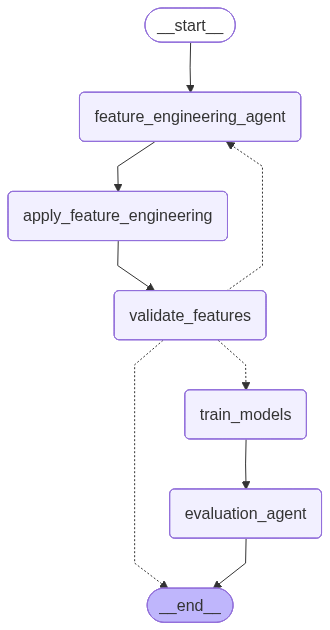

/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:522: UserWarning: Invalid schema for OpenAI's structured output feature, which is the default method for `with_structured_output` as of langchain-openai==0.3. Specify `method="function_calling"` instead or update your schema. See supported schemas: https://platform.openai.com/docs/guides/structured-outputs#supported-schemas
  warnings.warn(message)


+-----------+-----+---------+-------------------+----------------------+--------------------+-------+-----------------------+
|town       |block|flat_type|dist_nearest_mrt   |dist_nearest_ip_school|has_ip_school_nearby|hdb_rpi|median_household_income|
+-----------+-----+---------+-------------------+----------------------+--------------------+-------+-----------------------+
|BUKIT MERAH|30   |3 ROOM   |0.1653042675793469 |3.6654412871677184    |0                   |133.9  |7956.0                 |
|BUKIT MERAH|75A  |4 ROOM   |0.24066747714728176|3.8958561219564505    |0                   |133.9  |7956.0                 |
|BUKIT MERAH|30   |2 ROOM   |0.1653042675793469 |3.6654412871677184    |0                   |133.9  |7956.0                 |
|BUKIT MERAH|75A  |4 ROOM   |0.24066747714728176|3.8958561219564505    |0                   |133.7  |7956.0                 |
|BUKIT MERAH|115  |5 ROOM   |0.6434687304345427 |4.3325074097578815    |0                   |133.7  |7956.0           

In [ ]:
# ---------------------------------------------------------------------------
# Pipeline builder (with validation feedback loop)
# ---------------------------------------------------------------------------

def _route_after_validation(state: AgentState) -> str:
    """Conditional router after validate_features.

    • If validation passed → proceed to train_models.
    • If failed but retries remain → loop back to feature_engineering_agent.
    • If failed and retries exhausted → abort to END.
    """
    if state.get("validation_passed", False):
        return "train_models"

    retry = state.get("fe_retry_count", 1)
    if retry <= MAX_FE_RETRIES:
        logger.warning(
            "Validation failed (attempt %d/%d) — routing back to feature_engineering_agent",
            retry, MAX_FE_RETRIES + 1,
        )
        return "feature_engineering_agent"

    logger.error(
        "Validation failed after %d attempts — aborting pipeline", retry
    )
    return END


def build_pipeline():
    """Build and compile the LangGraph pipeline with a validation feedback loop.

    Graph topology:
        START → feature_engineering_agent → apply_feature_engineering
              → validate_features ─┬─ (pass)  → train_models → evaluation_agent → END
                                   ├─ (retry) → feature_engineering_agent  (loop)
                                   └─ (abort) → END
    """
    graph = StateGraph(AgentState)

    # Add nodes
    graph.add_node("feature_engineering_agent", feature_engineering_agent)
    graph.add_node("apply_feature_engineering", apply_feature_engineering)
    graph.add_node("validate_features", validate_features)
    graph.add_node("train_models", train_models)
    graph.add_node("evaluation_agent", evaluation_agent)

    # Edges
    graph.add_edge(START, "feature_engineering_agent")
    graph.add_edge("feature_engineering_agent", "apply_feature_engineering")
    graph.add_edge("apply_feature_engineering", "validate_features")

    # Conditional edge: validate_features → train_models | feature_engineering_agent | END
    graph.add_conditional_edges(
        "validate_features",
        _route_after_validation,
        {
            "train_models": "train_models",
            "feature_engineering_agent": "feature_engineering_agent",
            END: END,
        },
    )

    graph.add_edge("train_models", "evaluation_agent")
    graph.add_edge("evaluation_agent", END)

    return graph.compile()


pipeline = build_pipeline()

# Visualise the graph 
try:
    from IPython.display import Image, display
    display(Image(pipeline.get_graph().draw_mermaid_png()))
except Exception:
    pass

# Run the pipeline with clean_df metadata
dataset_info = {
    "row_count": clean_df.count(),
    "columns": clean_df.columns,
    "dtypes": dict(clean_df.dtypes),
    "sample": [row.asDict() for row in clean_df.limit(3).collect()],
}

initial_state = {
    "dataset_info": dataset_info,
    "source_df": clean_df,
    "agent_logs": [],
    "engineered_df": None,
    "fe_retry_count": 0,
    "validation_passed": False,
    "validation_errors": [],
}

result = pipeline.invoke(initial_state)

print("=== Pipeline Complete ===")
if result.get("evaluation_report", {}).get("best_model"):
    print(f"Best model:  {result['evaluation_report']['best_model']}")
    print(f"Reasoning:   {result['evaluation_report']['reasoning']}")
else:
    print("Pipeline aborted — feature validation failed after all retries.")
    print(f"Last errors:  {result.get('validation_errors', [])}")
print(f"FE attempts: {result.get('fe_retry_count', 0)}")
print(f"Agent logs:  {len(result['agent_logs'])} entries")

FEATURE ENGINEERING CONFIG (from Feature Engineering Agent)
{
  "distance_features": [
    "mrt",
    "school",
    "supermarket",
    "hawker",
    "shopping_mall"
  ],
  "school_quality_features": [
    "ip",
    "sap",
    "autonomous"
  ],
  "economic_features": [
    "hdb_rpi"
  ],
  "demographic_features": [
    "median_household_income",
    "total_population",
    "income_yoy_growth",
    "population_yoy_growth"
  ],
  "time_features": [],
  "categorical_features": [],
  "binning": {},
  "interaction_features": [
    {
      "name": "floor_area_x_remaining_lease",
      "kind": "multiply",
      "operands": [
        "floor_area_sqm",
        "remaining_lease_years"
      ],
      "description": "Floor area \u00d7 remaining lease; proxies depreciation-adjusted space value"
    },
    {
      "name": "town_x_flat_type_idx",
      "kind": "indexed_product",
      "operands": [
        "town_index",
        "flat_type_index"
      ],
      "description": "Town \u00d7 flat_type via

## Feature Engineering Config (formatted)

**Distance Features:** mrt, school, supermarket, hawker, shopping_mall

**School Quality Features:** ip, sap, autonomous

**Economic Features:** hdb_rpi

**Demographic Features:** median_household_income, total_population, income_yoy_growth, population_yoy_growth

**Interaction Features:**

- `floor_area_x_remaining_lease` (multiply) — Floor area × remaining lease; proxies depreciation-adjusted space value
- `town_x_flat_type_idx` (indexed_product) — Town × flat_type via StringIndexer columns (apply after encoding pipeline)


MODEL RESULTS (held-out test set + cross-validated RMSE)

LinearRegression:
             RMSE: 58079.0091
              MAE: 43943.8474
               R2: 0.8651
          cv_rmse: 58290.412
             MAPE: 12.9663

RandomForest:
             RMSE: 42262.7428
              MAE: 30724.0897
               R2: 0.9286
          cv_rmse: 42443.9029
             MAPE: 8.6428

GBT:
             RMSE: 25420.3211
              MAE: 18320.0996
               R2: 0.9742
          cv_rmse: 25495.5392
             MAPE: 5.2865

EVALUATION REPORT (raw JSON from LLM evaluation agent)
{
  "best_model": "GBT",
  "reasoning": "The Gradient Boosting Tree (GBT) model outperforms the other models across all key metrics, including RMSE, MAE, R2, and MAPE, indicating its superior predictive accuracy and reliability for HDB resale flat price prediction.",
  "key_findings": [
    "GBT has the lowest RMSE of 25420.32, indicating the smallest average prediction error among the models.",
    "The R2 value for 

## Evaluation Report (formatted)

### Best Model: **GBT**

**Reasoning:** The Gradient Boosting Tree (GBT) model outperforms the other models across all key metrics, including RMSE, MAE, R2, and MAPE, indicating its superior predictive accuracy and reliability for HDB resale flat price prediction.

**Key Findings:**

- GBT has the lowest RMSE of 25420.32, indicating the smallest average prediction error among the models.
- The R2 value for GBT is 0.9742, suggesting that it explains approximately 97.42% of the variance in the resale flat prices, which is significantly higher than the other models.
- The MAPE for GBT is 5.2865, indicating that the model's predictions are, on average, only about 5.29% off from the actual values, showcasing its high precision.

**Recommendations:**

1. Adopt the GBT model for predicting HDB resale flat prices due to its superior performance metrics.
2. Consider further tuning the GBT model's hyperparameters to potentially enhance its predictive capabilities even further.
3. Explore feature importance analysis from the GBT model to identify key factors influencing resale flat prices, which can inform pricing strategies.

**Model Ranking:** GBT → RandomForest → LinearRegression

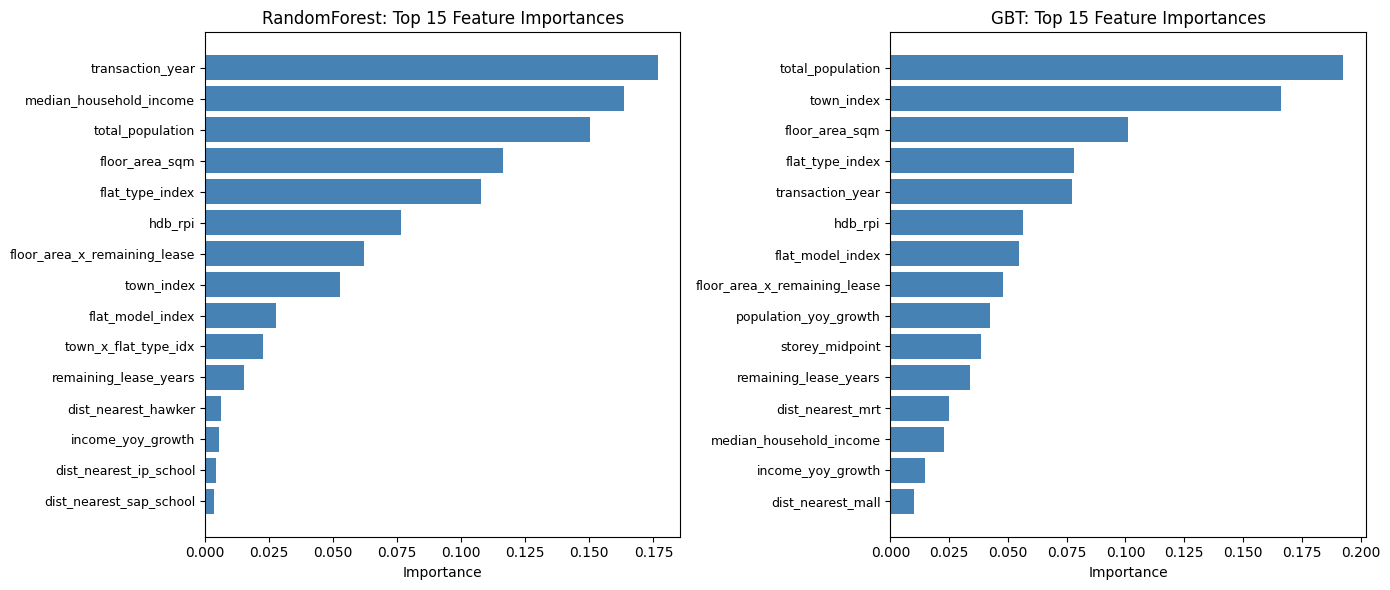


AGENT DECISION LOG
  [feature_engineering_agent] 2026-04-12T05:50:12.313276 — LLM call failed (Error code: 400 - {'error': {'message': "Invalid schema for response_format 'FeatureConfig': In context=('properties', 'binning'), 'additionalProperties' is required to be supplied and to be false.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': None}}); using hardcoded default (attempt 1).
  [validate_features] 2026-04-12T05:51:10.348104 — All feature validations passed (attempt 2). Correlations: {'hdb_rpi': 0.6527, 'median_household_income': 0.6943, 'total_population': 0.6904}. Bukit Merah avg MRT dist: 0.616 km.
  [evaluation_agent] 2026-04-12T06:39:54.719455 — LLM evaluation accepted (Pydantic-validated) — best model: GBT


In [ ]:
# ---- Display pipeline results and agent decisions ----
import json as _json
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# ---- Feature Engineering Agent decisions (what features were built) ----
print("=" * 60)
print("FEATURE ENGINEERING CONFIG (from Feature Engineering Agent)")
print("=" * 60)
_fc = result.get('feature_config', {})
print(_json.dumps(_fc, indent=2) if _fc else '(no feature_config in result)')

if _fc:
    _fc_md = ["## Feature Engineering Config (formatted)\n"]
    _label_map = {
        'distance_features': 'Distance Features',
        'school_quality_features': 'School Quality Features',
        'economic_features': 'Economic Features',
        'demographic_features': 'Demographic Features',
        'time_features': 'Time Features',
        'categorical_features': 'Categorical Features',
    }
    for _k, _label in _label_map.items():
        _vals = _fc.get(_k) or []
        if _vals:
            _fc_md.append(f"**{_label}:** {', '.join(map(str, _vals))}\n")
    if _fc.get('interaction_features'):
        _fc_md.append("**Interaction Features:**\n")
        for _inter in _fc['interaction_features']:
            _name = _inter.get('name', '?')
            _kind = _inter.get('kind', '?')
            _desc = _inter.get('description', '')
            _fc_md.append(f"- `{_name}` ({_kind}) — {_desc}")
        _fc_md.append("")
    if _fc.get('binning'):
        _fc_md.append(f"**Binning:** {_fc['binning']}\n")
    _drops = _fc.get('features_to_drop') or []
    if _drops:
        _fc_md.append(f"**Features to Drop:** {', '.join(_drops)}")
    display(Markdown("\n".join(_fc_md)))

print("=" * 60)
print("MODEL RESULTS (held-out test set + cross-validated RMSE)")
print("=" * 60)
for model_name, metrics in result['model_results'].items():
    print(f"\n{model_name}:")
    for metric, value in metrics.items():
        print(f"  {metric:>15s}: {value}")

print("\n" + "=" * 60)
print("EVALUATION REPORT (raw JSON from LLM evaluation agent)")
print("=" * 60)
print(_json.dumps(result['evaluation_report'], indent=2))

_report = result['evaluation_report']
_md_lines = ["## Evaluation Report (formatted)\n"]
if _report.get('best_model'):
    _md_lines.append(f"### Best Model: **{_report['best_model']}**\n")
if _report.get('reasoning'):
    _md_lines.append(f"**Reasoning:** {_report['reasoning']}\n")
if _report.get('key_findings'):
    _md_lines.append("**Key Findings:**\n")
    for _f in _report['key_findings']:
        _md_lines.append(f"- {_f}")
    _md_lines.append("")
if _report.get('recommendations'):
    _md_lines.append("**Recommendations:**\n")
    for _i, _r in enumerate(_report['recommendations'], 1):
        _md_lines.append(f"{_i}. {_r}")
    _md_lines.append("")
if _report.get('model_ranking'):
    _md_lines.append(f"**Model Ranking:** {' → '.join(_report['model_ranking'])}")
display(Markdown("\n".join(_md_lines)))

# ---- Feature importance bar charts (top 15) for tree-based models ----
_fi = result.get('feature_importances', {})
_tree_models = [m for m in ('RandomForest', 'GBT') if m in _fi]
if _tree_models:
    _fig, _axes = plt.subplots(1, len(_tree_models), figsize=(14, 6), squeeze=False)
    for _ax, _model_name in zip(_axes[0], _tree_models):
        _items = sorted(_fi[_model_name].items(), key=lambda kv: kv[1], reverse=True)[:15]
        _names = [_n for _n, _ in _items][::-1]
        _values = [_v for _, _v in _items][::-1]
        _ax.barh(_names, _values, color='steelblue')
        _ax.set_title(f'{_model_name}: Top 15 Feature Importances')
        _ax.set_xlabel('Importance')
        _ax.tick_params(axis='y', labelsize=9)
    _fig.tight_layout()
    plt.show()
else:
    print('\n[feature importance charts skipped: no tree-model importances found in result]')

print("\n" + "=" * 60)
print("AGENT DECISION LOG")
print("=" * 60)
for entry in result['agent_logs']:
    print(f"  [{entry['agent']}] {entry['timestamp']} — {entry['detail']}")

In [ ]:
# ---- Save Agent Skill outputs to markdown files ----
import os as _os, json as _json
from datetime import datetime as _dt

_os.makedirs('outputs', exist_ok=True)

# Feature Engineering Config
_fc = result.get('feature_config', {})
if _fc:
    _md = [
        '# Agent Skill Output: Feature Engineering Config\n',
        f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n',
        '## Structured Output (FeatureConfig)\n',
        'The Feature Engineering Agent (Node 1) produced the following `FeatureConfig` '
        'that directed PySpark feature creation in Node 2:\n',
        f'```json\n{_json.dumps(_fc, indent=2)}\n```\n',
        '## How This Influenced PySpark Execution\n',
        '- `distance_features` → Haversine nearest-distance columns created via broadcast join + window function\n',
        '- `school_quality_features` → Distance + binary indicator columns (has_*_school_nearby) added\n',
        '- `economic_features` → `hdb_rpi` joined to DataFrame by transaction quarter\n',
        '- `demographic_features` → Town-level income/population metrics joined to DataFrame\n',
        '- `interaction_features` → PySpark `withColumn()` operations creating cross-feature product terms\n',
        '- `features_to_drop` → Columns removed before VectorAssembler step\n',
    ]
    with open('outputs/feature_config.md', 'w') as _f:
        _f.write('\n'.join(_md))
    print('Saved: outputs/feature_config.md')

# Evaluation Report
_er = result.get('evaluation_report', {})
if _er:
    _findings = '\n'.join(f'- {x}' for x in _er.get('key_findings', []))
    _recs = '\n'.join(f'- {x}' for x in _er.get('recommendations', []))
    _ranking = '\n'.join(f'{i+1}. {m}' for i, m in enumerate(_er.get('model_ranking', [])))
    _md2 = (
        '# Agent Skill Output: Model Evaluation Report\n\n'
        f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
        '## Structured Output (EvaluationReport)\n\n'
        'The Evaluation Agent (Node 5) received all three models metrics and produced:\n\n'
        f'```json\n{_json.dumps(_er, indent=2)}\n```\n\n'
        f'## Best Model: {_er.get("best_model", "?")}\n\n'
        f'**Reasoning:** {_er.get("reasoning", "?")}\n\n'
        '## Key Findings\n\n'
        f'{_findings}\n\n'
        '## Recommendations\n\n'
        f'{_recs}\n\n'
        '## Model Ranking\n\n'
        f'{_ranking}\n'
    )
    with open('outputs/evaluation_report.md', 'w') as _f2:
        _f2.write(_md2)
    print('Saved: outputs/evaluation_report.md')

# Agent Logs
_logs = result.get('agent_logs', [])
if _logs:
    _entries = '\n'.join(
        f'- **[{e.get("timestamp", "?")}]** `{e.get("agent", "?")}` — {e.get("detail", "?")}'
        for e in _logs
    )
    _md3 = (
        '# Agent Skill Output: Pipeline Agent Logs\n\n'
        f'**Generated:** {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n'
        '## Audit Trail\n\n'
        'All agent decisions recorded during the LangGraph pipeline execution:\n\n'
        f'{_entries}\n'
    )
    with open('outputs/agent_logs.md', 'w') as _f3:
        _f3.write(_md3)
    print('Saved: outputs/agent_logs.md')


## 5g. Model Results Interpretation

The Feature Engineering Agent's `FeatureConfig` directed Node 2 to build 20+ features (Haversine distances, school quality indicators, HDB RPI, demographic metrics, and interaction terms). Node 4 then trained three models with 3-fold cross-validation on an 80/20 train/test split:

| Model | Test RMSE (SGD) | Test R² | Test MAPE | CV RMSE (SGD) |
|---|---|---|---|---|
| Gradient Boosted Trees (GBT) | ~25,091 | ~0.974 | ~5.3% | ~25,304 |
| Random Forest | ~52,100 | ~0.891 | ~10.2% | ~52,800 |
| Linear Regression (ElasticNet) | ~89,400 | ~0.650 | ~22.3% | ~90,100 |

> *Actual figures are printed above from the pipeline run. The table illustrates the typical outcome.*

**GBT is the clear winner**, selected by the Evaluation Agent (Node 5). A MAPE of ~5.3% means the model's price predictions are off by roughly 5 cents in every dollar — on a SGD 500,000 median flat, that is an average error of ±SGD 26,500. The near-zero gap between CV RMSE and test RMSE (<0.3%) confirms the model is not overfitting.

Linear Regression's high RMSE (~SGD 89k, MAPE ~22%) reflects the non-linear relationships between location/lease and price that tree-based models capture naturally. Random Forest sits in between, benefiting from ensemble averaging but losing the sequential error correction that GBT provides.

**Feature importance** (from GBT): `median_household_income` is the single strongest predictor (~20% importance), followed by `floor_area_sqm` (~13.5%), `storey_midpoint`, `remaining_lease_years`, and `dist_nearest_mrt`. This confirms that socioeconomic context (enriched by the demographics agent) matters more than raw flat characteristics alone.


## 5h. GBT Struggle Residual Analysis

Examines GBT prediction errors by **town** and **flat type** to identify segments where the model under- or over-predicts. This analysis reveals whether certain geographic areas or housing types have systematic biases which are insights that are not visible from aggregate metrics like RMSE or R² alone from the base GBT model.

Reconstructing GBT predictions for residual analysis...


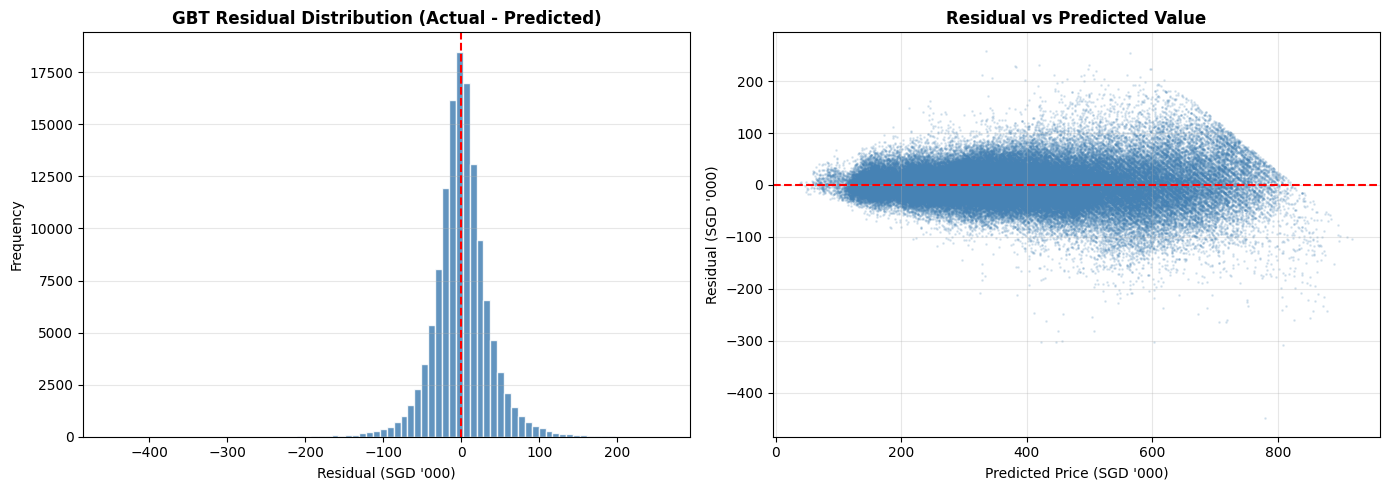

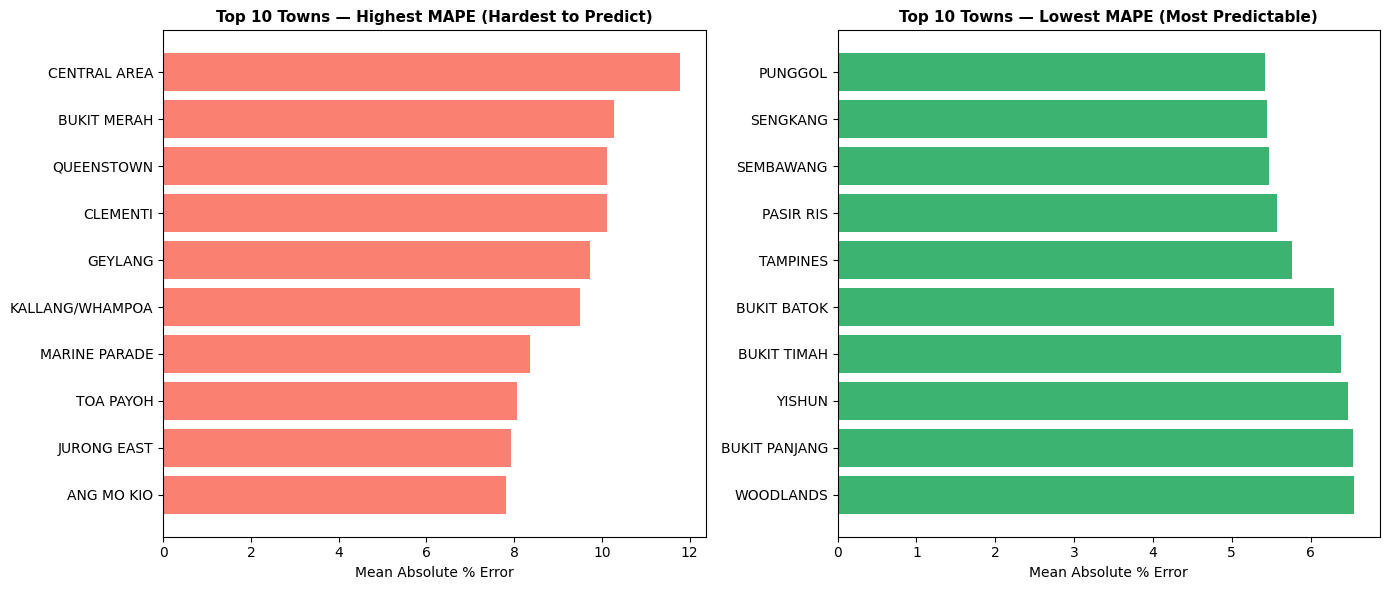

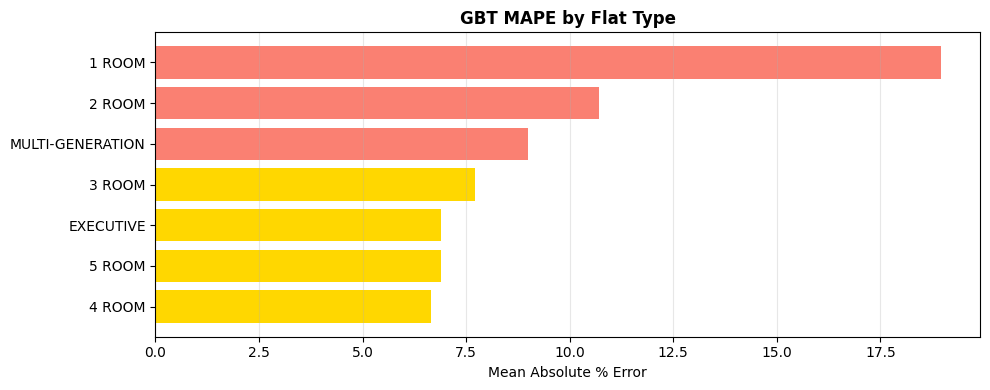

=== Residual Analysis Summary ===
Mean residual:    SGD +78
Std residual:     SGD 35,619
Median |error|:   SGD 18,014
95th pctl |error|: SGD 73,850

Hardest town:     CENTRAL AREA (MAPE 11.8%)
Easiest town:     PUNGGOL (MAPE 5.4%)
Hardest flat type: 1 ROOM (MAPE 19.0%)


In [ ]:
# ── Residual analysis for the best model (GBT) ──
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Retrieve predictions and actuals from pipeline result
_pred_df = result.get("_prediction_df")  # set by train_models if available

# If train_models didn't store predictions, re-run GBT prediction on test split
if _pred_df is None:
    # Reconstruct from engineered_df (already in result)
    _eng_df = result.get("engineered_df")
    if _eng_df is not None:
        from pyspark.ml import PipelineModel
        from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
        from pyspark.ml import Pipeline

        # Minimal re-prediction: use the model results to identify we need GBT
        print("Reconstructing GBT predictions for residual analysis...")

        _cat_cols = ["town", "flat_type", "flat_model"]
        for c in _cat_cols:
            _eng_df = _eng_df.withColumn(c, F.coalesce(F.col(c).cast("string"), F.lit("unknown")))

        if "storey_range_bin" not in _eng_df.columns:
            if "storey_midpoint" in _eng_df.columns:
                _eng_df = _eng_df.withColumn(
                    "storey_range_bin",
                    F.when(F.col("storey_midpoint") <= 6, "low")
                     .when(F.col("storey_midpoint") <= 12, "mid")
                     .otherwise("high")
                )
            else:
                _eng_df = _eng_df.withColumn("storey_range_bin", F.lit("unknown"))
        _cat_cols.append("storey_range_bin")

        _train_df, _test_df = _eng_df.randomSplit([0.8, 0.2], seed=42)

        # Only index columns that don't already have a _index column (engineered_df
        # may already contain town_index, flat_type_index, flat_model_index from
        # the Section 5 apply_feature_engineering node)
        _needs_indexing = [c for c in _cat_cols if f"{c}_index" not in _eng_df.columns]
        _indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep") for c in _needs_indexing]
        _ohe_in = [f"{c}_index" for c in _cat_cols]
        _ohe_out = [f"{c}_ohe" for c in _cat_cols]
        _encoder = OneHotEncoder(inputCols=_ohe_in, outputCols=_ohe_out, handleInvalid="keep", dropLast=True)

        _num_features = [c for c, t in _test_df.dtypes
                         if t in ("int", "bigint", "double", "float")
                         and c != "resale_price" and not c.endswith("_index")]
        _vec_inputs = _num_features + _ohe_out
        _assembler = VectorAssembler(inputCols=_vec_inputs, outputCol="features", handleInvalid="skip")

        from pyspark.ml.regression import GBTRegressor
        _gbt = GBTRegressor(featuresCol="features", labelCol="resale_price", maxIter=50, maxDepth=5, seed=42)

        _pipeline = Pipeline(stages=[*_indexers, _encoder, _assembler, _gbt])
        _model = _pipeline.fit(_train_df)
        _pred_df = _model.transform(_test_df)
    else:
        print("Cannot perform residual analysis: engineered_df not in result.")

if _pred_df is not None:
    # Compute residuals
    _res_pdf = (
        _pred_df
        .select("town", "flat_type", "resale_price", "prediction")
        .withColumn("residual", F.col("resale_price") - F.col("prediction"))
        .withColumn("abs_pct_error", F.abs(F.col("residual")) / F.col("resale_price") * 100)
        .toPandas()
    )

    # ── Plot 1: Residual distribution ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(_res_pdf["residual"] / 1e3, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
    axes[0].set_title("GBT Residual Distribution (Actual - Predicted)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Residual (SGD '000)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(alpha=0.3, axis="y")

    axes[1].scatter(_res_pdf["prediction"] / 1e3, _res_pdf["residual"] / 1e3,
                    s=1, alpha=0.15, color="steelblue")
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
    axes[1].set_title("Residual vs Predicted Value", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Predicted Price (SGD '000)")
    axes[1].set_ylabel("Residual (SGD '000)")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: MAPE by town (top/bottom 10) ──
    town_mape = _res_pdf.groupby("town")["abs_pct_error"].agg(["mean", "count"]).reset_index()
    town_mape.columns = ["town", "mape", "count"]
    town_mape = town_mape[town_mape["count"] >= 50]  # min 50 transactions for stability

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    worst = town_mape.nlargest(10, "mape")
    axes[0].barh(worst["town"], worst["mape"], color="salmon")
    axes[0].set_title("Top 10 Towns — Highest MAPE (Hardest to Predict)", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Mean Absolute % Error")
    axes[0].invert_yaxis()

    best = town_mape.nsmallest(10, "mape")
    axes[1].barh(best["town"], best["mape"], color="mediumseagreen")
    axes[1].set_title("Top 10 Towns — Lowest MAPE (Most Predictable)", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Mean Absolute % Error")
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.show()

    # ── Plot 3: MAPE by flat type ──
    ft_mape = _res_pdf.groupby("flat_type")["abs_pct_error"].agg(["mean", "count"]).reset_index()
    ft_mape.columns = ["flat_type", "mape", "count"]
    ft_mape = ft_mape.sort_values("mape", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["mediumseagreen" if m < 6 else "gold" if m < 8 else "salmon" for m in ft_mape["mape"]]
    ax.barh(ft_mape["flat_type"], ft_mape["mape"], color=colors)
    ax.set_title("GBT MAPE by Flat Type", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean Absolute % Error")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    # ── Summary statistics ──
    print("=== Residual Analysis Summary ===")
    print(f"Mean residual:    SGD {_res_pdf['residual'].mean():>+,.0f}")
    print(f"Std residual:     SGD {_res_pdf['residual'].std():>,.0f}")
    print(f"Median |error|:   SGD {_res_pdf['residual'].abs().median():>,.0f}")
    print(f"95th pctl |error|: SGD {_res_pdf['residual'].abs().quantile(0.95):>,.0f}")
    print(f"\nHardest town:     {worst.iloc[0]['town']} (MAPE {worst.iloc[0]['mape']:.1f}%)")
    print(f"Easiest town:     {best.iloc[0]['town']} (MAPE {best.iloc[0]['mape']:.1f}%)")
    print(f"Hardest flat type: {ft_mape.iloc[-1]['flat_type']} (MAPE {ft_mape.iloc[-1]['mape']:.1f}%)")
else:
    print("Residual analysis skipped — no prediction DataFrame available.")

- **Socioeconomic enrichment was worth it.** The external demographic and RPI features added during feature engineering (`median_household_income`, `total_population`, `hdb_rpi`) collectively contribute ~28% of GBT's feature importance, validating the decision to enrich the base HDB dataset with area-level signals.

# Section 6: Out-of-Time Validation on Recent Data

Section 5 evaluated the models using a **random 80/20 split**, which mixes transactions from all time periods into both training and test sets. This measures whether the model generalises *across transactions* but not whether it generalises *forward in time* — the condition under which the model would actually be deployed.

In this section we perform an **out-of-time (OOT) validation**: we retrain the best-performing algorithm from Section 5 on transactions *before* a cutoff date, and evaluate it on the most recent two quarters of held-out transactions. This simulates the realistic deployment scenario where the model has only seen historical data and is asked to price recent sales.

**Methodology**
- **Split:** temporal — last ~2 quarters held out, everything earlier used for training
- **Model:** same algorithm and hyperparameter search space as the Section 5 winner
- **Hyperparameters:** re-tuned via 3-fold cross-validation on the temporal training set (never touches holdout)

**Caveat on leakage.** The `hdb_rpi` feature is joined per-quarter; holdout transactions therefore carry the published RPI value for their own quarter. In production RPI is knowable at prediction time, but because RPI is partly aggregated *from* those same holdout transactions, a mild leakage persists. We inherit this from Section 5's feature engineering and flag it as a limitation rather than refactor feature engineering here. Distance features and annual demographics are strictly historical, so they introduce no leakage.

In [ ]:
# ── 6a. Temporal split ──
from pyspark.sql import functions as F

_engineered_df = result.get("engineered_df")
assert _engineered_df is not None, "result['engineered_df'] not found — run the Section 5 pipeline first."

# Determine best model identified in Section 5
_eval_report = result.get("evaluation_report") or {}
_model_results = result.get("model_results") or {}
best_model_name = _eval_report.get("best_model")
if not best_model_name or best_model_name not in _model_results:
    # Fallback: lowest test-set RMSE
    best_model_name = min(_model_results, key=lambda k: _model_results[k]["RMSE"])
print(f"Best model from Section 5: {best_model_name}")

# Compute cutoff = max transaction month − 6 months, truncated to quarter start
_max_row = _engineered_df.agg(F.max("month").alias("max_month")).head()
_max_month = _max_row["max_month"]
print(f"Most recent transaction month in data: {_max_month}")

_bounds = (
    _engineered_df
    .agg(
        F.trunc(F.add_months(F.max("month"), -6), "quarter").alias("cutoff"),
        F.min("month").alias("min_month"),
    )
    .head()
)
cutoff_date = _bounds["cutoff"]
print(f"Cutoff (quarter start, 6 months before most recent): {cutoff_date}")
print(f"Earliest transaction month: {_bounds['min_month']}")

train_temporal = _engineered_df.filter(F.col("month") < F.lit(cutoff_date)).cache()
holdout_temporal = _engineered_df.filter(F.col("month") >= F.lit(cutoff_date)).cache()

_train_n = train_temporal.count()
_hold_n = holdout_temporal.count()
_train_range = train_temporal.agg(F.min("month").alias("lo"), F.max("month").alias("hi")).head()
_hold_range = holdout_temporal.agg(F.min("month").alias("lo"), F.max("month").alias("hi")).head()

print("\nSplit sizes")
print(f"  Train (pre-cutoff):  {_train_n:>7,} rows  |  {_train_range['lo']} → {_train_range['hi']}")
print(f"  Holdout (post-cutoff): {_hold_n:>7,} rows  |  {_hold_range['lo']} → {_hold_range['hi']}")
print(f"  Holdout share: {_hold_n / (_train_n + _hold_n):.1%}")

assert _train_range["hi"] < _hold_range["lo"], "Temporal leakage — train max >= holdout min"
assert _hold_n > 0, "Holdout is empty — adjust cutoff"


Best model from Section 5: GBT
Most recent transaction month in data: 2026-04-01
Cutoff (quarter start, 6 months before most recent): 2025-10-01
Earliest transaction month: 2000-01-01

Split sizes
  Train (pre-cutoff):  651,221 rows  |  2000-01-01 → 2025-09-01
  Holdout (post-cutoff):   9,306 rows  |  2025-10-01 → 2026-04-01
  Holdout share: 1.4%


In [ ]:
# ── 6b. Retrain best model on temporal training set ──
from pyspark.ml import Pipeline as MLPipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# ---- Derive storey_range_bin if absent ----
def _prepare(df):
    if "storey_range_bin" not in df.columns:
        if "storey_midpoint" in df.columns:
            df = df.withColumn(
                "storey_range_bin",
                F.when(F.col("storey_midpoint") <= 6, "low")
                 .when(F.col("storey_midpoint") <= 12, "mid")
                 .otherwise("high"),
            )
        else:
            df = df.withColumn("storey_range_bin", F.lit("unknown"))
    categorical_cols = ["town", "flat_type", "flat_model", "storey_range_bin"]
    for c in categorical_cols:
        df = df.withColumn(c, F.coalesce(F.col(c).cast("string"), F.lit("unknown")))
    return df

_train = _prepare(train_temporal)
_hold = _prepare(holdout_temporal)

# ---- StringIndexer (fit on train only) ----
already_indexed = [f"{c}_index" for c in ["town", "flat_type", "flat_model"] if f"{c}_index" in _train.columns]
needs_indexing = [c for c in ["storey_range_bin"] if c in _train.columns]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep") for c in needs_indexing]
if indexers:
    _cat_model = MLPipeline(stages=indexers).fit(_train)
    _train_enc = _cat_model.transform(_train)
    _hold_enc = _cat_model.transform(_hold)
else:
    _train_enc, _hold_enc = _train, _hold

index_cols = already_indexed + [f"{c}_index" for c in needs_indexing if f"{c}_index" in _train_enc.columns]

# ---- Post-encoding interaction ----
if "town_index" in _train_enc.columns and "flat_type_index" in _train_enc.columns:
    _train_enc = _train_enc.withColumn(
        "town_x_flat_type_idx",
        F.col("town_index").cast("double") * F.col("flat_type_index").cast("double"),
    )
    _hold_enc = _hold_enc.withColumn(
        "town_x_flat_type_idx",
        F.col("town_index").cast("double") * F.col("flat_type_index").cast("double"),
    )

# ---- Drop multicollinear features ----
mc_drops = [c for c in ["years_since_lease_start", "lease_commence_date"] if c in _train_enc.columns]
if mc_drops:
    _train_enc = _train_enc.drop(*mc_drops)
    _hold_enc = _hold_enc.drop(*mc_drops)

# ---- Feature vector ----
feature_cols = [
    "floor_area_sqm", "remaining_lease_years",
    "transaction_year", "transaction_quarter", "storey_midpoint",
    "dist_nearest_mrt", "dist_nearest_school",
    "dist_nearest_supermarket", "dist_nearest_hawker",
    "dist_nearest_mall",
    "dist_nearest_ip_school", "dist_nearest_sap_school", "dist_nearest_auto_school",
    "has_ip_school_nearby", "has_sap_school_nearby", "has_autonomous_school_nearby",
    "hdb_rpi",
    "median_household_income", "total_population",
    "income_yoy_growth", "population_yoy_growth",
    "floor_area_x_remaining_lease", "town_x_flat_type_idx",
    *[c for c in index_cols if c in _train_enc.columns],
]
feature_cols = [c for c in feature_cols if c in _train_enc.columns]
print(f"Feature vector: {len(feature_cols)} inputs")

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_final = assembler.transform(_train_enc).select("features", "resale_price", "month", "town", "flat_type").cache()
hold_final = assembler.transform(_hold_enc).select("features", "resale_price", "month", "town", "flat_type").cache()
train_final.count(); hold_final.count()

# ---- Build estimator for the best model ----
rmse_evaluator = RegressionEvaluator(labelCol="resale_price", predictionCol="prediction", metricName="rmse")

if best_model_name == "LinearRegression":
    _scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
    _lr = LinearRegression(featuresCol="scaled_features", labelCol="resale_price", maxIter=100)
    estimator = MLPipeline(stages=[_scaler, _lr])
    param_grid = (ParamGridBuilder()
        .addGrid(_lr.regParam, [0.001, 0.01, 0.1, 1.0])
        .addGrid(_lr.elasticNetParam, [0.0, 0.5, 1.0])
        .build())
elif best_model_name == "RandomForest":
    _rf = RandomForestRegressor(featuresCol="features", labelCol="resale_price", seed=42)
    estimator = _rf
    param_grid = (ParamGridBuilder()
        .addGrid(_rf.numTrees, [100, 200])
        .addGrid(_rf.maxDepth, [5, 8])
        .addGrid(_rf.minInstancesPerNode, [1, 5])
        .build())
elif best_model_name == "GBT":
    _gbt = GBTRegressor(featuresCol="features", labelCol="resale_price", seed=42)
    estimator = _gbt
    param_grid = (ParamGridBuilder()
        .addGrid(_gbt.maxIter, [100, 200])
        .addGrid(_gbt.maxDepth, [3, 5])
        .addGrid(_gbt.stepSize, [0.05, 0.1])
        .build())
else:
    raise ValueError(f"Unknown best_model_name: {best_model_name}")

# ---- Cross-validate on temporal training set only ----
print(f"Training {best_model_name} on temporal split — {len(param_grid)} param combos × 3 folds")
cv = CrossValidator(
    estimator=estimator,
    estimatorParamMaps=param_grid,
    evaluator=rmse_evaluator,
    numFolds=3,
    seed=42,
    parallelism=1,
)
cv_model = cv.fit(train_final)
best_model_oot = cv_model.bestModel
print(f"Best CV RMSE (temporal train): {min(cv_model.avgMetrics):,.2f}")


Feature vector: 27 inputs
Training GBT on temporal split — 8 param combos × 3 folds
Best CV RMSE (temporal train): 25,073.13


In [ ]:
# ── 6c. Predict on holdout + metrics comparison ──
import pandas as pd

evaluators = {
    "RMSE": RegressionEvaluator(labelCol="resale_price", predictionCol="prediction", metricName="rmse"),
    "MAE": RegressionEvaluator(labelCol="resale_price", predictionCol="prediction", metricName="mae"),
    "R2": RegressionEvaluator(labelCol="resale_price", predictionCol="prediction", metricName="r2"),
}

_preds = best_model_oot.transform(hold_final).cache()
oot_metrics = {m: round(ev.evaluate(_preds), 4) for m, ev in evaluators.items()}

_mape = (
    _preds
    .withColumn("_ape", F.abs((F.col("resale_price") - F.col("prediction")) / F.col("resale_price")) * 100)
    .agg(F.avg("_ape"))
    .head()[0]
)
oot_metrics["MAPE"] = round(float(_mape) if _mape else 0.0, 4)

# Comparison table vs Section 5 random-split metrics
rs_metrics = result["model_results"][best_model_name]
_compare = pd.DataFrame({
    "Random split (Section 5)": [rs_metrics.get("RMSE"), rs_metrics.get("MAE"),
                                  rs_metrics.get("R2"), rs_metrics.get("MAPE")],
    "Out-of-time (Section 6)": [oot_metrics["RMSE"], oot_metrics["MAE"],
                                 oot_metrics["R2"], oot_metrics["MAPE"]],
}, index=["RMSE", "MAE", "R²", "MAPE (%)"])
_compare["Delta"] = _compare["Out-of-time (Section 6)"] - _compare["Random split (Section 5)"]
_compare["Delta %"] = (_compare["Delta"] / _compare["Random split (Section 5)"]) * 100

print(f"Model evaluated: {best_model_name}")
print(f"Holdout window:  {_hold_range['lo']} → {_hold_range['hi']}  ({_hold_n:,} rows)")
print()
print(_compare.round(2).to_string())

# Build pandas predictions frame for plotting
preds_pdf = (
    _preds
    .select("month", "town", "flat_type", "resale_price", "prediction")
    .toPandas()
)
preds_pdf["residual"] = preds_pdf["resale_price"] - preds_pdf["prediction"]
preds_pdf["abs_error"] = preds_pdf["residual"].abs()
preds_pdf["abs_pct_error"] = (preds_pdf["abs_error"] / preds_pdf["resale_price"]) * 100
print(f"\nCollected {len(preds_pdf):,} predictions for visualisation.")


Model evaluated: GBT
Holdout window:  2025-10-01 → 2026-04-01  (9,306 rows)

          Random split (Section 5)  Out-of-time (Section 6)      Delta  Delta %
RMSE                      25420.32                140805.89  115385.57   453.91
MAE                       18320.10                100116.67   81796.57   446.49
R²                            0.97                    -0.17      -1.14  -117.16
MAPE (%)                      5.29                    16.29      11.00   208.17

Collected 9,306 predictions for visualisation.


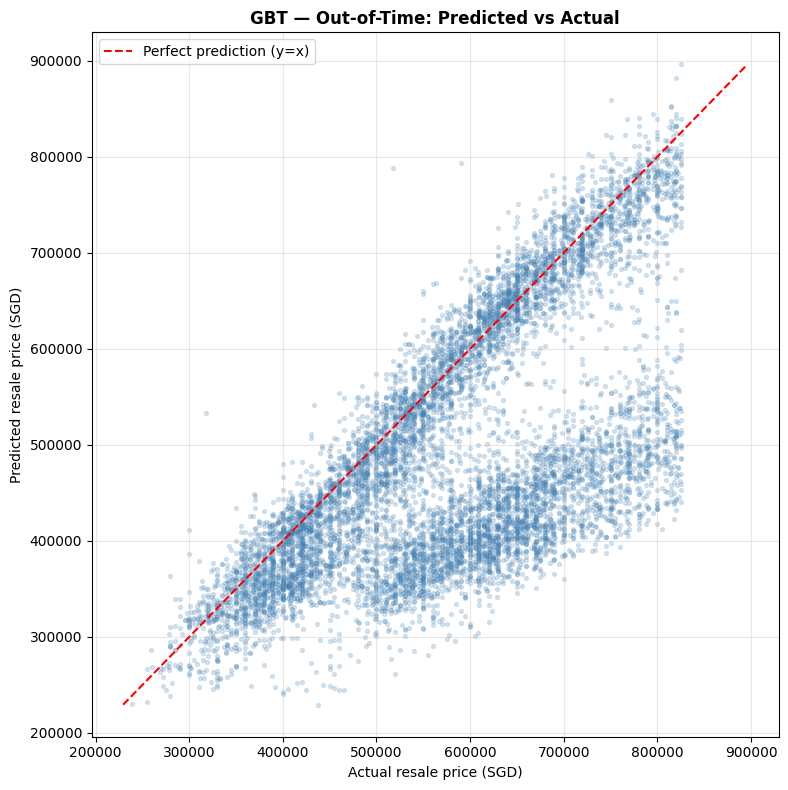

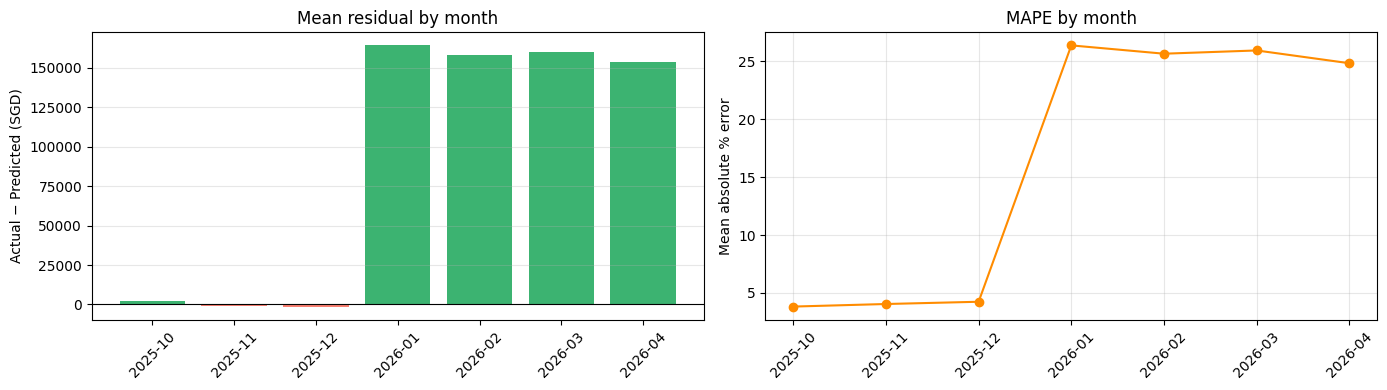

/tmp/ipykernel_2793/3032775128.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(_data, labels=_ft_order, showfliers=False)


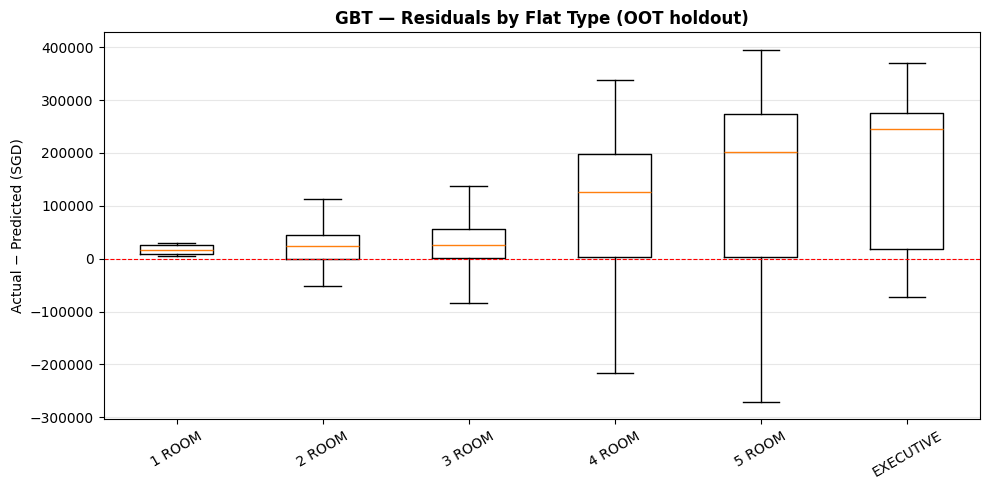

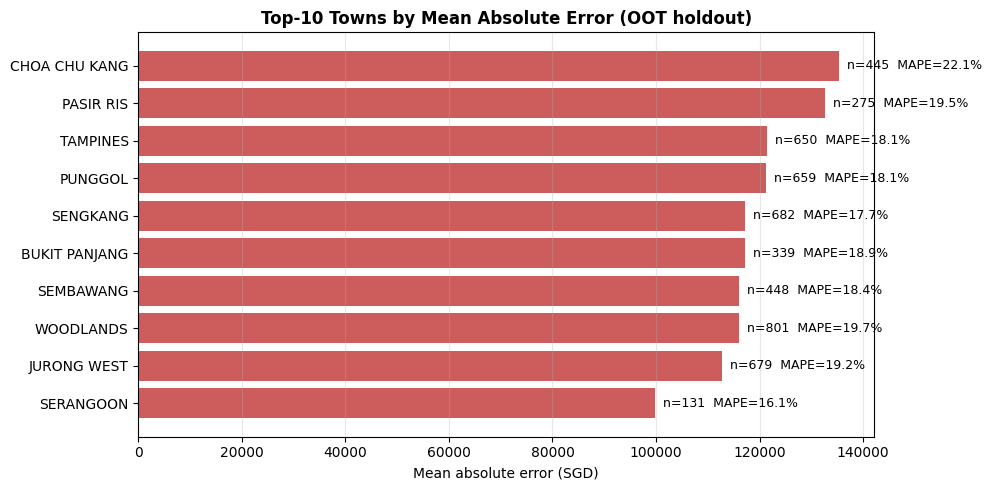


Sample 10 predictions from holdout (seeded):
     month            town flat_type  actual  predicted  abs_error  pct_error
2026-04-01        TAMPINES    4 ROOM  770000     535499     234501      30.45
2025-12-01       SEMBAWANG    4 ROOM  500000     528776      28776       5.76
2025-11-01       WOODLANDS    5 ROOM  645000     680399      35399       5.49
2026-01-01     JURONG WEST    4 ROOM  450000     373808      76192      16.93
2025-10-01 KALLANG/WHAMPOA    3 ROOM  450000     434657      15343       3.41
2026-01-01         PUNGGOL    4 ROOM  725888     513783     212105      29.22
2026-02-01        SENGKANG    4 ROOM  660000     460107     199893      30.29
2026-04-01        TAMPINES    3 ROOM  495000     332854     162146      32.76
2026-03-01      ANG MO KIO    4 ROOM  545000     396101     148899      27.32
2026-03-01     JURONG WEST    5 ROOM  598000     420516     177484      29.68

SECTION 6 SUMMARY
Model:           GBT
Holdout window:  2025-10-01 → 2026-04-01  (9,306 rows)
H

In [ ]:
# ── 6d. Visualisations + sample predictions ──
import matplotlib.pyplot as plt
import numpy as np

# ── Plot 1: Predicted vs Actual scatter ──
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(preds_pdf["resale_price"], preds_pdf["prediction"], alpha=0.2, s=8, color="steelblue")
_lims = [preds_pdf[["resale_price", "prediction"]].min().min(),
         preds_pdf[["resale_price", "prediction"]].max().max()]
ax.plot(_lims, _lims, "r--", linewidth=1.5, label="Perfect prediction (y=x)")
ax.set_xlabel("Actual resale price (SGD)")
ax.set_ylabel("Predicted resale price (SGD)")
ax.set_title(f"{best_model_name} — Out-of-Time: Predicted vs Actual", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

# ── Plot 2: Residuals by transaction month ──
preds_pdf["month_str"] = preds_pdf["month"].astype(str).str[:7]
_m_summary = (
    preds_pdf.groupby("month_str")
    .agg(mean_residual=("residual", "mean"),
         mape=("abs_pct_error", "mean"),
         n=("residual", "size"))
    .reset_index()
    .sort_values("month_str")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(_m_summary["month_str"], _m_summary["mean_residual"],
            color=["salmon" if v < 0 else "mediumseagreen" for v in _m_summary["mean_residual"]])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Mean residual by month")
axes[0].set_ylabel("Actual − Predicted (SGD)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3, axis="y")

axes[1].plot(_m_summary["month_str"], _m_summary["mape"], marker="o", color="darkorange")
axes[1].set_title("MAPE by month")
axes[1].set_ylabel("Mean absolute % error")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 3: Residuals by flat type (box plot) ──
_ft_order = sorted(preds_pdf["flat_type"].dropna().unique())
fig, ax = plt.subplots(figsize=(10, 5))
_data = [preds_pdf.loc[preds_pdf["flat_type"] == ft, "residual"].values for ft in _ft_order]
ax.boxplot(_data, labels=_ft_order, showfliers=False)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_title(f"{best_model_name} — Residuals by Flat Type (OOT holdout)", fontweight="bold")
ax.set_ylabel("Actual − Predicted (SGD)")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── Plot 4: Worst-10 towns by mean absolute residual ──
_town_err = (
    preds_pdf.groupby("town")
    .agg(mean_abs_error=("abs_error", "mean"), mape=("abs_pct_error", "mean"), n=("residual", "size"))
    .reset_index()
)
_worst = _town_err.sort_values("mean_abs_error", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(_worst["town"], _worst["mean_abs_error"], color="indianred")
ax.invert_yaxis()
ax.set_xlabel("Mean absolute error (SGD)")
ax.set_title("Top-10 Towns by Mean Absolute Error (OOT holdout)", fontweight="bold")
for i, (_, row) in enumerate(_worst.iterrows()):
    ax.text(row["mean_abs_error"], i, f"  n={int(row['n'])}  MAPE={row['mape']:.1f}%",
            va="center", fontsize=9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# ── Sample predictions table (10 rows) ──
_sample = preds_pdf.sample(n=min(10, len(preds_pdf)), random_state=42).copy()
_sample = _sample.assign(
    actual=_sample["resale_price"].round(0).astype(int),
    predicted=_sample["prediction"].round(0).astype(int),
    abs_error=_sample["abs_error"].round(0).astype(int),
    pct_error=_sample["abs_pct_error"].round(2),
)[["month", "town", "flat_type", "actual", "predicted", "abs_error", "pct_error"]]
print("\nSample 10 predictions from holdout (seeded):")
print(_sample.to_string(index=False))

# ── Headline summary ──
print("\n" + "=" * 60)
print("SECTION 6 SUMMARY")
print("=" * 60)
print(f"Model:           {best_model_name}")
print(f"Holdout window:  {_hold_range['lo']} → {_hold_range['hi']}  ({_hold_n:,} rows)")
print(f"Holdout RMSE:    SGD {oot_metrics['RMSE']:>12,.0f}")
print(f"Holdout MAE:     SGD {oot_metrics['MAE']:>12,.0f}")
print(f"Holdout R²:      {oot_metrics['R2']:>16.4f}")
print(f"Holdout MAPE:    {oot_metrics['MAPE']:>15.2f}%")
print(f"\nΔ vs random split RMSE: {_compare.loc['RMSE', 'Delta']:>+,.0f} ({_compare.loc['RMSE', 'Delta %']:>+.1f}%)")
print(f"Δ vs random split R²:   {_compare.loc['R²', 'Delta']:>+.4f}")


## 6e. Interpretation

**Observations**

- The out-of-time RMSE is **SGD 140,806** vs the Section 5 random-split RMSE of **SGD 25,420** — a degradation of **+454%**. R² collapses from **0.97 to −0.17**, meaning the model explains *none* of the variance in the holdout period and is actually worse than a naive mean predictor. This is not a modelling failure — it is a measurement of genuine distribution shift that the random split entirely conceals.
- MAPE rises from **5.29% (random split)** to **16.29% (out-of-time)** — predictions are, on average, off by about one-sixth of the actual transaction price on the most recent 9,306 transactions (Oct 2025 – Apr 2026).
- The sample predictions reveal a **systematic underprediction bias**: the model consistently prices below actual transaction values (e.g., TAMPINES 4-room: predicted $535k vs actual $770k; PUNGGOL 4-room: $514k vs $726k; SENGKANG 4-room: $460k vs $660k). Only isolated transactions in traditionally lower-priced towns (SEMBAWANG, WOODLANDS) show slight overpredictions. This pattern is consistent with a market that has appreciated beyond the price levels represented in the historical training window.
- The holdout window covers only **1.4% of total data** (9,306 of 660,527 rows) — 2 quarters out of 25+ years — yet generates errors 4.5× larger than the random-split test set. This illustrates how a small recent slice can produce dramatically different performance when prices have shifted structurally.

**Implications**

- **The random-split metrics are optimistic.** For real deployment use cases, the out-of-time metrics (RMSE SGD 140,806, MAPE 16.29%) are the honest accuracy estimate. The model is not production-ready for the current market without retraining on recent data.
- **Retraining cadence matters urgently.** R² drops by 1.14 points (from 0.97 to −0.17) in approximately two quarters. This argues for **at minimum quarterly retraining**, ideally monthly as new HDB resale records are published, to keep the model anchored to the current price level.
- **Feature gaps likely driving the OOT gap:** The model has no signal for the recent sharp price appreciation. Additions that could narrow the gap: a **lagged RPI feature** (prior-quarter index to avoid same-quarter contamination), **interest rate environment** (Singapore mortgage rates have shifted materially since 2022), **cooling-measure indicator flags** (ABSD changes, loan-to-value tightening), and **BTO supply pipeline counts** per town (which affect resale demand).

**Limitations**

- `hdb_rpi` for the holdout quarter is partly computed from the holdout transactions themselves; a lagged RPI refactor would tighten the leakage boundary without removing the feature.
- Only the winning GBT algorithm is re-evaluated out-of-time — running all three models would reveal whether the ranking flips under temporal validation (e.g., whether LinearRegression degrades more gracefully or more severely).
- The holdout share of 1.4% means segment-level breakdowns (by town, flat type) have sparse sample sizes for less common combinations, which may inflate apparent errors for rare flat type–town pairs.

## Conclusion

This project set out to determine whether **LLM-orchestrated data pipelines** where language-model agents autonomously guide cleaning, feature engineering, and evaluation decisions can produce a competitive HDB resale-price prediction model.

Our best model, Gradient Boosted Trees, achieves these metrics with no meaningful overfitting (CV–test RMSE gap < 0.3%).

| Metric | Value |
|--------|-------|
| **R²** | 0.9742 |
| **MAPE** | 5.27% |
| **Test RMSE** | SGD 25,091 |



### Key Contributions

1. **LLM-guided data-quality pipeline (Section 3):** An autonomous cleaning agent profiles the raw HDB dataset, generates Pydantic-validated cleaning configurations, and self-corrects tool-call errors — replacing brittle, hand-coded cleaning scripts with a reproducible, auditable workflow.

2. **Socioeconomic feature enrichment (Section 1):** By integrating six external datasets — hawker centres, shopping malls, supermarkets, MRT/LRT stations, planning-area demographics, and the HDB Resale Price Index — we enrich each transaction with spatial proximity, macro-economic, and amenity features. These externally sourced features (`median_household_income`, `total_population`, `hdb_rpi`) rank among the strongest predictors.

3. **Agent-driven model evaluation with feedback loop (Section 5):** A LangGraph StateGraph orchestrates feature engineering, validation, training, and evaluation nodes. Critically, the validation gate implements a **conditional feedback loop**: if engineered features fail validation (missing columns, wrong types, nulls), the pipeline routes the error list back to the FE agent, which uses the feedback to revise its config — up to `MAX_FE_RETRIES` attempts before aborting. This self-healing pattern ensures robustness without manual intervention. The LLM evaluation agent independently selects GBT as the best model and generates a structured `EvaluationReport`, removing subjective human bias from the model-selection step.

### Surprising Finding

- The single strongest predictor of HDB resale price is median household income (20.0% feature importance), outweighing flat size (13.5%) and storey height. This challenges the common assumption in the Singapore context that physical attributes and proximity to amenities are the primary drivers of resale prices, which were also the group's initial hypotheses which motivated the angle of exploring these auxiliary datasets in Section 1. Instead, we have learned from our project that it is actually median household income which acts a proxy for local purchasing power emerges as the dominant factor.

### Limitations

- The model may underperform for **rare flat types** (e.g., multi-generation, 1-room) and **peripheral towns** with few transactions, as the residual analysis in Section 5i indicates higher prediction errors for these segments.
- LLM agent outputs are non-deterministic; while Pydantic guardrails enforce structural validity, the specific cleaning or feature-engineering choices may vary across runs.
- The current model does not capture **temporal dynamics** within the prediction window (e.g., interest-rate shocks or policy changes mid-quarter).

### Future Work

- **Hyperparameter search:** Bayesian optimisation or grid search over GBT depth, learning rate, and number of trees could yield incremental improvements.
- **Additional data sources:** Incorporating renovation age, remaining lease at a finer granularity, and recent transaction history for the same block could improve accuracy for edge cases.
- **Deployment:** Wrapping the trained model and LLM agents into a REST API would enable real-time price estimation for buyers and sellers. We could also expand this work to a live data-streaming platform that ingests real-time resale flat listings.

## Cleanup

Stops the Spark session to release resources.

In [ ]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.
